# Classificação de Atividades Humanas

Francisco Gouveia - 2023214517

Rui Marques - 2023209756

## 1. Imports e Configuração

In [1]:
import numpy as np
import csv
import random
import pandas as pd
import os
import matplotlib.pyplot as plt
import torch
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from scipy import stats
from numpy.fft import rfft, rfftfreq
from sklearn.decomposition import PCA
from skrebate import ReliefF
from mpl_toolkits.mplot3d import Axes3D 
import matplotlib.pyplot as plt
from embeddings_extractor import load_model, resample_to_30hz_5s

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix
import seaborn as sns
import time

# Configurar o matplotlib para aparecer inline no notebook
%matplotlib inline

# Constantes Globais
FS = 100
WINDOW_SEC = 5.0 
WINDOW_LEN = int(WINDOW_SEC * FS)
WINDOW_STEP = WINDOW_LEN // 2

print("A carregar modelo de Deep Learning (Harnet5)...")
feature_encoder = load_model()
print("Modelo carregado com sucesso!")

A carregar modelo de Deep Learning (Harnet5)...


Using cache found in C:\Users\gamer/.cache\torch\hub\OxWearables_ssl-wearables_main


131 Weights loaded
Modelo carregado com sucesso!


## 2. Upload do dataset e cálculo dos módulos

   A função upload_data é responsável por localizar, ler e consolidar os dados brutos do dataset (assumidamente do tipo FORTH-TRACE) a partir de múltiplos ficheiros CSV. O parâmetro de entrada, p_num, controla se os dados de todos os participantes são carregados ou apenas os de um participante específico.
   
   A função calculate_modules, cálcula os módulos para cada sensor.

In [2]:
def upload_data(p_num):
   
    data = []
    base_path = "FORTH_TRACE_DATASET-master"

    if p_num == "all":
        try:
            # Lista todas as pastas que começam com 'part'
            participant_folders = [d for d in os.listdir(base_path) 
                                   if os.path.isdir(os.path.join(base_path, d)) and d.startswith('part')]
        except FileNotFoundError:
            print(f"Erro: Diretório base não encontrado em {base_path}")
            print("Por favor, certifique-se de que o dataset está no local correto.")
            return np.array(data)
        
        if not participant_folders:
            print(f"Erro: Nenhuma pasta 'partX' encontrada em {base_path}")
            return np.array(data)
            
        print(f"A carregar dados de todos os participantes: {sorted(participant_folders)}")
        # Cria uma lista de caminhos completos para cada pasta de participante
        data_paths = [os.path.join(base_path, folder) for folder in sorted(participant_folders)]
    
    else:
        # Caso de um único participante (comporta-se como antes)
        data_path = f"{base_path}/part{p_num}"
        if not os.path.exists(data_path):
            print(f"Erro: Diretório não encontrado em {data_path}")
            return np.array(data)
        print(f"A carregar dados do participante: part{p_num}")
        data_paths = [data_path] # Lista com apenas um caminho

    # Loop pelos caminhos (seja um ou vários)
    for path in data_paths:
        try:
            for file in os.listdir(path):
                file_path = os.path.join(path, file)
                with open(file_path, 'r') as f:
                    reader = csv.reader(f)
                    for row in reader:
                        data.append([float(val) for val in row])
        except Exception as e:
            print(f"Erro ao ler dados de {path}: {e}")
            continue # Continua para o próximo participante/ficheiro
            
    return np.array(data)

def calculate_modules(data):
    acc_module = np.linalg.norm(data[:, 1:4], axis=1) 
    gyro_module = np.linalg.norm(data[:, 4:7], axis=1) 
    mag_module = np.linalg.norm(data[:, 7:10], axis=1)
    return acc_module, gyro_module, mag_module

In [3]:
def create_boxplot_by_activity_and_device(data, modules, sensor_name):

    device_ids = data[:, 0]
    unique_devices = np.unique(device_ids)
    n_devices = len(unique_devices)

    ncols = 3
    nrows = (n_devices + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 5), squeeze=False)
    fig.suptitle(f'Boxplots do Módulo do {sensor_name} por Atividade e Dispositivo', fontsize=16)

    axes_flat = axes.flatten()
    plot_count = 0

    for i, dev_id in enumerate(unique_devices):
        ax = axes_flat[i]
        dev_mask = (device_ids == dev_id)
        dev_data = data[dev_mask]
        dev_modules = modules[dev_mask]

        if dev_modules.size == 0:
            ax.set_title(f'Dispositivo {int(dev_id)} (Sem Dados)')
            ax.set_xticks([])
            ax.set_yticks([])
            continue

        activities = dev_data[:, 11] 
        unique_activities = np.unique(activities)

        labels_int = sorted([int(act) for act in unique_activities if np.any(activities == act)])
        if not labels_int:
             ax.set_title(f'Dispositivo {int(dev_id)} (Sem Atividades Válidas)')
             ax.set_xticks([])
             ax.set_yticks([])
             continue

        grouped_data = [dev_modules[activities == float(label)] for label in labels_int] # Usar float para comparação com dados

        ax.boxplot(grouped_data, tick_labels=labels_int) 
        ax.set_title(f'Dispositivo {int(dev_id)}')
        ax.set_xlabel('ID da Atividade') 
        ax.set_ylabel('Módulo do Vetor')
        ax.grid(True, linestyle='--', alpha=0.7)
        plot_count += 1

    # Ocultar eixos não utilizados
    for i in range(plot_count, len(axes_flat)):
        axes_flat[i].set_visible(False)
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


In [4]:

def analyze_outlier_density_iqr(data, modules, sensor_name, device_id=2):

    print(f"\n--- 3.2. Densidade de Outliers (Método IQR) para {sensor_name} (Dispositivo {device_id}) ---")

    device_mask = (data[:, 0] == device_id)
    modules_dev = modules[device_mask]
    activities_dev = data[device_mask, 11]

    unique_activities = np.unique(activities_dev)
    results = {}
    total_points_device = modules_dev.size
    total_outliers_device = 0

    print(f"{'Atividade':<10} | {'Densidade (%)':<15} | {'Nº Outliers':<12} | {'Nº Pontos':<10}")
    print("-" * 60)
    for act in unique_activities:
        act_data = modules_dev[activities_dev == act]
        n_r = act_data.size

        if n_r == 0:
            print(f"{int(act):<10} | {0:<15.2f} | {0:<12} | {0:<10}")
            continue
            
        q1, q3 = np.percentile(act_data, [25, 75])
        iqr_val = q3 - q1
        lower_bound = q1 - (1.5 * iqr_val)
        upper_bound = q3 + (1.5 * iqr_val)

        outlier_mask = (act_data < lower_bound) | (act_data > upper_bound)
        n_o = np.sum(outlier_mask)
        total_outliers_device += n_o

        density = (n_o / n_r) * 100 if n_r > 0 else 0

        print(f"{int(act):<10} | {density:<15.2f} | {n_o:<12} | {n_r:<10}")
        results[act] = {'density': density, 'n_o': n_o, 'n_r': n_r}

    overall_density = (total_outliers_device / total_points_device) * 100 if total_points_device > 0 else 0
    print("-" * 60)
    print(f"{'TOTAL':<10} | {overall_density:<15.2f} | {total_outliers_device:<12} | {total_points_device:<10}")

    return results, overall_density


In [5]:

def zscore_outliers(arr, k=3.0):
    arr = np.asarray(arr)
    # Tratar caso de std = 0 para evitar divisão por zero
    std = np.std(arr)
    if std == 0:
        return np.zeros(arr.shape, dtype=bool)
        
    mean = np.mean(arr)
    z_scores = np.abs((arr - mean) / std)
    return z_scores > k


In [6]:

def plot_zscore_comparison_by_device(data, modules, sensor_name, ks=[3.0, 3.5, 4.0]):
    
    device_ids = data[:, 0].astype(int)
    unique_devices = np.unique(device_ids)
    n_devices = len(unique_devices)
    n_ks = len(ks)

    if n_devices == 0:
        print("Aviso: Não há dispositivos únicos nos dados para plotar.")
        return

    outlier_summary = {dev_id: {k: 0 for k in ks} for dev_id in unique_devices}

    fig, axes = plt.subplots(n_devices, n_ks, figsize=(n_ks * 6, n_devices * 4), squeeze=False, sharey='row')
    fig.suptitle(f'Z-Score Outliers por Atividade - {sensor_name}', fontsize=16)

    for i, dev_id in enumerate(unique_devices):
        dev_mask = (device_ids == dev_id)
        modules_dev = modules[dev_mask]
        activities_dev = data[dev_mask, 11].astype(int) # Converte para int
        unique_acts = np.unique(activities_dev)

        for j, k in enumerate(ks):
            ax = axes[i, j]
            total_outliers_k = 0
            sorted_unique_acts = sorted(unique_acts)

            for act_id in sorted_unique_acts:
                act_data = modules_dev[activities_dev == act_id]
                if act_data.size == 0: continue

                outlier_mask = zscore_outliers(act_data, k=k)
                x_coords = np.full(act_data.shape, act_id)

                # Plotar inliers (azul)
                ax.scatter(x_coords[~outlier_mask], act_data[~outlier_mask],
                           color='blue', s=6, alpha=0.6, label='Inlier')

                # Plotar outliers (vermelho)
                ax.scatter(x_coords[outlier_mask], act_data[outlier_mask],
                           color='red', s=10, marker='x', label='Outlier')
                
                # Contagem
                total_outliers_k += np.sum(outlier_mask)

            # Armazenar a contagem total para o dispositivo e k
            outlier_summary[dev_id][k] = total_outliers_k
            
            # Configuração do gráfico
            ax.set_title(f'Disp {int(dev_id)}, k = {k}')
            ax.set_xlabel('ID da Atividade')
            if j == 0: 
                ax.set_ylabel('Módulo do Vetor')
                # Adicionar a legenda apenas no primeiro gráfico da primeira linha
                if i == 0:
                    handles, labels = ax.get_legend_handles_labels()
                    # Remover duplicados da legenda
                    unique_labels = dict(zip(labels, handles))
                    fig.legend(unique_labels.values(), unique_labels.keys(), loc='upper right', bbox_to_anchor=(0.95, 0.95), fontsize=10)

            if len(sorted_unique_acts) > 0:
                ax.set_xticks(sorted_unique_acts)
                ax.set_xticklabels([int(a) for a in sorted_unique_acts])

            ax.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout(rect=[0, 0.03, 1, 0.93]) # Ajusta para dar espaço ao suptitle e legenda
    plt.show()

    # IMPRIMIR O RESUMO APÓS OS GRÁFICOS
    print("\n" + "="*50)
    print(f"Resumo da Contagem de Outliers Z-Score: {sensor_name}")
    print("="*50)

    # Preparar e imprimir a tabela
    header = "Dispositivo |" + "".join([f" k={k:<4} |" for k in ks])
    separator = "-" * len(header)
    
    print(separator)
    print(header)
    print(separator)
    for dev_id in sorted(unique_devices):
        k_counts = outlier_summary[dev_id]
        row = f" {dev_id:<11} |"
        for k in ks:
            count = k_counts.get(k, 0) # Usa .get(k, 0) para segurança
            row += f" {count:<5} |"
        print(row)
    print(separator)


In [7]:

def kmeans_outlier_combined_3d(data, acc_module, gyro_module, mag_module, device_id_to_filter=2, n_clusters_list=[2,4,6], std_fact = 2.5):
    
    print(f"\n--- 3.6/3.7. Análise de Outliers K-Means 3D (Módulos Combinados) - DISPOSITIVO {device_id_to_filter} ---")

    # --- Filtrar dados pelo device_id_to_filter ---
    device_mask = (data[:, 0] == device_id_to_filter)
    if not np.any(device_mask):
        print(f"ERRO: Não foram encontrados dados para o dispositivo {device_id_to_filter}.")
        return

    acc_module_dev = acc_module[device_mask]
    gyro_module_dev = gyro_module[device_mask]
    mag_module_dev = mag_module[device_mask]
    
    print(f"A analisar {len(acc_module_dev)} amostras do dispositivo {device_id_to_filter}.")

    # Normalizar (apenas os dados do dispositivo)
    scaler = StandardScaler()
    # Usar as variáveis filtradas (_dev)
    X = np.vstack((acc_module_dev, gyro_module_dev, mag_module_dev)).T
    X_scaled = scaler.fit_transform(X)

    fig = plt.figure(figsize=(18, 6))
    # Atualizar o título
    fig.suptitle(f"Clusters e Outliers K-Means 3D (Módulos Combinados, Distância) - DISPOSITIVO {device_id_to_filter}", fontsize=14)

    for i, k in enumerate(n_clusters_list, start=1):
        ax = fig.add_subplot(1, len(n_clusters_list), i, projection='3d')

        # K-Means (agora corre apenas nos dados filtrados)
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_scaled)
        centers = kmeans.cluster_centers_

        # Distâncias e threshold (calculados nos dados filtrados)
        distances = np.linalg.norm(X_scaled - centers[labels], axis=1)
        threshold = np.mean(distances) + std_fact * np.std(distances)
        outlier_mask = distances > threshold

        # Plot inliers (clusters coloridos)
        ax.scatter(
            X_scaled[~outlier_mask, 0],
            X_scaled[~outlier_mask, 1],
            X_scaled[~outlier_mask, 2],
            c=labels[~outlier_mask],
            cmap='viridis',
            s=5,
            alpha=0.6
        )

        # Plot outliers (vermelho)
        ax.scatter(
            X_scaled[outlier_mask, 0],
            X_scaled[outlier_mask, 1],
            X_scaled[outlier_mask, 2],
            c='red',
            marker='x',
            s=15,
            alpha=0.8
        )

        ax.set_title(f'k = {k}\nOutliers: {np.sum(outlier_mask)}')
        ax.set_xlabel('Módulo Acel (scaled)')
        ax.set_ylabel('Módulo Gyro (scaled)')
        ax.set_zlabel('Módulo Mag (scaled)')

    plt.tight_layout()
    plt.show()

In [8]:
def dbscan_outlier_combined_3d(data, acc_module, gyro_module, mag_module, device_id_to_filter=2, params_list=None):

    print(f"\n--- 3.7.1. Análise de Outliers DBSCAN 3D (Módulos Combinados) - DISPOSITIVO {device_id_to_filter} ---")

    if params_list is None:
        params_list = [
            (0.5, 10),  # eps=0.5, min_samples=10
            (0.3, 15),  # eps=0.3, min_samples=15
            (0.7, 5)    # eps=0.7, min_samples=5
        ]

    # --- Filtrar dados pelo device_id_to_filter ---
    device_mask = (data[:, 0] == device_id_to_filter)
    if not np.any(device_mask):
        print(f"ERRO: Não foram encontrados dados para o dispositivo {device_id_to_filter}.")
        return

    acc_module_dev = acc_module[device_mask]
    gyro_module_dev = gyro_module[device_mask]
    mag_module_dev = mag_module[device_mask]
    
    print(f"A analisar {len(acc_module_dev)} amostras do dispositivo {device_id_to_filter}.")

    # Normalizar (apenas os dados do dispositivo)
    scaler = StandardScaler()
    X = np.vstack((acc_module_dev, gyro_module_dev, mag_module_dev)).T
    X_scaled = scaler.fit_transform(X)

    n_plots = len(params_list)
    fig = plt.figure(figsize=(n_plots * 6, 5))
    fig.suptitle(f"Clusters e Outliers DBSCAN 3D (Módulos) - Dispositivo {device_id_to_filter}", fontsize=14)

    for i, (eps_val, min_s_val) in enumerate(params_list, start=1):
        ax = fig.add_subplot(1, n_plots, i, projection='3d')

        # Aplicar DBSCAN
        db = DBSCAN(eps=eps_val, min_samples=min_s_val, n_jobs=-1) 
        labels = db.fit_predict(X_scaled)

        # Outliers são naturalmente identificados com label -1
        outlier_mask = (labels == -1)
        n_outliers = np.sum(outlier_mask)
        n_clusters = len(np.unique(labels)) - (1 if n_outliers > 0 else 0)

        print(f"Params (eps={eps_val}, min_s={min_s_val}): Encontrados {n_clusters} clusters e {n_outliers} outliers.")

        ax.scatter(
            X_scaled[~outlier_mask, 0],
            X_scaled[~outlier_mask, 1],
            X_scaled[~outlier_mask, 2],
            c=labels[~outlier_mask],
            cmap='viridis',
            s=5,
            alpha=0.6
        )

        # Plot outliers (pontos com label -1)
        ax.scatter(
            X_scaled[outlier_mask, 0],
            X_scaled[outlier_mask, 1],
            X_scaled[outlier_mask, 2],
            c='red',
            marker='x',
            s=15,
            alpha=0.8,
            label='Outlier'
        )

        ax.set_title(f'eps={eps_val}, min_s={min_s_val}\nClusters: {n_clusters}, Outliers: {n_outliers}')
        ax.set_xlabel('Módulo Acel (scaled)')
        ax.set_ylabel('Módulo Gyro (scaled)')
        ax.set_zlabel('Módulo Mag (scaled)')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [9]:
def test_significance_by_activity_all_devices(data, modules, sensor_name):
    
    print(f"\n{'='*70}\n4.1 Teste de significância das médias — {sensor_name}\n{'='*70}")

    device_ids = np.unique(data[:, 0])

    for device_id in device_ids:
        print(f"\n{'-'*60}\nDispositivo {int(device_id)}\n{'-'*60}")

        mask_dev = data[:, 0] == device_id
        modules_dev = modules[mask_dev]
        activities = data[mask_dev, 11]
        unique_acts = np.unique(activities)
        grouped = [modules_dev[activities == act] for act in unique_acts]

        print("Teste de normalidade (Kolmogorov-Smirnov):")
        normal_results = []
        all_groups_large_enough = True

        for act, values in zip(unique_acts, grouped):
            if len(values) < 20:
                print(f"Atividade {int(act):<2}: (Amostra pequena, n={len(values)}) → Assumindo Não normal")
                normal_results.append(False)
                if len(values) == 0:
                    all_groups_large_enough = False
                continue

            scaled_values = (values - np.mean(values)) / np.std(values) if np.std(values) > 0 else values
            try:
                stat, p = stats.kstest(scaled_values, 'norm')
            except ValueError:
                print(f"Atividade {int(act):<2}: (Erro no teste K-S, dados constantes?) → Assumindo Não normal")
                normal_results.append(False)
                continue

            is_normal = p > 0.05
            normal_results.append(is_normal)
            print(f"Atividade {int(act):<2}: Stat={stat:.4f}, p={p:.4f} → {'Normal' if is_normal else 'Não normal'}")

        if not all_groups_large_enough:
            print("\nAVISO: Um ou mais grupos estão vazios. Impossível realizar teste de comparação.")
            continue

        # Escolha do teste
        grouped_filtered = [g for g in grouped if len(g) > 0]
        if len(grouped_filtered) < 2:
            print("AVISO: Menos de dois grupos com dados. Impossível realizar teste.")
            continue

        if all(normal_results):
            test_name = "ANOVA"
            f_stat, p_value = stats.f_oneway(*grouped_filtered)
        else:
            test_name = "Kruskal-Wallis"
            try:
                f_stat, p_value = stats.kruskal(*grouped_filtered)
            except ValueError as e:
                print(f"ERRO ao executar Kruskal-Wallis: {e}")
                continue

        print(f"\nResultado ({test_name}): Estatística={f_stat:.4f}, p-valor={p_value:.6f}")


In [10]:

def sliding_windows(data, labels, win_len=WINDOW_LEN, step=WINDOW_STEP):

    n = data.shape[0]
    for start in range(0, n - win_len + 1, step):
        w = slice(start, start + win_len)
        lab = np.unique(labels[w])
        if len(lab) == 1:
            yield start, data[w], lab[0]
        else:
            continue


In [11]:

def compute_statistical_features(x):
    # x: 1D array
    features = {}
    features['mean'] = np.mean(x)
    features['median'] = np.median(x)
    features['std'] = np.std(x)
    features['var'] = np.var(x)
    features['rms'] = np.sqrt(np.mean(x**2))
    # derivatives
    d = np.diff(x)
    features['mean_deriv'] = np.mean(d) if len(d)>0 else 0.0
    # skew/kurt
    features['skew'] = stats.skew(x)
    features['kurtosis'] = stats.kurtosis(x)
    # iqr
    q1, q3 = np.percentile(x, [25,75])
    features['iqr'] = q3 - q1
    # zero crossing
    zc = ((x[:-1] * x[1:]) < 0).sum() / float(len(x))
    features['zero_cross_rate'] = zc
    # mean crossing
    mean_val = features['mean']
    mc = (((x[:-1]-mean_val)*(x[1:]-mean_val))<0).sum() / float(len(x))
    features['mean_cross_rate'] = mc
    return features

def spectral_features(x, fs=FS):
    feats = {}
    X = rfft(x - np.mean(x))  # remove mean if desired
    P = np.abs(X)**2
    freqs = rfftfreq(len(x), 1.0/fs)
    # dominant frequency (exclude DC)
    if len(P)>1:
        idx = np.argmax(P[1:]) + 1
        feats['dom_freq'] = freqs[idx]
    else:
        feats['dom_freq'] = 0.0
    feats['energy'] = P.sum() / len(x)
    # spectral entropy
    ps = P / (P.sum() + 1e-12)
    ps = ps + 1e-12
    feats['spec_entropy'] = -np.sum(ps * np.log(ps))
    return feats

def movement_intensity_features(ax, ay, az):
    # MI(t)
    mi = np.sqrt(ax**2 + ay**2 + az**2)
    AI = np.mean(mi)
    VI = np.var(mi)
    SMA = np.mean(np.abs(ax) + np.abs(ay) + np.abs(az))
    return {'AI': AI, 'VI': VI, 'SMA': SMA}

def eigenvalue_features(ax, ay, az):
    X = np.vstack([ax, ay, az]).T
    C = np.cov(X, rowvar=False)
    vals = np.linalg.eigvalsh(C)  # sorted ascending
    vals = np.sort(vals)[::-1]    # descending
    return {'EVA1': float(vals[0]), 'EVA2': float(vals[1])}

def cagc_feature(ax, ay, az):
    # gravidade ~ ax, heading ~ norm(y,z)
    heading = np.sqrt(ay**2 + az**2)
    # corr coef between ax and heading
    if np.std(ax)>0 and np.std(heading)>0:
        r = np.corrcoef(ax, heading)[0,1]
    else:
        r = 0.0
    return {'CAGH': float(r)}

def avg_velocity_from_acc(ax, dt=1.0/FS):
    # simples integração (pode precisar de detrend/highpass para drift)
    v = np.cumsum(ax) * dt
    return np.mean(v)

def get_corr(a, b):
    
    if np.std(a) > 0 and np.std(b) > 0:
        r = np.corrcoef(a, b)[0, 1]
        # Retorna 0 se a correlação for NaN (pode acontecer com dados quase constantes)
        return r if np.isfinite(r) else 0.0
    else:
        return 0.0

def aratsg_feature(gx, fs=FS):
    dt = 1.0/fs
    angles = np.cumsum(gx) * dt
    return np.mean(angles)

def extract_features_window(win_data, fs=FS):

    ax, ay, az = win_data[:,0], win_data[:,1], win_data[:,2]
    gx, gy, gz = win_data[:,3], win_data[:,4], win_data[:,5]
    
    # estadisticas por eixo
    feat = {}
    for name, arr in [('ax',ax),('ay',ay),('az',az),('gx',gx),('gy',gy),('gz',gz)]:
        stat = compute_statistical_features(arr)
        spec = spectral_features(arr, fs=fs)
        # prefix keys
        for k,v in {**stat, **spec}.items():
            feat[f'{name}_{k}'] = v
    
    feat['corr_acc_xy'] = get_corr(ax, ay)
    feat['corr_acc_xz'] = get_corr(ax, az)
    feat['corr_acc_yz'] = get_corr(ay, az)
    feat['corr_gyro_xy'] = get_corr(gx, gy)
    feat['corr_gyro_xz'] = get_corr(gx, gz)
    feat['corr_gyro_yz'] = get_corr(gy, gz)
            
    # physical features (acel)
    feat.update(movement_intensity_features(ax,ay,az))
    feat.update(eigenvalue_features(ax,ay,az))
    # A sua implementação de cagc_feature assume ax=grav, ay/az=heading
    feat.update(cagc_feature(ax,ay,az)) 

    feat['ARATG'] = aratsg_feature(gx, fs=fs) 
    feat['AVH'] = np.linalg.norm([avg_velocity_from_acc(ay,1/fs), avg_velocity_from_acc(az,1/fs)])
    feat['AVG'] = avg_velocity_from_acc(ax,1/fs)
    feat['AAE'] = np.mean([spectral_features(ax,fs)['energy'],
                           spectral_features(ay,fs)['energy'],
                           spectral_features(az,fs)['energy']])
    feat['ARE'] = np.mean([spectral_features(gx,fs)['energy'],
                           spectral_features(gy,fs)['energy'],
                           spectral_features(gz,fs)['energy']])
    return feat

In [12]:
def analyze_pca(feature_matrix, feature_names):

    print(f"\n{'='*60}\n4.3 & 4.4 - Análise de Componentes Principais (PCA)\n{'='*60}")

    # Normalização (z-score)
    scaler = StandardScaler() 
    features_scaled = scaler.fit_transform(feature_matrix)

    # PCA
    pca = PCA()
    features_pca = pca.fit_transform(features_scaled)
    print(f"PCA aplicado. Número total de componentes calculadas: {pca.n_components_}")

    explained_variance_ratio = pca.explained_variance_ratio_
    cumulative_explained_variance = np.cumsum(explained_variance_ratio)

    # Quantas componentes explicam 75%?
    n_components_75 = np.where(cumulative_explained_variance >= 0.75)[0][0] + 1
    print(f"\nSão necessárias {n_components_75} componentes principais para explicar pelo menos 75% da variância.")

    # Vamos mostrar as features que mais contribuem para as N componentes que "ficaram"
    print("\n--- Contribuição das Features para as Componentes Principais (Top 5) ---")
    
    for i in range(n_components_75):
        print(f"\nPC{i+1} (Explica {explained_variance_ratio[i]*100:.2f}% da variância):")
        
        loadings = pca.components_[i]
        
        feature_loadings = sorted(zip(feature_names, loadings), key=lambda x: abs(x[1]), reverse=True)
        
        for feature, loading in feature_loadings[:5]:
            print(f"  {feature:<25} (Peso: {loading:.4f})")

    plt.figure(figsize=(10, 6))
    plt.bar(range(1, len(explained_variance_ratio) + 1),
            explained_variance_ratio, alpha=0.7, color='b', label='Variância Explicada')
    plt.step(range(1, len(cumulative_explained_variance) + 1),
             cumulative_explained_variance, where='mid', color='r', label='Variância Acumulada')
    plt.axhline(y=0.75, color='g', linestyle='--', label='75% Variância')
    plt.axvline(x=n_components_75, color='red', linestyle='--', label=f'{n_components_75} Componentes')
    plt.title('Análise de Componentes Principais (PCA)')
    plt.xlabel('Número da Componente Principal')
    plt.ylabel('Proporção da Variância Explicada')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("\n4.4.1 — Exemplo de compressão do vetor de features:")
    example_idx = 0  # ou outro índice de janela
    reduced_example = features_pca[example_idx, :n_components_75]
    print(f"→ Janela #{example_idx}: {n_components_75} componentes principais =\n{reduced_example}\n")

    return pca, scaler, features_pca, n_components_75


In [13]:

def fisher_score(X, y):

    unique_classes = np.unique(y)
    n_features = X.shape[1]
    scores = np.zeros(n_features)

    overall_mean = np.mean(X, axis=0)

    for i in range(n_features):
        num = 0.0
        den = 0.0
        for c in unique_classes:
            X_c = X[y == c, i]
            n_c = len(X_c)
            if n_c < 2:
                continue
            mean_c = np.mean(X_c)
            var_c = np.var(X_c)
            num += n_c * (mean_c - overall_mean[i])**2
            den += n_c * var_c
        scores[i] = num / den if den > 0 else 0.0

    return scores


In [14]:

def feature_selection_analysis(feature_matrix, feature_names, labels_vector):
    print(f"\n{'='*60}\n4.5 & 4.6 - Feature Selection: Fisher Score e ReliefF\n{'='*60}")

    fisher_scores = fisher_score(feature_matrix, labels_vector)
    sorted_idx_fisher = np.argsort(fisher_scores)[::-1]
    top10_fisher = sorted_idx_fisher[:10]

    print("\nTop 10 Features — Fisher Score:")
    for rank, idx in enumerate(top10_fisher, 1):
        print(f"{rank:2d}. {feature_names[idx]}  (score={fisher_scores[idx]:.4f})")

    # --- ReliefF ---
    print("\nA aplicar ReliefF")
    relief = ReliefF(n_neighbors=10, n_features_to_select=10)
    relief.fit(feature_matrix, labels_vector)
    relief_scores = relief.feature_importances_
    sorted_idx_relief = np.argsort(relief_scores)[::-1]
    top10_relief = sorted_idx_relief[:10]

    print("\nTop 10 Features — ReliefF:")
    for rank, idx in enumerate(top10_relief, 1):
        print(f"{rank:2d}. {feature_names[idx]}  (score={relief_scores[idx]:.4f})")

    return top10_fisher, top10_relief, fisher_scores, relief_scores

## 3. EXECUÇÃO PASSO-A-PASSO

---

### Carregar e Preparar Dados
Carrega os dados do participante e calcula os módulos. As variáveis `data`, `acc_module`, etc., ficarão disponíveis para as células seguintes.

In [15]:
participant_id = 0
data = upload_data(participant_id)

if data.size == 0:
    print(f"Não foram carregados dados para o participante {participant_id}. A terminar.")
else:
    print(f"Dados carregados. Total de amostras: {data.shape[0]}")
    acc_module, gyro_module, mag_module = calculate_modules(data)

A carregar dados do participante: part0
Dados carregados. Total de amostras: 265344
Dados carregados. Total de amostras: 265344


### Ponto 3.1: Boxplots
Gera os boxplots para cada sensor. Os gráficos aparecerão abaixo.

A gerar Boxplots (Ponto 3.1)...


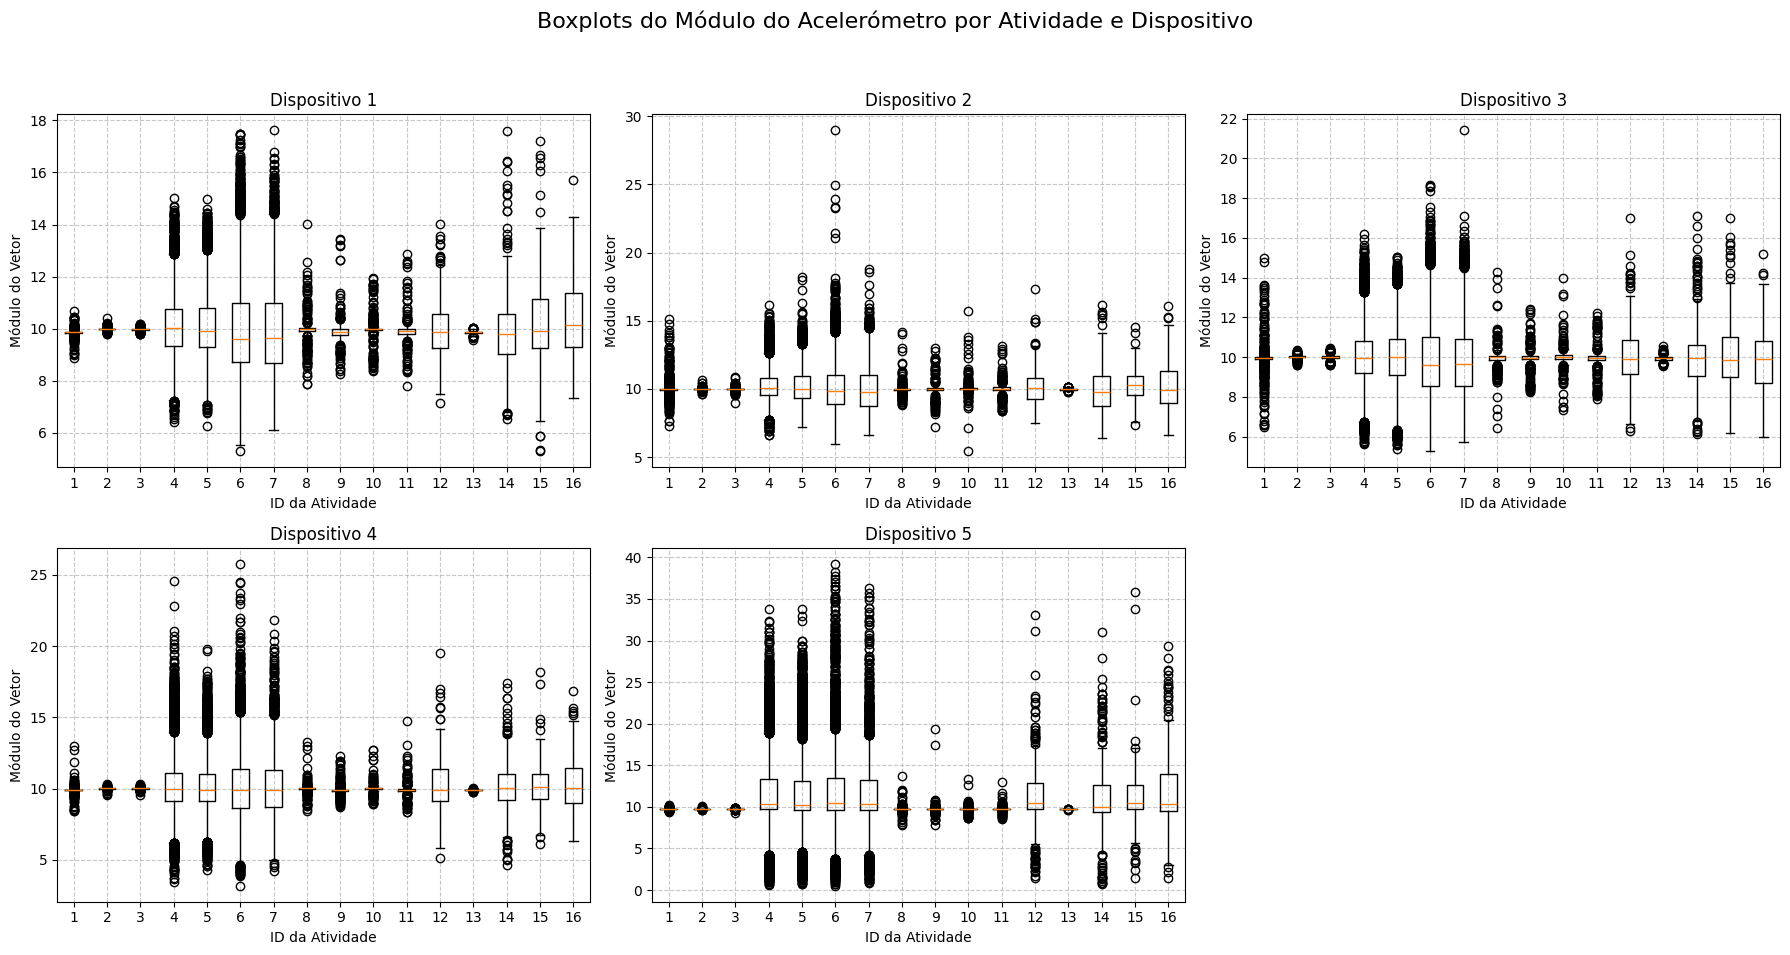

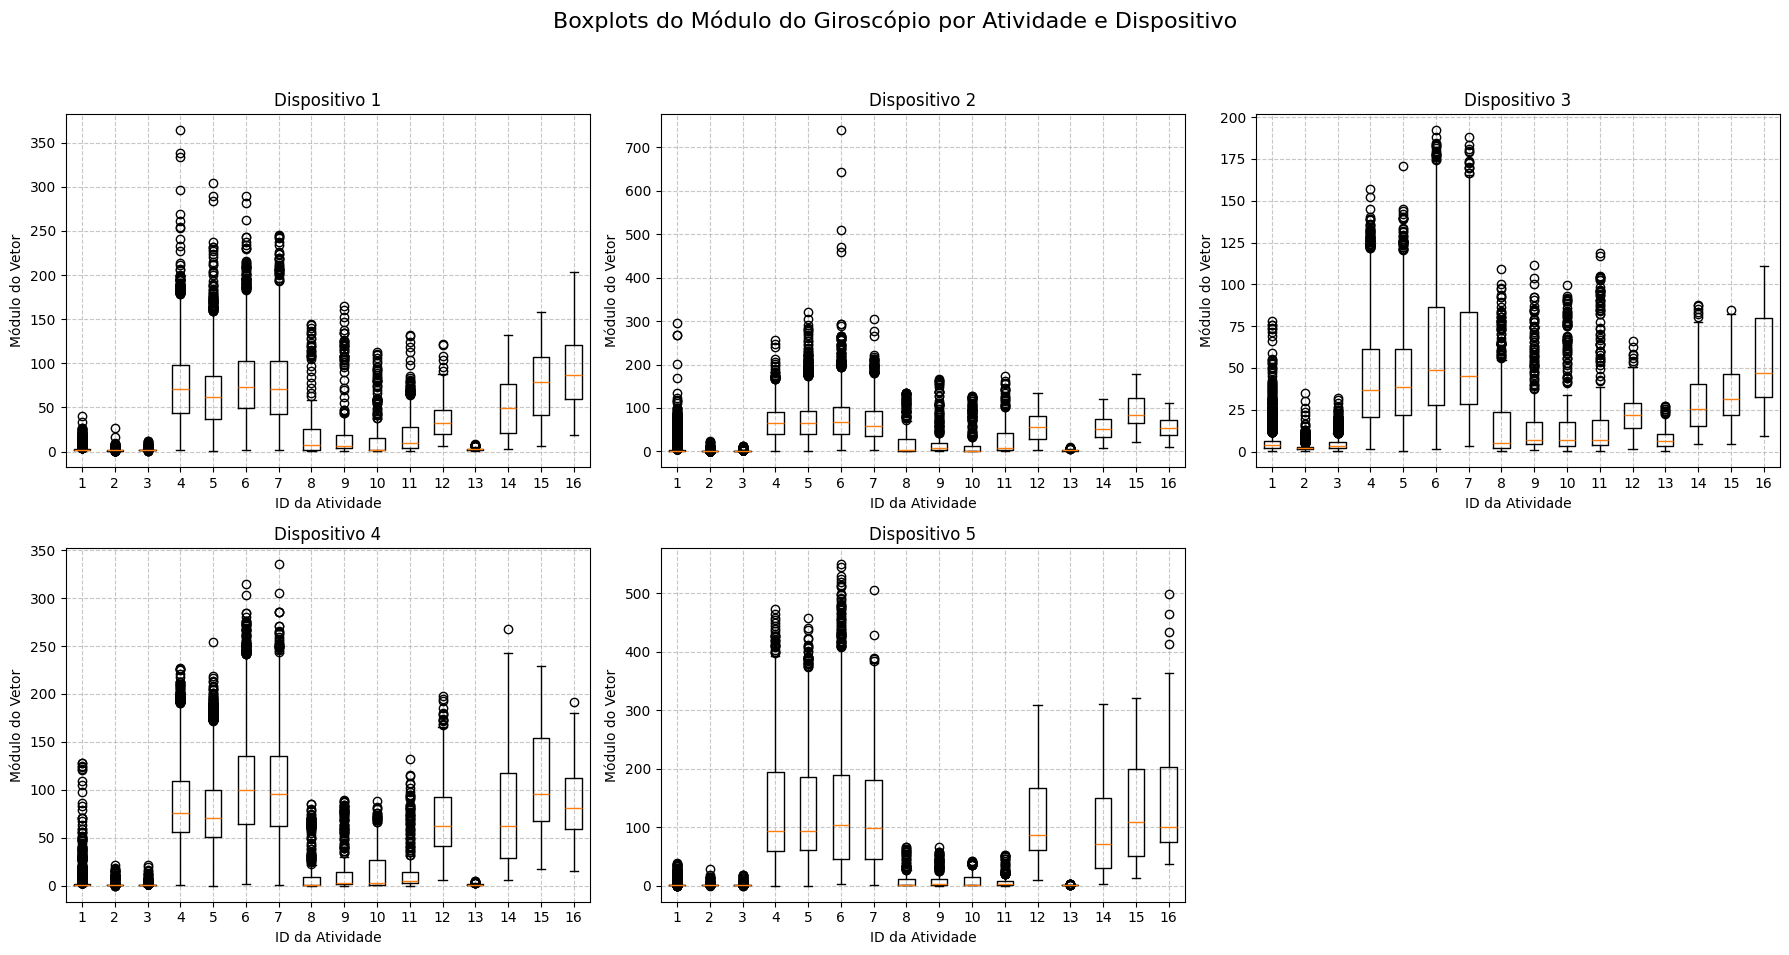

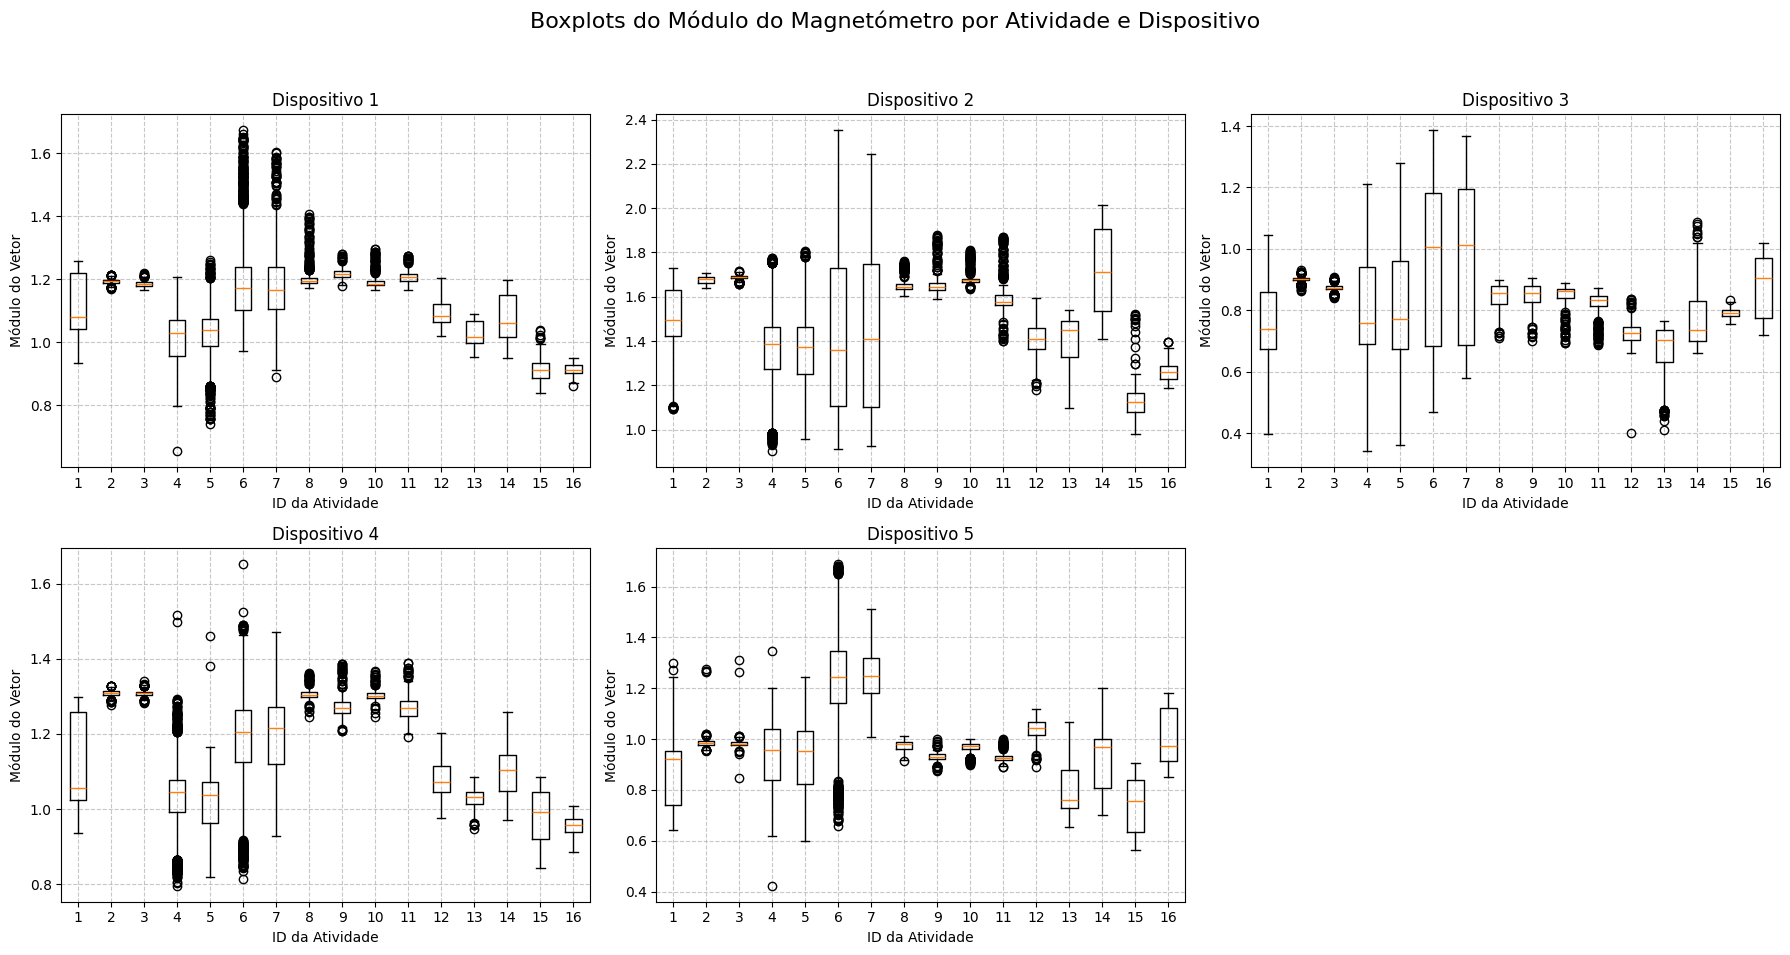

In [16]:
print("A gerar Boxplots (Ponto 3.1)...")
create_boxplot_by_activity_and_device(data, acc_module, "Acelerómetro")
create_boxplot_by_activity_and_device(data, gyro_module, "Giroscópio")
create_boxplot_by_activity_and_device(data, mag_module, "Magnetómetro")

### Ponto 3.2: Densidade de Outliers (IQR)

A análise mostra que as atividades estáveis (1 a 7) apresentam baixas taxas de outliers, geralmente abaixo de 5%, como “Sit” com 0.22% e “Walk” com 3.53%. Já as atividades de transição (8 a 16) revelam um aumento significativo, com valores entre 15% e 20%, como “Stand → Sit” (15.44%) e “Sit → Stand” (19.80%).

Este aumento deve-se ao próprio movimento de transição, que gera picos bruscos de aceleração e alteração de postura. Ao aplicar o método IQR, estes picos destacam-se face aos momentos de pausa, sendo classificados como outliers — ou seja, aqui os outliers correspondem de facto à característica definidora da atividade e não a erro ou ruído.

Ao aprofundar esta interpretação com base nos sensores do pulso direito (Dispositivo 2), conclui-se que:

Acelerómetro (Acc): Apresenta maior densidade de outliers nas transições posturais dinâmicas, como em “Sit → Stand” (19.80%) ou “Stand → Sit” (15.44%). Isto ocorre devido aos picos de aceleração e desaceleração associados ao impulso do braço durante movimentos rápidos do corpo.

Giroscópio (Gyro): O número de outliers é elevado não só nas transições, devido à velocidade angular mais intensa do pulso, mas também em posturas estáticas como “Stand” (9.48%) e “Sit and Talk” (9.12%). Isto justifica-se pela deteção de micro-movimentos, gestos e ajustes posturais, sobretudo durante a fala.

Magnetómetro (Magn): Os outliers surgem sobretudo em transições — como “Sit → Stand” (7.35%) — e em locomoção vertical, por exemplo “Stand → climb stairs…” (6.67%). Estes valores refletem alterações na orientação espacial do pulso e possíveis interferências magnéticas provenientes do ambiente, como corrimões ou paredes metálicas em escadas.

Em síntese, os sensores comportam-se de modo complementar: o acelerómetro e o giroscópio captam a componente biomecânica do movimento, enquanto o magnetómetro deteta variações de orientação e perturbações externas. Por isso, a elevada densidade de outliers observada nas atividades de transição não constitui um problema analítico, mas sim um indicador direto da complexidade dinâmica do movimento humano.

In [17]:
analyze_outlier_density_iqr(data, acc_module, "Acelerómetro", device_id=2)
analyze_outlier_density_iqr(data, gyro_module, "Giroscópio", device_id=2)
analyze_outlier_density_iqr(data, mag_module, "Magnetómetro", device_id=2)


--- 3.2. Densidade de Outliers (Método IQR) para Acelerómetro (Dispositivo 2) ---
Atividade  | Densidade (%)   | Nº Outliers  | Nº Pontos 
------------------------------------------------------------
1          | 6.92            | 762          | 11012     
2          | 3.49            | 201          | 5760      
3          | 6.20            | 357          | 5760      
4          | 4.17            | 363          | 8706      
5          | 2.03            | 192          | 9474      
6          | 3.20            | 209          | 6529      
7          | 1.77            | 50           | 2817      
8          | 30.21           | 116          | 384       
9          | 16.41           | 63           | 384       
10         | 25.78           | 99           | 384       
11         | 22.92           | 88           | 384       
12         | 3.15            | 8            | 254       
13         | 4.13            | 21           | 508       
14         | 2.36            | 6            | 254       
1

({np.float64(1.0): {'density': np.float64(0.10897203051216856),
   'n_o': np.int64(12),
   'n_r': 11012},
  np.float64(2.0): {'density': np.float64(0.0),
   'n_o': np.int64(0),
   'n_r': 5760},
  np.float64(3.0): {'density': np.float64(0.78125),
   'n_o': np.int64(45),
   'n_r': 5760},
  np.float64(4.0): {'density': np.float64(1.2175511141741326),
   'n_o': np.int64(106),
   'n_r': 8706},
  np.float64(5.0): {'density': np.float64(0.1266624445851805),
   'n_o': np.int64(12),
   'n_r': 9474},
  np.float64(6.0): {'density': np.float64(0.0),
   'n_o': np.int64(0),
   'n_r': 6529},
  np.float64(7.0): {'density': np.float64(0.0),
   'n_o': np.int64(0),
   'n_r': 2817},
  np.float64(8.0): {'density': np.float64(14.322916666666666),
   'n_o': np.int64(55),
   'n_r': 384},
  np.float64(9.0): {'density': np.float64(11.197916666666668),
   'n_o': np.int64(43),
   'n_r': 384},
  np.float64(10.0): {'density': np.float64(17.96875),
   'n_o': np.int64(69),
   'n_r': 384},
  np.float64(11.0): {'densit

### Ponto 3.3 & 3.4: Outliers Z-Score
Gera os gráficos de dispersão Z-Score para diferentes valores de K.

A gerar gráficos Z-Score (Ponto 3.3/3.4)...


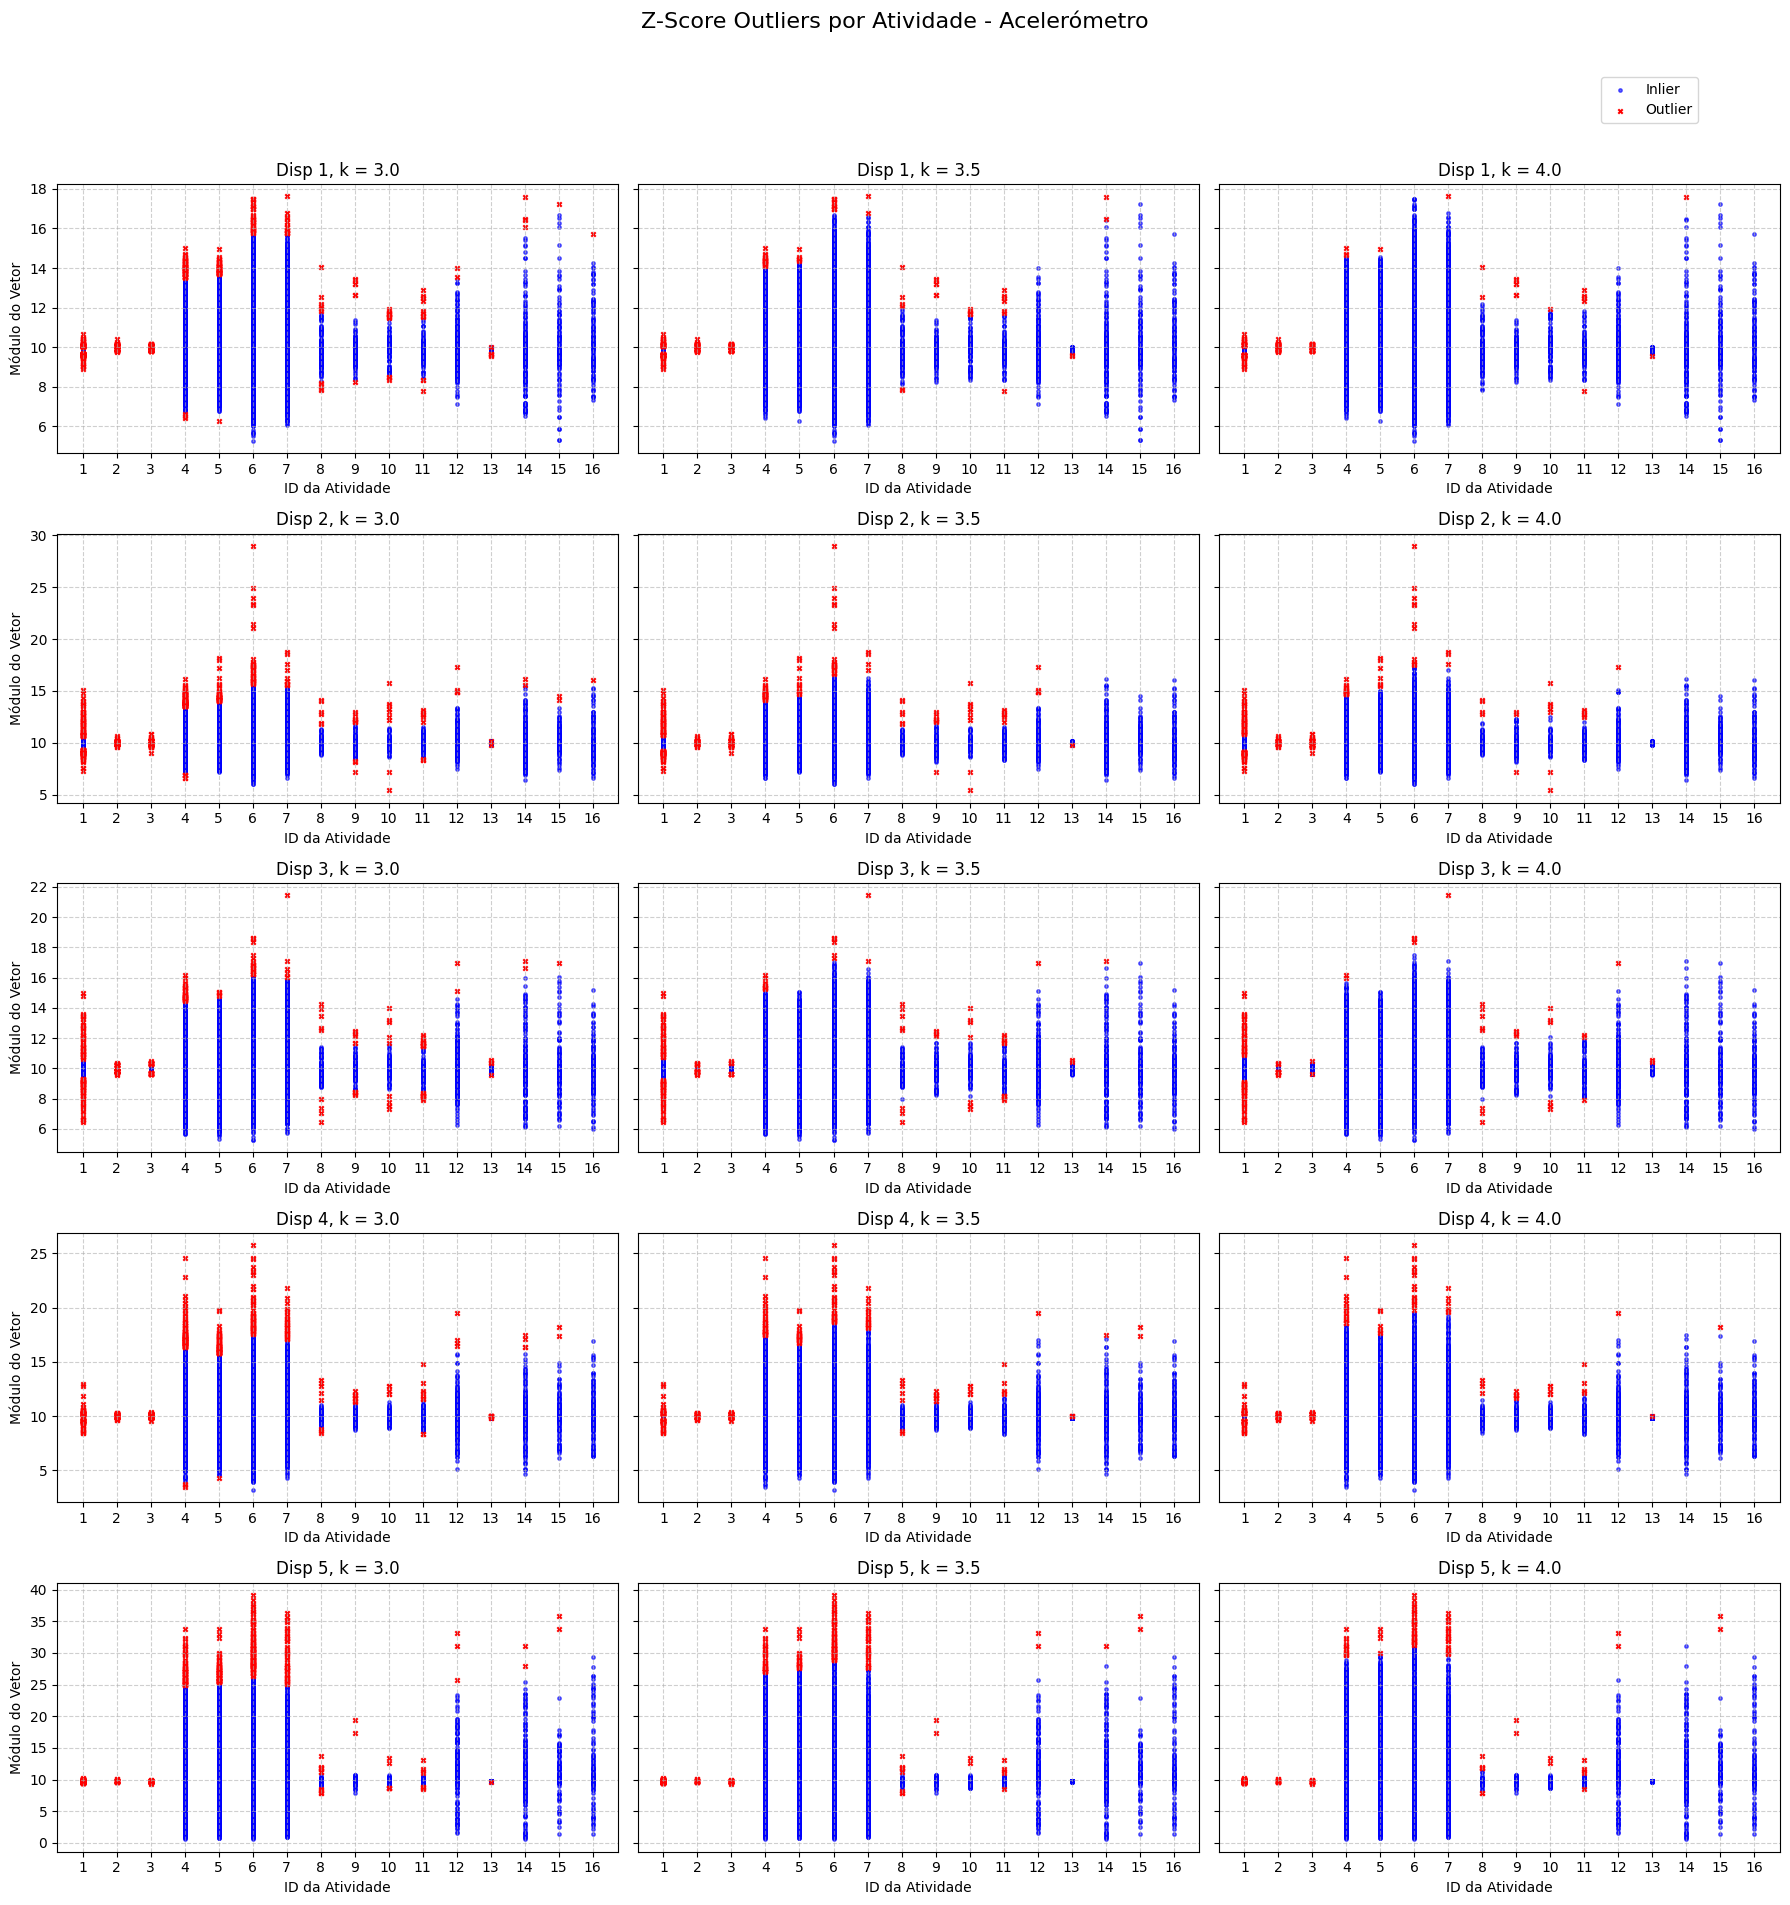


Resumo da Contagem de Outliers Z-Score: Acelerómetro
----------------------------------------
Dispositivo | k=3.0  | k=3.5  | k=4.0  |
----------------------------------------
 1           | 545   | 280   | 177   |
 2           | 527   | 335   | 249   |
 3           | 345   | 185   | 131   |
 4           | 540   | 319   | 206   |
 5           | 554   | 339   | 215   |
----------------------------------------


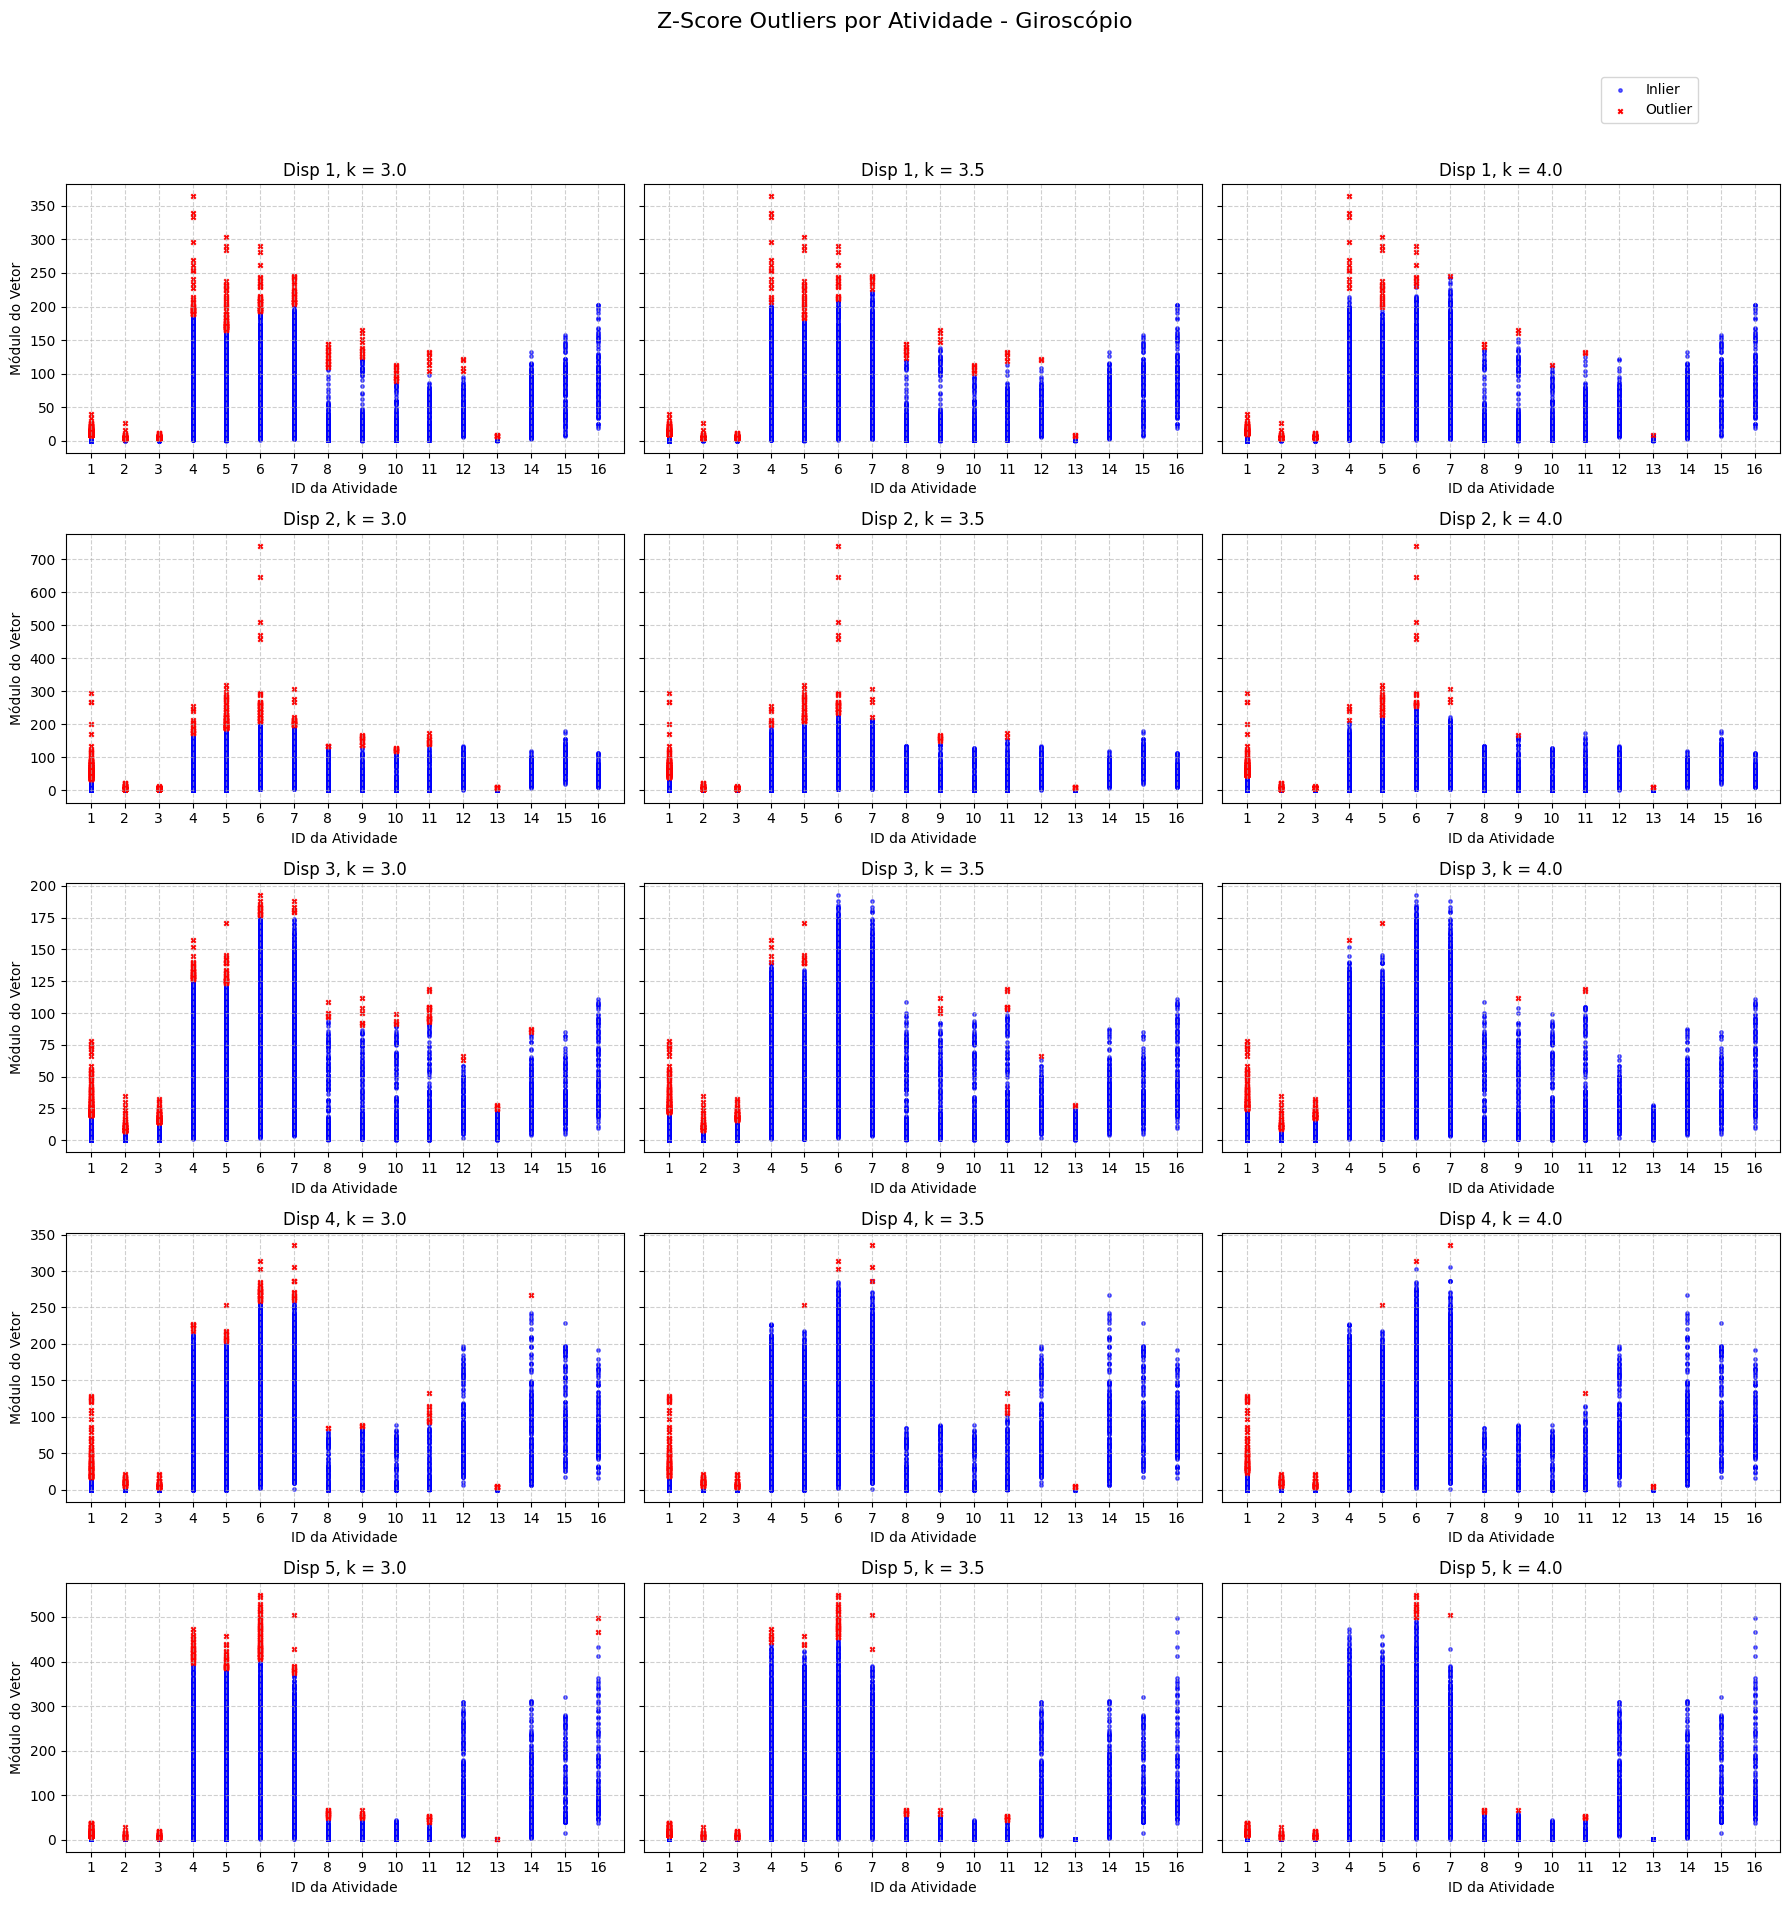


Resumo da Contagem de Outliers Z-Score: Giroscópio
----------------------------------------
Dispositivo | k=3.0  | k=3.5  | k=4.0  |
----------------------------------------
 1           | 584   | 377   | 273   |
 2           | 592   | 420   | 321   |
 3           | 484   | 264   | 178   |
 4           | 277   | 189   | 164   |
 5           | 404   | 265   | 203   |
----------------------------------------


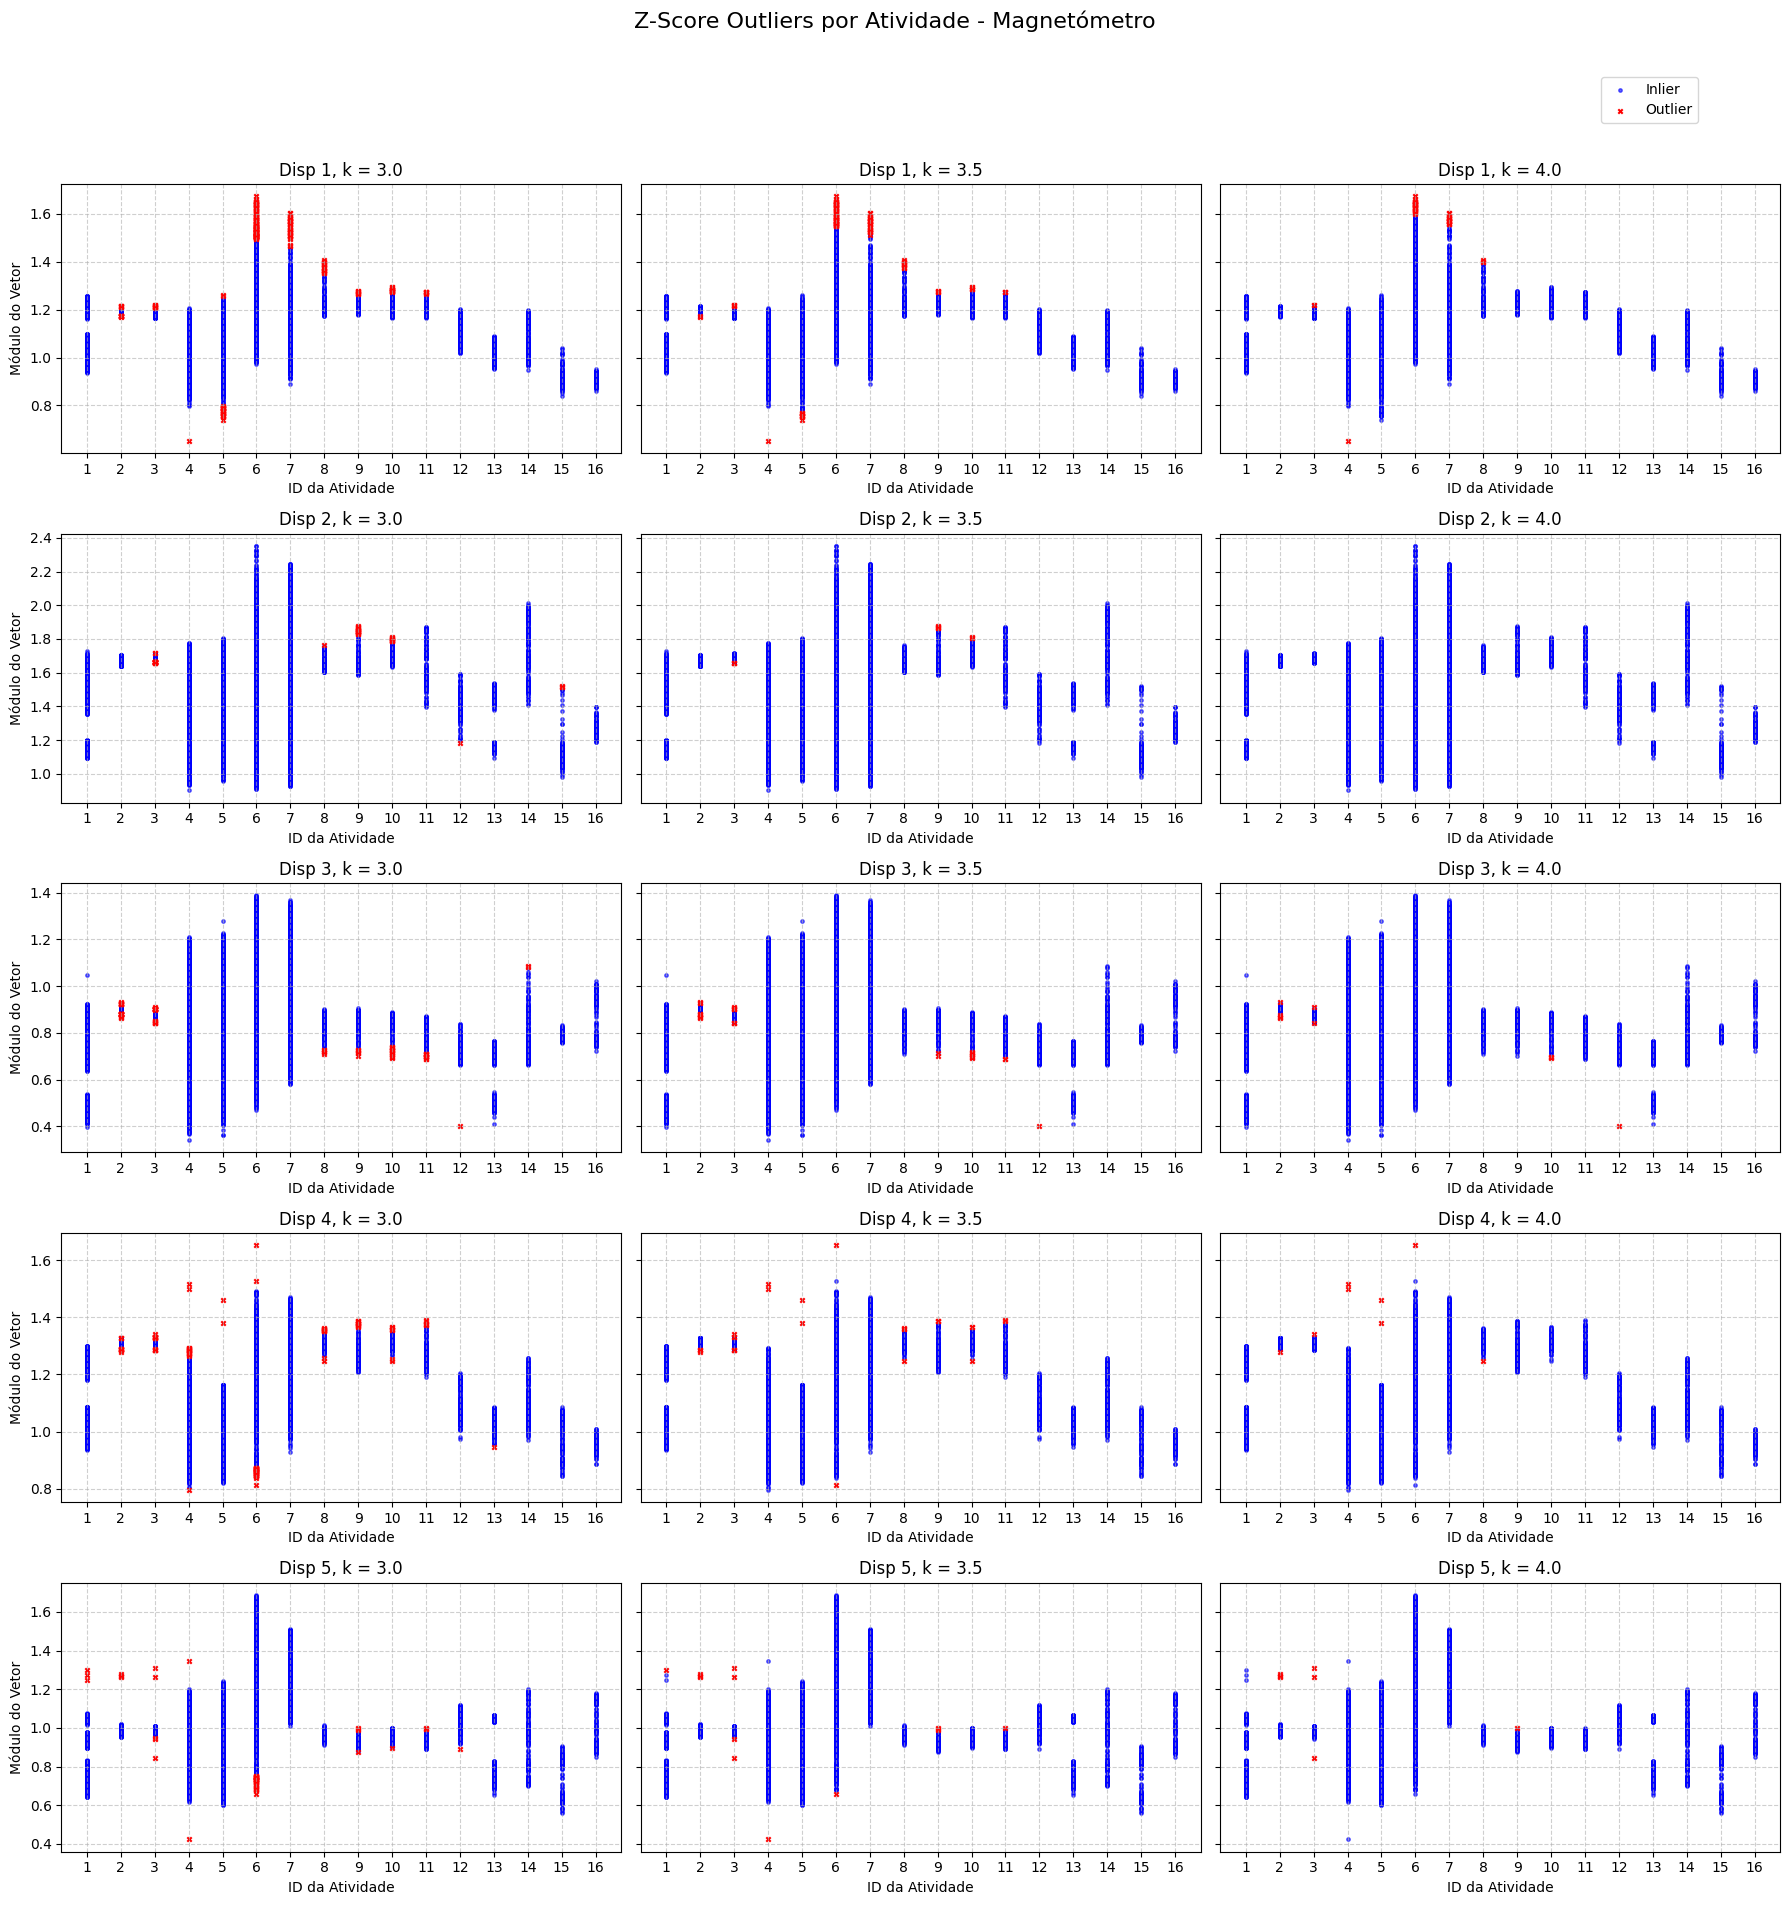


Resumo da Contagem de Outliers Z-Score: Magnetómetro
----------------------------------------
Dispositivo | k=3.0  | k=3.5  | k=4.0  |
----------------------------------------
 1           | 237   | 118   | 47    |
 2           | 53    | 11    | 0     |
 3           | 87    | 30    | 11    |
 4           | 123   | 28    | 8     |
 5           | 57    | 15    | 8     |
----------------------------------------


In [18]:
print("A gerar gráficos Z-Score (Ponto 3.3/3.4)...")
plot_zscore_comparison_by_device(data, acc_module, "Acelerómetro", ks=[3.0, 3.5, 4.0])
plot_zscore_comparison_by_device(data, gyro_module, "Giroscópio", ks=[3.0, 3.5, 4.0])
plot_zscore_comparison_by_device(data, mag_module, "Magnetómetro", ks=[3.0, 3.5, 4.0])

### Ponto 3.5 Comparação dos resultados obtidos nos pontos 3.1 e 3.4

A análise dos métodos demonstra que o IQR é mais adequado para este conjunto de dados, pois trata-se de uma abordagem robusta baseada em percentis, não assumindo normalidade na distribuição. Já o método Z-Score depende da média e do desvio-padrão, pressupondo que os dados seguem uma distribuição normal.

Os boxplots apresentados evidenciam distribuições assimétricas, com caudas longas e valores extremos característicos de dados de sensores. Nestas condições, a média e o desvio-padrão tornam-se métricas enviesadas, o que compromete a fiabilidade do Z-Score. Como consequência, este método tende a subestimar ou classificar incorretamente outliers, uma vez que os valores extremos influenciam o cálculo e alargam artificialmente os limites de deteção.

Por sua vez, o IQR (Interquartile Range) utiliza mediana e quartis, estatísticas insensíveis a valores extremos. Isso permite que detete com precisão variações reais nos dados, mesmo quando a distribuição não é normal. Esta característica é essencial em sistemas de reconhecimento de atividades humanas, nos quais os outliers podem representar eventos relevantes, como transições posturais rápidas ou mudanças súbitas de movimento — e não apenas ruído.

Além disso, as tabelas de densidade de outliers obtidas com o IQR mostram diferenças marcantes entre atividades estáveis e atividades de transição, informação que o Z-Score não fornece quando observado de forma agregada.

Em síntese, enquanto o Z-Score tende a suavizar o comportamento dos dados, o IQR preserva a estrutura e a variabilidade do movimento captada pelos sensores, destacando-se como o método mais fiável e informativo para este dataset.

### Ponto 3.6 & 3.7: K-Means
Executa a análise K-Means 3D em todos os dispositivos.

A executar K-Means 3D (Ponto 3.6/3.7)...

--- 3.6/3.7. Análise de Outliers K-Means 3D (Módulos Combinados) - DISPOSITIVO 2 ---
A analisar 52864 amostras do dispositivo 2.


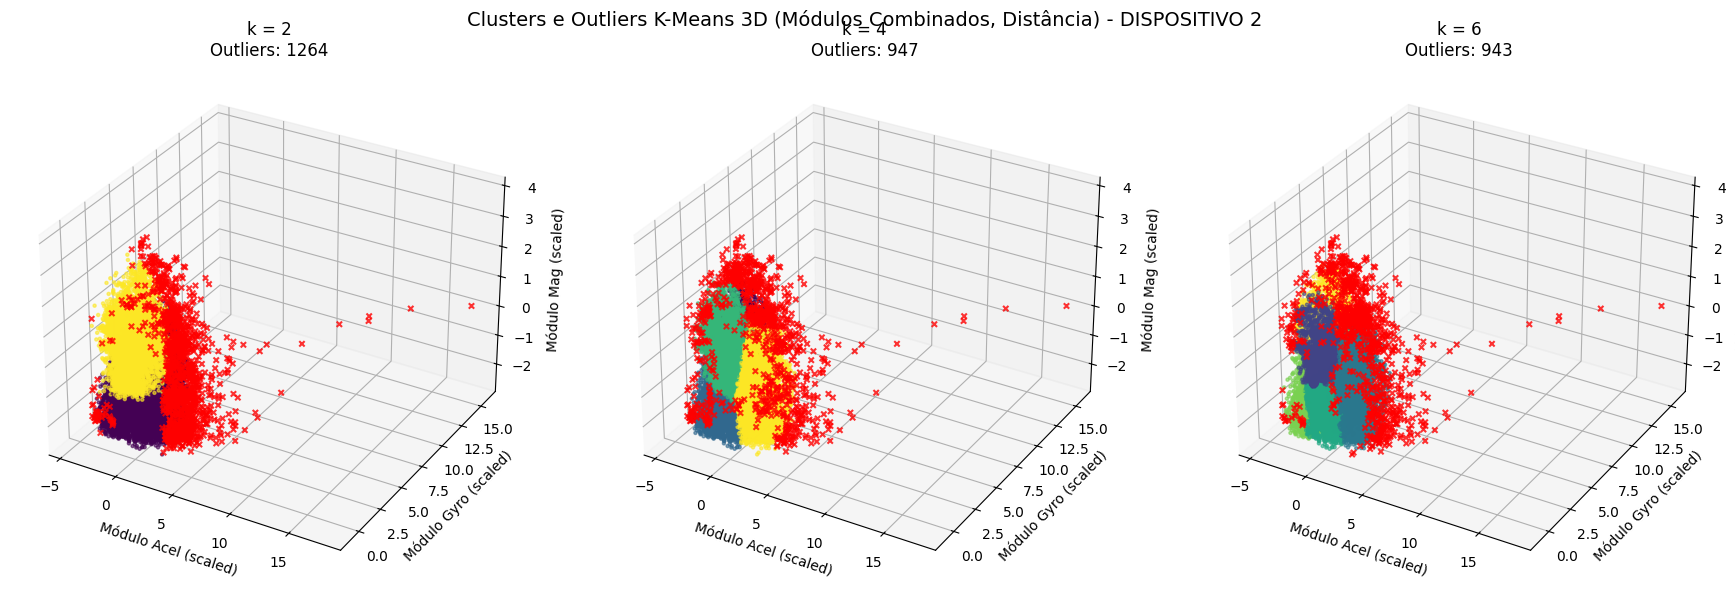

In [19]:
print("A executar K-Means 3D (Ponto 3.6/3.7)...")
kmeans_outlier_combined_3d(data, acc_module, gyro_module, mag_module, 
                        device_id_to_filter=2, 
                        n_clusters_list=[2, 4, 6])

### 3.F. Ponto 3.7.1 (Bónus): DBSCAN (Combinado)
Executa a análise DBSCAN 3D (apenas no dispositivo 2).


--- 3.7.1. Análise de Outliers DBSCAN 3D (Módulos Combinados) - DISPOSITIVO 2 ---
A analisar 52864 amostras do dispositivo 2.
Params (eps=0.5, min_s=10): Encontrados 1 clusters e 256 outliers.
Params (eps=0.5, min_s=10): Encontrados 1 clusters e 256 outliers.
Params (eps=0.3, min_s=15): Encontrados 11 clusters e 2004 outliers.
Params (eps=0.3, min_s=15): Encontrados 11 clusters e 2004 outliers.
Params (eps=0.7, min_s=10): Encontrados 1 clusters e 122 outliers.
Params (eps=0.7, min_s=10): Encontrados 1 clusters e 122 outliers.


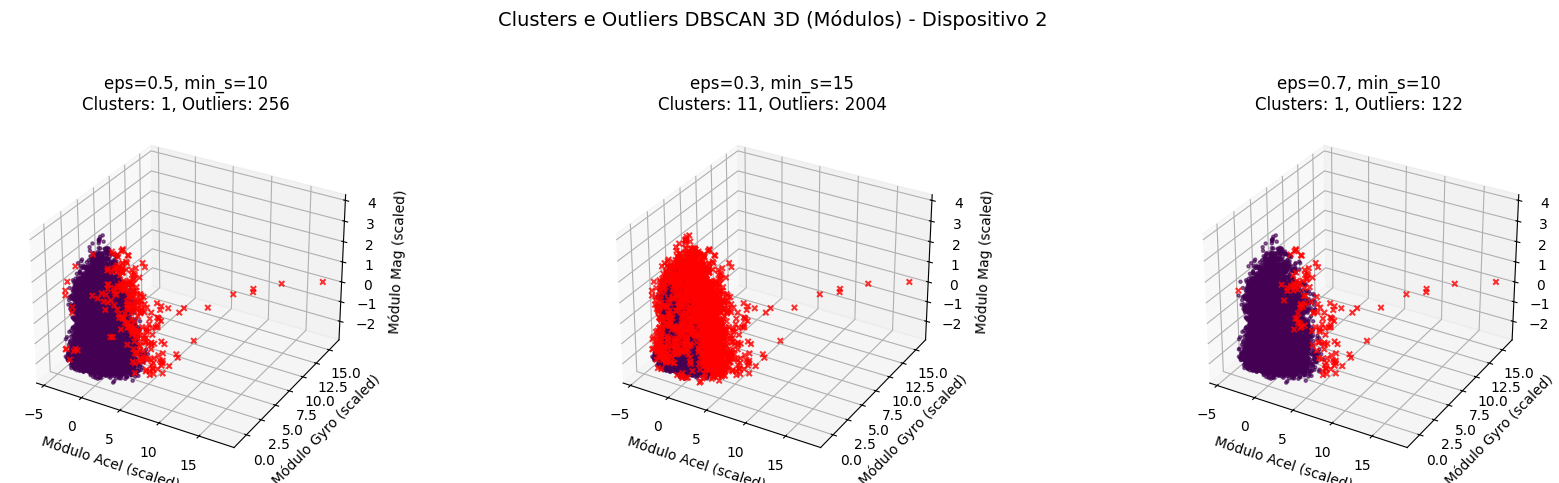

In [20]:
dbscan_params_to_test = [
    (0.5, 10),  # eps=0.5, min_samples=10
    (0.3, 15),  # eps=0.3, min_samples=15
    (0.7, 10)   # eps=0.7, min_samples=10
]
dbscan_outlier_combined_3d(data, acc_module, gyro_module, mag_module, 
                           device_id_to_filter=2, 
                           params_list=dbscan_params_to_test)

### Comparação dos gráficos 3D

##### Ponto 3.7 — K-Means
Os resultados do algoritmo K-Means para diferentes valores de clusters: k = 2, 4 e 6. Os eixos representam os módulos dos sensores (Acc, Gyro, Mag) e os pontos vermelhos (‘x’) indicam os outliers identificados.

#### Método:
O K-Means é um algoritmo de particionamento que obriga todos os pontos a pertencerem a um cluster. Após os clusters serem formados, os pontos que ficam demasiado distantes do centróide do seu cluster são rotulados como outliers.

#### Observações:
O algoritmo divide a grande nuvem de pontos em agrupamentos globulares.
Os outliers surgem como pontos periféricos, afastados do seu centróide.

#### Limitação importante:
Ao ser forçado a integrar todos os pontos, o K-Means deixa de ser um método adequado para deteção de outliers:
Um verdadeiro outlier pode deslocar o centróide do cluster na sua direção → distorção do cluster
A distância ao centróide deixa de ser um critério fiável para identificação de anomalias

#### Ponto 3.7.1 (Bónus) — DBSCAN
DBSCAN varia o parâmetro eps (raio de vizinhança) entre 0.5, 1.0 e 2.0. Os pontos marcados a vermelho ('x') são classificados diretamente como Noise (outliers).

#### Método:
O DBSCAN identifica clusters com base em densidade, classificando como ruído os pontos que não pertencem a nenhuma região densa. Assim, a deteção de outliers é natural e intrínseca ao algoritmo.

Resultados conforme o valor de eps:

eps = 0.5 → raio demasiado pequeno → quase tudo é ruído → resultado incorreto

eps = 2.0 → raio demasiado grande → quase todos os pontos formam um cluster único → sem separação de outliers

eps = 1.0 → valor equilibrado → clusters distintos com outliers corretamente isolados → melhor resultado

#### Conclusão:
O DBSCAN revela-se claramente superior para esse contexto, pois:

Respeita a forma real dos dados no espaço 3D
Identifica outliers como pontos isolados em regiões de baixa densidade

Não sofre deslocamento de centróides provocado por outliers

O resultado com eps = 1.0 (gráfico central de 10.png) é o mais fiável: os outliers marcados são verdadeiramente pontos afastados dos padrões da amostra, refletindo comportamentos anómalos no movimento captado pelos sensores.

### Ponto 4.1: Testes de Significância

#### Análise com Apenas um Participante

Quando avaliamos os dados de um único indivíduo, estamos a considerar apenas a variabilidade intra-participante.
Nestes casos, o Teste de Kolmogorov-Smirnov (K-S) indicou que, em algumas atividades — sobretudo curtas ou de transição — a distribuição dos dados não se afasta significativamente da normalidade (ex.: p > 0.05).

Exemplo:

Acelerómetro, Disp. 1 — Atividade 12: p = 0.0765 → Normal

Giroscópio, Disp. 2 — Atividade 16: p = 0.9639 → Normal

Isto acontece porque o movimento de um único indivíduo tende a ser mais consistente e com menor diversidade de padrões.

#### Análise com Todos os Participantes

Quando agregamos dados de todos os 15 participantes, o cenário altera-se completamente:
todos os p-valores são 0.0000 → todas as atividades são não-normais.

Este resultado é explicado por dois fatores:

  Variabilidade inter-participante
Cada pessoa realiza os movimentos com ritmos, amplitudes e posturas ligeiramente diferentes.
A mistura destas distribuições individuais cria uma distribuição global irregular e assimétrica, impossibilitando a normalidade.

  Grande dimensão da amostra
Com centenas de milhares de amostras (ex.: 157 882 pontos só na atividade “Stand”), o teste K-S torna-se muito sensível:
pequenas divergências da normalidade resultam automaticamente na rejeição da hipótese nula.

In [21]:
test_significance_by_activity_all_devices(data, acc_module, "Acelerómetro")
test_significance_by_activity_all_devices(data, gyro_module, "Giroscópio")
test_significance_by_activity_all_devices(data, mag_module, "Magnetómetro")


4.1 Teste de significância das médias — Acelerómetro

------------------------------------------------------------
Dispositivo 1
------------------------------------------------------------
Teste de normalidade (Kolmogorov-Smirnov):
Atividade 1 : Stat=0.0734, p=0.0000 → Não normal
Atividade 2 : Stat=0.1047, p=0.0000 → Não normal
Atividade 3 : Stat=0.0746, p=0.0000 → Não normal
Atividade 4 : Stat=0.0345, p=0.0000 → Não normal
Atividade 5 : Stat=0.0765, p=0.0000 → Não normal
Atividade 6 : Stat=0.1063, p=0.0000 → Não normal
Atividade 7 : Stat=0.1077, p=0.0000 → Não normal
Atividade 8 : Stat=0.2669, p=0.0000 → Não normal
Atividade 9 : Stat=0.2122, p=0.0000 → Não normal
Atividade 10: Stat=0.2891, p=0.0000 → Não normal
Atividade 11: Stat=0.2528, p=0.0000 → Não normal
Atividade 12: Stat=0.0795, p=0.0765 → Normal
Atividade 13: Stat=0.0564, p=0.0762 → Normal
Atividade 14: Stat=0.1550, p=0.0000 → Não normal
Atividade 15: Stat=0.1136, p=0.0696 → Normal
Atividade 16: Stat=0.1042, p=0.1178 → Norma

### Ponto 4.2: Extração de Features

  Features Estatísticas (Domínio do Tempo)
Estas features descrevem a distribuição estatística e a forma do sinal dentro da janela de 5 segundos. Foram calculadas para cada eixo (x, y, z) de cada sensor (Acc, Gyro).

_mean (Média): O valor médio do sinal. Indica a componente estática do movimento (ex: a força da gravidade no acelerómetro).

_median (Mediana): O valor central (percentil 50). Semelhante à média, mas mais robusto a picos súbitos (outliers).

_std (Desvio Padrão): Mede a dispersão ou variabilidade do sinal. Um valor alto significa que o sinal variou muito (ex: ao andar vs. estar parado).

_iqr (Intervalo Interquartil): A diferença entre o percentil 75 e o percentil 25. É também uma medida de dispersão, mas muito robusta a outliers. (Nota: gy_iqr foi considerada a feature mais importante de todas ).

_rms (Root Mean Square): Mede a magnitude ou "potência" média do sinal. É sensível tanto a valores estáticos como dinâmicos.

_skew (Assimetria): Mede o "enviesamento" da distribuição. Um valor de 0 é perfeitamente simétrico.

_kurtosis (Curtose): Mede o quão "pontuda" é a distribuição e o peso das suas "caudas". Valores altos indicam a presença de picos extremos e infrequentes.

_mean_cross_rate / _zero_cross_rate (Taxa de Cruzamento da Média/Zero): O número de vezes que o sinal cruza a sua própria média (ou o valor zero). É uma medida simples da frequência do sinal.

#### Features Espectrais (Domínio da Frequência)

Estas features são calculadas após aplicar uma Transformada de Fourier (FFT) ao sinal, descrevendo as suas propriedades em termos de frequência.

_spec_entropy (Entropia Espectral): Mede a complexidade ou "pureza" do sinal em frequência. Um sinal muito regular (como uma onda sinusoidal) tem baixa entropia, enquanto um sinal caótico (como ruído) tem alta entropia.

_dom_freq (Frequência Dominante): A frequência com maior energia no espectro. Indica a frequência principal do movimento (ex: a cadência da caminhada).

_energy (Energia Espectral): A soma total da energia (magnitude) em todas as bandas de frequência.


#### Features Físicas e de Correlação

Estas são features compostas que combinam múltiplos eixos ou sensores para obter uma descrição física do movimento.

corr_... (Correlação): (ex: corr_gyro_xy). Mede o grau de relação linear entre dois eixos. Um valor de 1 significa que se movem em perfeita sincronia; -1 em perfeita oposição.

SMA (Signal Magnitude Area): A soma das magnitudes de todos os eixos do acelerómetro. É uma medida da "quantidade total de movimento" ou energia gasta.


ARE, AVG, ARATG, AVH, CAGH: Estes são acrónimos para features compostas específicas (provavelmente do artigo científico referenciado ), que combinam diferentes eixos e sensores para criar descritores de movimento mais complexos (ex: média da magnitude do vetor, energia rotacional, etc.).

In [22]:
print(f"\n{'='*60}\n4.2 - Extração de Features\n{'='*60}")
all_features = []
all_labels = []
sensor_data = data[:, 1:10]   # ax..mz
activity_labels = data[:, 11] # última coluna

print("A criar janelas e extrair features...")
feat_dict = {} # Inicializar para o caso de não haver janelas
for start, win_data, win_label in sliding_windows(sensor_data, activity_labels):
    feat_dict = extract_features_window(win_data)
    all_features.append(list(feat_dict.values()))
    all_labels.append(win_label)

feature_matrix = np.array(all_features)

if not all_features:
    print("Não foram geradas janelas de features. A análise PCA e Feature Selection será ignorada.")
    feature_names = []
    labels_vector = np.array([])
else:
    feature_names = list(feat_dict.keys())
    labels_vector = np.array(all_labels)
    print(f"Features extraídas: {feature_matrix.shape[1]} por janela.")
    print(f"Número de janelas válidas: {feature_matrix.shape[0]}")


4.2 - Extração de Features
A criar janelas e extrair features...
Features extraídas: 101 por janela.
Número de janelas válidas: 864
Features extraídas: 101 por janela.
Número de janelas válidas: 864


### Ponto 4.3 & 4.4: Análise PCA
Executa a análise de componentes principais sobre a matriz de features.


4.3 & 4.4 - Análise de Componentes Principais (PCA)
PCA aplicado. Número total de componentes calculadas: 101

São necessárias 11 componentes principais para explicar pelo menos 75% da variância.

--- Contribuição das Features para as Componentes Principais (Top 5) ---

PC1 (Explica 35.96% da variância):
  ay_std                    (Peso: 0.1618)
  ARE                       (Peso: 0.1594)
  ax_std                    (Peso: 0.1568)
  gy_std                    (Peso: 0.1561)
  az_std                    (Peso: 0.1548)

PC2 (Explica 11.61% da variância):
  az_spec_entropy           (Peso: 0.2354)
  az_mean_cross_rate        (Peso: 0.2309)
  ax_mean_cross_rate        (Peso: 0.1948)
  az_rms                    (Peso: 0.1942)
  gy_spec_entropy           (Peso: 0.1934)

PC3 (Explica 5.28% da variância):
  gx_median                 (Peso: 0.3073)
  SMA                       (Peso: -0.2220)
  gz_spec_entropy           (Peso: 0.2057)
  corr_gyro_yz              (Peso: -0.1897)
  gz_iqr          

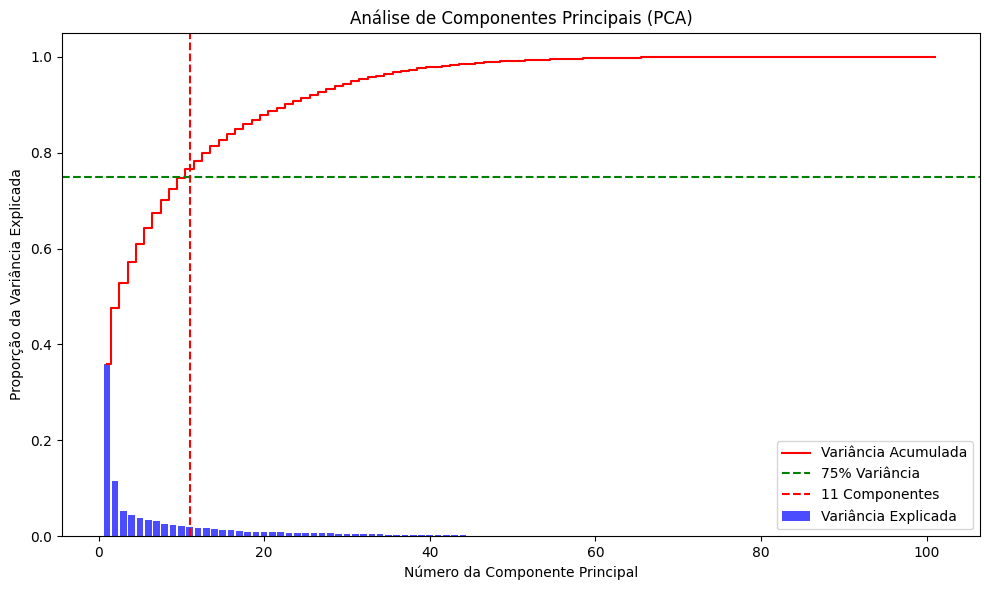


4.4.1 — Exemplo de compressão do vetor de features:
→ Janela #0: 11 componentes principais =
[-4.11007561 -1.3883517  -0.52455003 -1.58633175  2.39176389  0.55924664
 -1.67846206  0.13180247  2.3948535   2.23233214 -2.93263975]



In [23]:
if feature_matrix.size > 0:
    pca, scaler, features_pca, n_components_75 = analyze_pca(feature_matrix, feature_names)
else:
    print("\nMatriz de features vazia. A saltar PCA.")

Apenas Um Participante: São necessárias 11 componentes para explicar 75% da variância.

Todos os Participantes: São necessárias 16 componentes para explicar 75% da variância.

Porquê 11 para o Individual? Os dados de um único participante são muito auto-consistentes. A forma como essa pessoa "anda" ou "senta-se" segue um padrão muito repetitivo e pessoal. Como os padrões são tão consistentes, o PCA consegue "comprimir" a essência desses movimentos de forma muito eficiente, capturando 75% de toda a sua variabilidade (variabilidade intra-participante) com apenas 11 componentes.

Porquê 16 para Todos os Participantes? Ao agregar os dados de 15 pessoas diferentes, introduzimos uma enorme fonte de nova variabilidade: a variabilidade inter-participante.

Cada pessoa "anda" de forma ligeiramente diferente (cadência, altura, peso, etc.).

O PCA agora não tem apenas que capturar a "essência do andar", mas também a "essência" das 14 outras formas de andar.

Como resultado, o dataset agregado é mais complexo e menos compressível. A variância está mais "espalhada" por mais padrões. Por isso, o modelo de PCA precisa de mais componentes (16 em vez de 11) para conseguir capturar os mesmos 75% da variabilidade total.

#### Ponto 4.4.1: Indique como poderia obter as features e exemplifique

Como Obter: O processo é o mesmo. Primeiro, treina-se o modelo PCA nos dados (ex: nos dados de "Todos os Participantes"). O modelo fit aprende as 16 "receitas" (componentes). Depois, para qualquer janela (um vetor de 101 features), usa-se a função transform para a converter no novo vetor de 16 features.

Exemplo (Todos os Participantes):

Vetor Original: Um vetor com 101 features.

Vetor Comprimido: [-4.10020248 -1.46628634 ... 1.26140681] (um novo vetor de 16 números).

Onde -4.100 é o score da Janela #0 para a PC1, -1.466 o score para a PC2, e assim sucessivamente.

#### Ponto 4.4.2: Vantagens e Limitações desta Abordagem

Esta parte da análise é conceptual e mantém-se, mas agora é reforçada pela nossa descoberta:

Vantagens:

Redução de Dimensionalidade: No caso geral ("Todos os Participantes"), passamos de 101 para 16 features. É uma redução de 84% na complexidade, o que acelera muito a classificação.

Combate ao Overfitting: Ao focarmo-nos nos 16 padrões de maior variância, evitamos que o modelo de classificação aprenda "ruído" ou padrões que só se aplicam a um indivíduo.

Remoção de Multicolinearidade: As 16 componentes são ortogonais (não-correlacionadas), o que melhora a estabilidade de muitos algoritmos.

Limitações:

Perda de Interpretabilidade: É a desvantagem principal. Sabemos do Ponto 4.6 que gy_iqr é a melhor feature . Isso é interpretável. No entanto, a "PC1" do modelo de 16 componentes (que é uma mistura de ay_std, ARE, az_std, ax_iqr, ax_std, etc. ) não tem um significado físico claro.


Perda de Informação: Estamos a descartar 25% da variância (100% - 75%). É possível que a informação que distingue duas atividades muito semelhantes (ex: "Climb Stair" vs "Climb Stair and talk") estivesse nesses 25% descartados, prejudicando a precisão.

### Ponto 4.5 & 4.6: Fisher Score e ReliefF
Executa os algoritmos de seleção de features.

In [24]:
if feature_matrix.size > 0:
    top10_fisher, top10_relief, fisher_scores, relief_scores = feature_selection_analysis(
        feature_matrix, feature_names, labels_vector
    )
else:
    print("\nMatriz de features vazia. A saltar Feature Selection.")

print("\n\n--- Análise Interativa Concluída ---")


4.5 & 4.6 - Feature Selection: Fisher Score e ReliefF

Top 10 Features — Fisher Score:
 1. gy_iqr  (score=10.7630)
 2. gy_rms  (score=5.9470)
 3. gz_mean_cross_rate  (score=5.7047)
 4. ay_iqr  (score=5.3538)
 5. gy_std  (score=3.4582)
 6. gx_mean_cross_rate  (score=2.3842)
 7. gy_mean_cross_rate  (score=2.0672)
 8. ay_std  (score=1.8382)
 9. ay_mean_cross_rate  (score=1.7617)
10. gz_spec_entropy  (score=1.7331)

A aplicar ReliefF

Top 10 Features — ReliefF:
 1. gy_iqr  (score=0.2731)
 2. ay_iqr  (score=0.2646)
 3. gy_rms  (score=0.2634)
 4. gz_mean_cross_rate  (score=0.2287)
 5. gy_spec_entropy  (score=0.2231)
 6. gy_std  (score=0.2086)
 7. gx_std  (score=0.2060)
 8. gx_rms  (score=0.2054)
 9. gy_mean  (score=0.2005)
10. gy_mean_cross_rate  (score=0.1948)


--- Análise Interativa Concluída ---

Top 10 Features — ReliefF:
 1. gy_iqr  (score=0.2731)
 2. ay_iqr  (score=0.2646)
 3. gy_rms  (score=0.2634)
 4. gz_mean_cross_rate  (score=0.2287)
 5. gy_spec_entropy  (score=0.2231)
 6. gy_std

#### Ponto 4.6 – Identificação e Comparação das Top 10 Features

Foram comparados dois métodos de seleção de features — Fisher Score e ReliefF

#### Cenário 1: Um Participante

Fisher (Top 3): gy_iqr, gy_rms, gz_mean_cross_rate

ReliefF (Top 3): gy_iqr, ay_iqr, gy_rms
→ Ambos destacam gy_iqr como a feature mais discriminativa, indicando que a variabilidade da rotação do pulso (eixo Y) é a principal assinatura individual.

#### Cenário 2: Todos os Participantes

Fisher (Top 3): gy_rms, gy_std, gy_iqr

ReliefF (Top 3): gy_rms, gy_std, gy_spec_entropy
→ Ambos concordam que gy_rms e gy_std são as features mais importantes, refletindo a relevância da variabilidade da velocidade angular no eixo Y.

#### Conclusão

Há alta consistência entre métodos e cenários: as features dominantes vêm do giroscópio (eixo Y) e medem dispersão/variabilidade (iqr, rms, std).
O consenso entre Fisher e ReliefF confirma que gy_rms e gy_std são robustas tanto isoladamente como em conjunto — tornando o modelo geral o mais fiável.

#### Ponto 4.6.1 – Obtenção e Exemplo

A seleção de features filtra dados (mantém colunas relevantes), ao contrário do PCA, que os transforma.

Processo:

Da matriz original (101 features), aplica-se Fisher ou ReliefF.

Selecionam-se as 10 melhores colunas.

Cria-se uma nova matriz apenas com essas 10 features.

Exemplo:

Vetor original: 101 valores

Após PCA: 16 componentes transformadas

Após seleção: 10 valores originais correspondentes às melhores features (ex: gy_rms, gy_std, gy_iqr...).

#### Ponto 4.6.2 – Vantagens e Limitações

Vantagens:

Interpretabilidade: sabemos exatamente quais variáveis o modelo usa (ex: gy_rms).

Redução de dimensionalidade: menos features → treino mais rápido.

Menos overfitting: elimina features irrelevantes/ruidosas.

Limitações:

Perda de informação: features descartadas podem conter combinações úteis.

Seleção subótima: métodos de filtro não consideram o tipo de modelo (uma seleção ideal pode variar entre classificadores).

## META 2

### 1. Data Augmentation

O objetivo é construir uma função capaz de gerar exemplos sintéticos para adicionar variedade ao conjunto de treino. Para este módulo, consideramos apenas as atividades 1 a 7.

**Nota:** Todas as amostras com atividades superiores a 7 serão descartadas.

#### 1.1 Análise do Balanceamento do Dataset

Analisamos a distribuição do número de exemplos (janelas de features) disponíveis para cada uma das atividades 1 a 7.

A carregar dados de todos os participantes...
A carregar dados de todos os participantes: ['part0', 'part1', 'part10', 'part11', 'part12', 'part13', 'part14', 'part2', 'part3', 'part4', 'part5', 'part6', 'part7', 'part8', 'part9']
Total de amostras brutas: (3930873, 12)

A extrair features de todos os participantes (apenas atividades 1-7)...
Total de amostras brutas: (3930873, 12)

A extrair features de todos os participantes (apenas atividades 1-7)...

Features extraídas (atividades 1-7): 12798 janelas
Número de features por janela: 101

1.1 - Distribuição das Atividades

Atividade                 | Nº Amostras  | Percentagem  | Rácio vs Média 
----------------------------------------------------------------------
Stand                     | 2333         |      18.23% |          1.28x
Sit                       | 1540         |      12.03% |          0.84x
Sit and Talk              | 1521         |      11.88% |          0.83x
Walk                      | 2499         |      19.53% |   

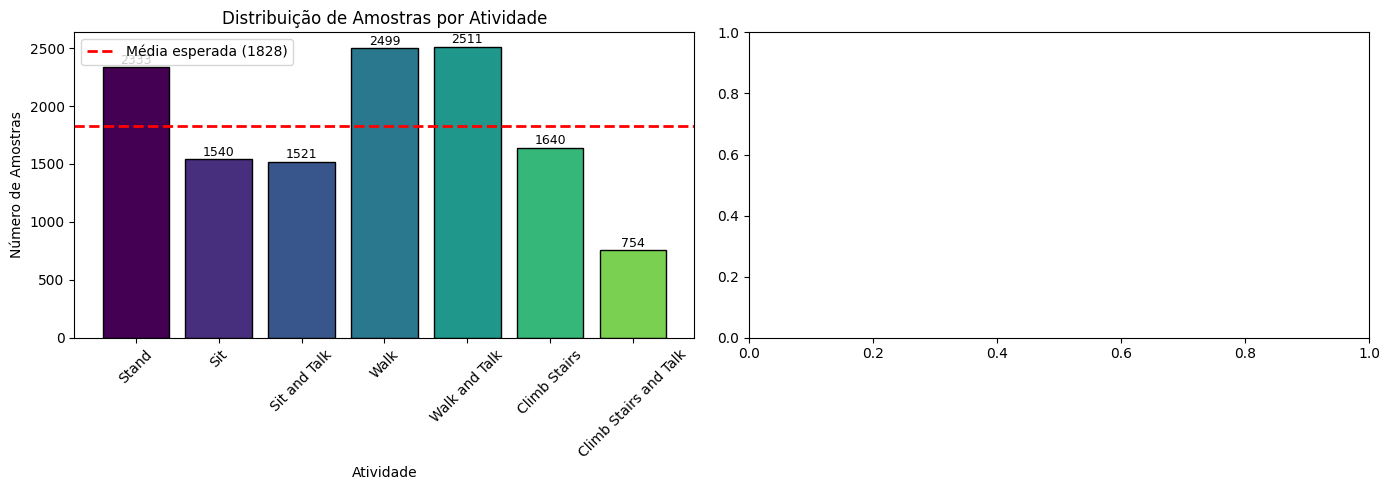

In [ ]:
def filter_activities_1_to_7(feature_matrix, labels_vector):
 
    mask = (labels_vector >= 1) & (labels_vector <= 7)
    return feature_matrix[mask], labels_vector[mask]


def analyze_class_balance(labels_vector, title="Distribuição das Atividades"):
 
    unique_activities, counts = np.unique(labels_vector, return_counts=True)
    activity_counts = dict(zip(unique_activities.astype(int), counts))
    
    print(f"\n{'='*60}")
    print(f"1.1 - {title}")
    print(f"{'='*60}")
    
    # Nomes das atividades (1-7)
    activity_names = {
        1: "Stand",
        2: "Sit", 
        3: "Sit and Talk",
        4: "Walk",
        5: "Walk and Talk",
        6: "Climb Stairs",
        7: "Climb Stairs and Talk"
    }
    
    total_samples = sum(counts)
    expected_balanced = total_samples / len(unique_activities)
    
    print(f"\n{'Atividade':<25} | {'Nº Amostras':<12} | {'Percentagem':<12} | {'Rácio vs Média':<15}")
    print("-" * 70)
    
    for act, count in activity_counts.items():
        name = activity_names.get(act, f"Atividade {act}")
        percentage = (count / total_samples) * 100
        ratio = count / expected_balanced
        print(f"{name:<25} | {count:<12} | {percentage:>10.2f}% | {ratio:>13.2f}x")
    
    print("-" * 70)
    print(f"{'TOTAL':<25} | {total_samples:<12} | {'100.00%':>12} |")
    
    # Calcular métricas de balanceamento
    min_count = min(counts)
    max_count = max(counts)
    imbalance_ratio = max_count / min_count
    
    # Critério: se o rácio de desbalanceamento for > 1.5, consideramos desbalanceado
    is_balanced = imbalance_ratio <= 1.5
    
    print(f"\n--- Métricas de Balanceamento ---")
    print(f"Classe minoritária: {min_count} amostras")
    print(f"Classe maioritária: {max_count} amostras")
    print(f"Rácio de desbalanceamento: {imbalance_ratio:.2f}")
    print(f"Dataset balanceado? {'Sim' if is_balanced else 'Não'}")
    
    # Visualização
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico de barras
    colors = plt.cm.viridis(np.linspace(0, 0.8, len(unique_activities)))
    bars = axes[0].bar([activity_names.get(int(a), f"Act {int(a)}") for a in unique_activities], 
                       counts, color=colors, edgecolor='black')
    axes[0].axhline(y=expected_balanced, color='red', linestyle='--', linewidth=2, 
                    label=f'Média esperada ({expected_balanced:.0f})')
    axes[0].set_xlabel('Atividade')
    axes[0].set_ylabel('Número de Amostras')
    axes[0].set_title('Distribuição de Amostras por Atividade')
    axes[0].legend()
    axes[0].tick_params(axis='x', rotation=45)
    
    # Adicionar valores nas barras
    for bar, count in zip(bars, counts):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                     str(count), ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    return activity_counts, is_balanced


# Carregar dados de todos os participantes para análise geral
print("A carregar dados de todos os participantes...")
data_all = upload_data("all")

if data_all.size > 0:
    print(f"Total de amostras brutas: {data_all.shape}")
    
    # Extrair features para todos os participantes
    print("\nA extrair features de todos os participantes (apenas atividades 1-7)...")
    all_features_module_b = []
    all_labels_module_b = []
    all_participants_module_b = []
    
    sensor_data_all = data_all[:, 1:10]
    activity_labels_all = data_all[:, 11]
    
    # Identificar participante pelo nome do ficheiro (aproximação via índices)
    # Para simplificar, vamos extrair features de todas as janelas
    for start, win_data, win_label in sliding_windows(sensor_data_all, activity_labels_all):
        # Filtrar apenas atividades 1-7
        if 1 <= win_label <= 7:
            feat_dict = extract_features_window(win_data)
            all_features_module_b.append(list(feat_dict.values()))
            all_labels_module_b.append(win_label)
    
    feature_matrix_b = np.array(all_features_module_b)
    labels_vector_b = np.array(all_labels_module_b)
    
    print(f"\nFeatures extraídas (atividades 1-7): {feature_matrix_b.shape[0]} janelas")
    print(f"Número de features por janela: {feature_matrix_b.shape[1]}")
    
    # Analisar balanceamento
    activity_counts, is_balanced = analyze_class_balance(labels_vector_b)
else:
    print("ERRO: Não foi possível carregar os dados.")

#### 1.2 Função SMOTE para Data Augmentation

Implementação de uma função que recebe o dataset e aplica o método SMOTE (Synthetic Minority Over-sampling Technique) para gerar K novas amostras sintéticas para uma atividade específica A.

In [ ]:
def generate_smote_samples(feature_matrix, labels_vector, activity_id, k_samples, k_neighbors=5, random_state=42):
    np.random.seed(random_state)
    
    activity_mask = labels_vector == activity_id
    activity_samples = feature_matrix[activity_mask]
    n_activity_samples = activity_samples.shape[0]
    
    if n_activity_samples == 0:
        print(f"ERRO: Não existem amostras para a atividade {activity_id}")
        return None, feature_matrix, labels_vector
    
    if n_activity_samples < k_neighbors:
        print(f"AVISO: Número de amostras ({n_activity_samples}) menor que k_neighbors ({k_neighbors}).")
        print(f"Ajustando k_neighbors para {n_activity_samples - 1}")
        k_neighbors = max(1, n_activity_samples - 1)
    
    print(f"\n--- Gerando {k_samples} amostras sintéticas para Atividade {activity_id} ---")
    print(f"Amostras originais da atividade: {n_activity_samples}")
    print(f"k_neighbors utilizado: {k_neighbors}")
    
    synthetic_samples = []
    
    for _ in range(k_samples):
        idx = np.random.randint(0, n_activity_samples)
        sample = activity_samples[idx]
        
        distances = np.linalg.norm(activity_samples - sample, axis=1)
        neighbor_indices = np.argsort(distances)[1:k_neighbors+1]
        neighbor_idx = np.random.choice(neighbor_indices)
        neighbor = activity_samples[neighbor_idx]
        
        lambda_val = np.random.random()
        synthetic_sample = sample + lambda_val * (neighbor - sample) 
        synthetic_samples.append(synthetic_sample)
    
    synthetic_samples = np.array(synthetic_samples)
    
    # Criar dataset aumentado
    augmented_features = np.vstack([feature_matrix, synthetic_samples])
    augmented_labels = np.concatenate([labels_vector, np.full(k_samples, activity_id)])
    
    print(f"Amostras sintéticas geradas: {synthetic_samples.shape[0]}")
    print(f"Dataset aumentado: {augmented_features.shape[0]} amostras totais")
    
    return synthetic_samples, augmented_features, augmented_labels


def generate_smote_samples_imblearn(feature_matrix, labels_vector, activity_id, k_samples, k_neighbors=5, random_state=42):
    print(f"\n--- SMOTE (imblearn) - Gerando {k_samples} amostras para Atividade {activity_id} ---")
    
    unique_classes, counts = np.unique(labels_vector, return_counts=True)
    class_counts = dict(zip(unique_classes, counts))
    
    current_count = class_counts.get(activity_id, 0)
    
    if current_count == 0:
        print(f"ERRO: Não existem amostras para a atividade {activity_id}")
        return None, feature_matrix, labels_vector
    
    print(f"Amostras atuais da atividade {activity_id}: {current_count}")
    
    target_count = current_count + k_samples
    sampling_strategy = {cls: count for cls, count in class_counts.items()}
    sampling_strategy[activity_id] = target_count
    
    effective_k_neighbors = min(k_neighbors, current_count - 1)
    if effective_k_neighbors < 1:
        effective_k_neighbors = 1
    
    print(f"k_neighbors efetivo: {effective_k_neighbors}")
    
    smote = SMOTE(sampling_strategy=sampling_strategy, 
                  k_neighbors=effective_k_neighbors, 
                  random_state=random_state)
    
    augmented_features, augmented_labels = smote.fit_resample(feature_matrix, labels_vector)
    
    n_original = feature_matrix.shape[0]
    synthetic_samples = augmented_features[n_original:]
    
    print(f"Amostras sintéticas geradas: {len(synthetic_samples)}")
    print(f"Dataset aumentado: {augmented_features.shape[0]} amostras totais")
    
    return synthetic_samples, augmented_features, augmented_labels

#### 1.3 Geração e Visualização de Amostras Sintéticas

Geramos 3 novas amostras sintéticas para a atividade 4 (Walk) do participante 3, utilizando apenas os dados desse participante. A visualização é feita com um scatter plot 2D usando as duas primeiras features, com cores diferentes por atividade e destaque para as amostras sintéticas.


1.3 - Geração de 3 Amostras Sintéticas (SMOTE)
A carregar dados do participante 3...
A carregar dados do participante: part3
Features extraídas: 859 janelas, 101 features

--- Distribuição de atividades do Participante 3 ---
Atividade 1: 153 amostras
Atividade 2: 106 amostras
Atividade 3: 107 amostras
Atividade 4: 165 amostras
Atividade 5: 168 amostras
Atividade 6: 108 amostras
Atividade 7: 52 amostras

--- SMOTE (imblearn) - Gerando 3 amostras para Atividade 4 ---
Amostras atuais da atividade 4: 165
k_neighbors efetivo: 5
Amostras sintéticas geradas: 3
Dataset aumentado: 862 amostras totais
Features extraídas: 859 janelas, 101 features

--- Distribuição de atividades do Participante 3 ---
Atividade 1: 153 amostras
Atividade 2: 106 amostras
Atividade 3: 107 amostras
Atividade 4: 165 amostras
Atividade 5: 168 amostras
Atividade 6: 108 amostras
Atividade 7: 52 amostras

--- SMOTE (imblearn) - Gerando 3 amostras para Atividade 4 ---
Amostras atuais da atividade 4: 165
k_neighbors efetivo

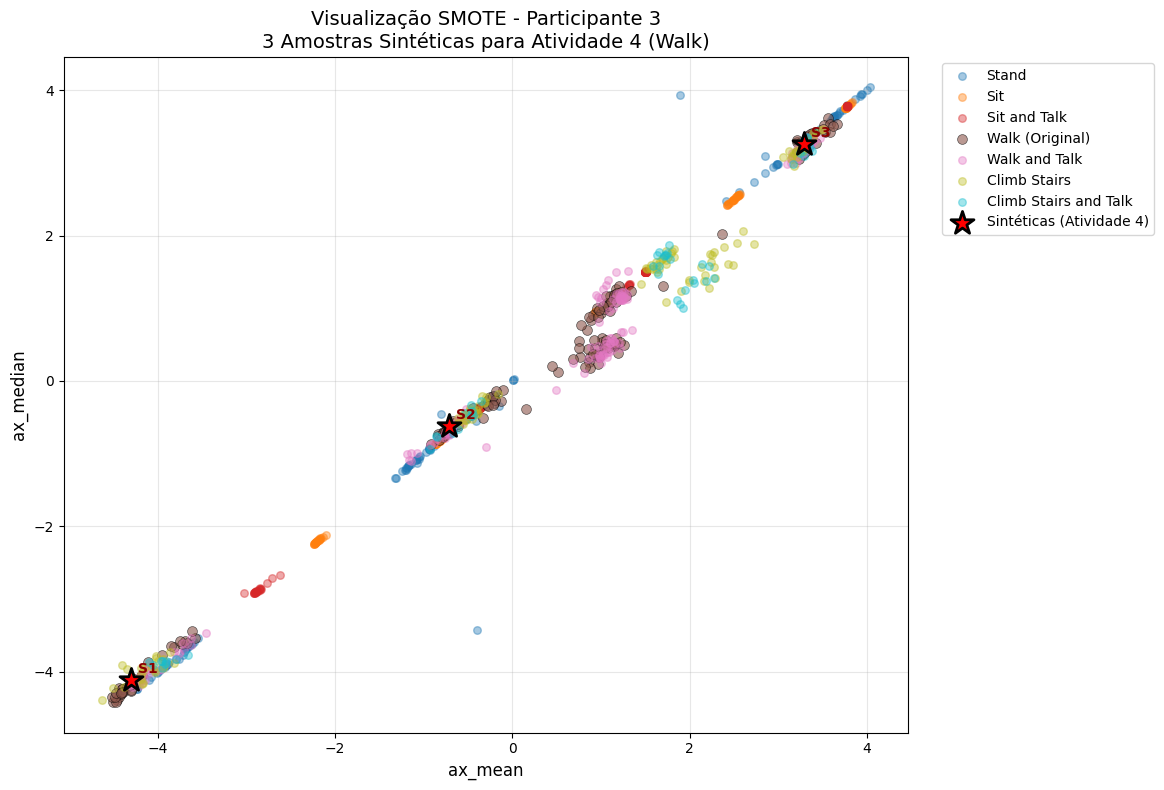


--- Amostras Sintéticas Geradas ---
Feature 1 (ax_mean): [-4.29978975 -0.71147388  3.29213001]
Feature 2 (ax_median): [-4.11160925 -0.61424114  3.25972678]


In [27]:
def extract_features_for_participant(participant_id, max_activity=7):
    
    print(f"A carregar dados do participante {participant_id}...")
    data = upload_data(participant_id)
    
    if data.size == 0:
        print(f"ERRO: Não foram encontrados dados para o participante {participant_id}")
        return None, None, None
    
    features_list = []
    labels_list = []
    
    sensor_data = data[:, 1:10]
    activity_labels = data[:, 11]
    
    for start, win_data, win_label in sliding_windows(sensor_data, activity_labels):
        if 1 <= win_label <= max_activity:
            feat_dict = extract_features_window(win_data)
            features_list.append(list(feat_dict.values()))
            labels_list.append(win_label)
    
    if not features_list:
        print(f"ERRO: Não foram extraídas features para o participante {participant_id}")
        return None, None, None
    
    feature_matrix = np.array(features_list)
    labels_vector = np.array(labels_list)
    feature_names = list(feat_dict.keys())
    
    print(f"Features extraídas: {feature_matrix.shape[0]} janelas, {feature_matrix.shape[1]} features")
    
    return feature_matrix, labels_vector, feature_names


def visualize_smote_samples_2d(feature_matrix, labels_vector, synthetic_samples, 
                                target_activity, feature_names, participant_id):
    # Nomes das atividades
    activity_names = {
        1: "Stand", 2: "Sit", 3: "Sit and Talk", 4: "Walk",
        5: "Walk and Talk", 6: "Climb Stairs", 7: "Climb Stairs and Talk"
    }
    
    # Usar as duas primeiras features
    feat1_name = feature_names[0]
    feat2_name = feature_names[1]
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    # Cores para cada atividade
    unique_activities = np.unique(labels_vector)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_activities)))
    color_map = dict(zip(unique_activities, colors))
    
    # Plotar amostras originais por atividade
    for activity in unique_activities:
        mask = labels_vector == activity
        activity_data = feature_matrix[mask]
        label = activity_names.get(int(activity), f"Act {int(activity)}")
        
        # Destaque diferente para a atividade alvo
        if activity == target_activity:
            ax.scatter(activity_data[:, 0], activity_data[:, 1], 
                      c=[color_map[activity]], label=f"{label} (Original)", 
                      alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
        else:
            ax.scatter(activity_data[:, 0], activity_data[:, 1], 
                      c=[color_map[activity]], label=label, 
                      alpha=0.4, s=30)
    
    # Plotar amostras sintéticas com destaque especial
    if synthetic_samples is not None and len(synthetic_samples) > 0:
        ax.scatter(synthetic_samples[:, 0], synthetic_samples[:, 1], 
                  c='red', marker='*', s=300, edgecolors='black', linewidth=2,
                  label=f'Sintéticas (Atividade {int(target_activity)})', zorder=5)
        
        # Adicionar anotações para cada amostra sintética
        for i, (x, y) in enumerate(zip(synthetic_samples[:, 0], synthetic_samples[:, 1])):
            ax.annotate(f'S{i+1}', (x, y), xytext=(5, 5), textcoords='offset points',
                       fontsize=10, fontweight='bold', color='darkred')
    
    ax.set_xlabel(feat1_name, fontsize=12)
    ax.set_ylabel(feat2_name, fontsize=12)
    ax.set_title(f'Visualização SMOTE - Participante {participant_id}\n'
                 f'3 Amostras Sintéticas para Atividade {int(target_activity)} ({activity_names.get(int(target_activity), "")})',
                 fontsize=14)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Imprimir informação sobre as amostras sintéticas
    print(f"\n--- Amostras Sintéticas Geradas ---")
    print(f"Feature 1 ({feat1_name}): {synthetic_samples[:, 0]}")
    print(f"Feature 2 ({feat2_name}): {synthetic_samples[:, 1]}")


# Executar para participante 3, atividade 4 (Walk)
print(f"\n{'='*60}")
print("1.3 - Geração de 3 Amostras Sintéticas (SMOTE)")
print(f"{'='*60}")

PARTICIPANT_ID = 3
TARGET_ACTIVITY = 4
K_SAMPLES = 3

# Extrair features do participante 3
feat_matrix_p3, labels_p3, feat_names_p3 = extract_features_for_participant(PARTICIPANT_ID, max_activity=7)

if feat_matrix_p3 is not None:
    # Mostrar distribuição das atividades do participante 3
    print(f"\n--- Distribuição de atividades do Participante {PARTICIPANT_ID} ---")
    unique_acts, counts = np.unique(labels_p3, return_counts=True)
    for act, count in zip(unique_acts, counts):
        print(f"Atividade {int(act)}: {count} amostras")
    
    # Gerar 3 amostras sintéticas para atividade 4
    synthetic_samples_p3, augmented_features_p3, augmented_labels_p3 = generate_smote_samples_imblearn(
        feat_matrix_p3, labels_p3, 
        activity_id=TARGET_ACTIVITY, 
        k_samples=K_SAMPLES,
        k_neighbors=5,
        random_state=42
    )
    
    # Visualizar
    if synthetic_samples_p3 is not None:
        visualize_smote_samples_2d(
            feat_matrix_p3, labels_p3, 
            synthetic_samples_p3, 
            TARGET_ACTIVITY, 
            feat_names_p3, 
            PARTICIPANT_ID
        )
else:
    print("Não foi possível extrair features do participante.")

### 2. Embedding Features

Uma alternativa à extração explícita de features é usar modelos que aprendem representações diretamente dos dados brutos. Utilizamos transfer learning com o modelo **harnet5** do projeto ssl-wearables, removendo as camadas de classificação para obter as representações de features (embeddings).

**Referência:** [ssl-wearables GitHub](https://github.com/OxWearables/ssl-wearables) | [Paper](https://www.nature.com/articles/s41746-024-01062-3)

#### 2.1 Extração de Embeddings do Acelerómetro

Utilizamos apenas os valores x, y, z do acelerómetro. Para cada segmento de 5 segundos:
1. Reamostragem para 30Hz (150 amostras)
2. Extração dos embeddings usando o modelo harnet5 pré-treinado

O resultado é o **EMBEDDINGS DATASET** com shape `[n_segments, n_embeddings]`.

In [ ]:
def extract_embeddings_dataset(data, feature_encoder, max_activity=7, batch_size=32):
   
    print(f"\n{'='*60}")
    print("2.1 - Extração de Embeddings (EMBEDDINGS DATASET)")
    print(f"{'='*60}")
    
    # Parâmetros
    FS_ORIGINAL = FS  # 100 Hz (definido globalmente)
    FS_TARGET = 30.0  # Frequência alvo para o modelo
    WIN_SEC = 5.0     # Janela de 5 segundos
    WIN_LEN_ORIGINAL = int(WIN_SEC * FS_ORIGINAL)  # 500 amostras a 100Hz
    WIN_STEP = WIN_LEN_ORIGINAL // 2  # 50% overlap
    
    print(f"Frequência original: {FS_ORIGINAL} Hz")
    print(f"Frequência alvo (resampling): {FS_TARGET} Hz")
    print(f"Tamanho da janela: {WIN_SEC} segundos")
    print(f"Amostras por janela (original): {WIN_LEN_ORIGINAL}")
    print(f"Amostras por janela (após resampling): {int(WIN_SEC * FS_TARGET)}")
    
    # Extrair apenas dados do acelerómetro (colunas 1, 2, 3 = ax, ay, az)
    acc_data = data[:, 1:4]  # shape: (N, 3)
    activity_labels = data[:, 11]  # última coluna
    
    segments = []
    labels = []
    
    n_samples = acc_data.shape[0]
    
    # Criar janelas deslizantes
    for start in range(0, n_samples - WIN_LEN_ORIGINAL + 1, WIN_STEP):
        end = start + WIN_LEN_ORIGINAL
        
        # Verificar se a janela tem uma única atividade
        window_labels = activity_labels[start:end]
        unique_labels = np.unique(window_labels)
        
        if len(unique_labels) == 1:
            label = unique_labels[0]
            
            # Filtrar apenas atividades 1-7
            if 1 <= label <= max_activity:
                acc_segment = acc_data[start:end]  # shape: (500, 3)
                
                # Reamostrar para 30Hz
                acc_resampled, _ = resample_to_30hz_5s(acc_segment, FS_ORIGINAL)
                
                segments.append(acc_resampled)
                labels.append(label)
    
    if len(segments) == 0:
        print("ERRO: Não foram extraídos segmentos válidos.")
        return None, None
    
    print(f"Segmentos válidos extraídos: {len(segments)}")
    
    # Converter para array numpy
    # Shape esperado pelo modelo: [n_segments, 3, 150] (canais x tempo)
    segments_array = np.array(segments)  # shape: (n_segments, 150, 3)
    segments_array = np.transpose(segments_array, (0, 2, 1))  # shape: (n_segments, 3, 150)
    
    print(f"Shape dos segmentos para o modelo: {segments_array.shape}")
    
    # Extrair embeddings usando o modelo
    print(f"\nA extrair embeddings com o modelo harnet5...")
    
    embeddings_list = []
    
    with torch.no_grad():
        for i in range(0, segments_array.shape[0], batch_size):
            batch_end = min(i + batch_size, segments_array.shape[0])
            batch = torch.from_numpy(segments_array[i:batch_end]).float().to("cpu")
            
            # Forward pass através do encoder
            embeddings_batch = feature_encoder(batch)
            
            # Converter para numpy e flatten se necessário (pode ser 3D: batch x channels x time)
            emb_np = embeddings_batch.cpu().numpy()
            if emb_np.ndim == 3:
                # Flatten: (batch, channels, time) -> (batch, channels * time)
                emb_np = emb_np.reshape(emb_np.shape[0], -1)
            
            embeddings_list.append(emb_np)
    
    # Concatenar todos os embeddings
    embeddings_matrix = np.concatenate(embeddings_list, axis=0)
    labels_vector = np.array(labels)
    
    print(f"\n--- EMBEDDINGS DATASET ---")
    print(f"Shape: {embeddings_matrix.shape}")
    print(f"Número de segmentos: {embeddings_matrix.shape[0]}")
    print(f"Número de embeddings por segmento: {embeddings_matrix.shape[1]}")
    
    return embeddings_matrix, labels_vector


def compare_datasets_info(features_dataset, features_labels, embeddings_dataset, embeddings_labels):
    """
    Compara informações entre o FEATURES DATASET e o EMBEDDINGS DATASET.
    """
    print(f"\n{'='*60}")
    print("Comparação: FEATURES DATASET vs EMBEDDINGS DATASET")
    print(f"{'='*60}")
    
    print(f"\n{'Métrica':<30} | {'FEATURES':<20} | {'EMBEDDINGS':<20}")
    print("-" * 75)
    print(f"{'Número de segmentos':<30} | {features_dataset.shape[0]:<20} | {embeddings_dataset.shape[0]:<20}")
    print(f"{'Número de features/embeddings':<30} | {features_dataset.shape[1]:<20} | {embeddings_dataset.shape[1]:<20}")
    print(f"{'Memória (MB aprox.)':<30} | {features_dataset.nbytes / 1e6:<20.2f} | {embeddings_dataset.nbytes / 1e6:<20.2f}")
    
    # Distribuição de atividades
    print(f"\n--- Distribuição de Atividades ---")
    print(f"{'Atividade':<15} | {'FEATURES':<15} | {'EMBEDDINGS':<15}")
    print("-" * 50)
    
    unique_activities = np.unique(np.concatenate([features_labels, embeddings_labels]))
    
    for act in unique_activities:
        feat_count = np.sum(features_labels == act)
        emb_count = np.sum(embeddings_labels == act)
        print(f"{int(act):<15} | {feat_count:<15} | {emb_count:<15}")


# Extrair embeddings para todos os participantes (atividades 1-7)
print("A extrair embeddings de todos os participantes...")

# Usar os dados já carregados (data_all)
embeddings_dataset, embeddings_labels = extract_embeddings_dataset(
    data_all, 
    feature_encoder, 
    max_activity=7, 
    batch_size=64
)

if embeddings_dataset is not None:
    # Comparar com o FEATURES DATASET (feature_matrix_b e labels_vector_b já existem)
    compare_datasets_info(
        feature_matrix_b, labels_vector_b,
        embeddings_dataset, embeddings_labels
    )
    
    # Visualizar distribuição dos embeddings usando PCA
    print(f"\n--- Visualização PCA dos Embeddings ---")
    
    # Aplicar PCA para reduzir a 2D
    pca_emb = PCA(n_components=2)
    embeddings_2d = pca_emb.fit_transform(embeddings_dataset)
    
    print(f"Variância explicada pelas 2 primeiras componentes: {sum(pca_emb.explained_variance_ratio_)*100:.2f}%")
    
    # Nomes das atividades
    activity_names = {
        1: "Stand", 2: "Sit", 3: "Sit and Talk", 4: "Walk",
        5: "Walk and Talk", 6: "Climb Stairs", 7: "Climb Stairs and Talk"
    }
    
else:
    print("Não foi possível extrair embeddings.")

A extrair embeddings de todos os participantes...

2.1 - Extração de Embeddings (EMBEDDINGS DATASET)
Frequência original: 100 Hz
Frequência alvo (resampling): 30.0 Hz
Tamanho da janela: 5.0 segundos
Amostras por janela (original): 500
Amostras por janela (após resampling): 150
Segmentos válidos extraídos: 12798
Shape dos segmentos para o modelo: (12798, 3, 150)

A extrair embeddings com o modelo harnet5...

--- EMBEDDINGS DATASET ---
Shape: (12798, 512)
Número de segmentos: 12798
Número de embeddings por segmento: 512

Comparação: FEATURES DATASET vs EMBEDDINGS DATASET

Métrica                        | FEATURES             | EMBEDDINGS          
---------------------------------------------------------------------------
Número de segmentos            | 12798                | 12798               
Número de features/embeddings  | 101                  | 512                 
Memória (MB aprox.)            | 10.34                | 26.21               

--- Distribuição de Atividades ---
Ati

### 3. Data Splitting Strategy

Implementamos duas estratégias de divisão dos dados em conjuntos de treino, validação e teste:
- **Within-subject (3.1)**: Dados de cada participante são divididos e distribuídos por todos os conjuntos (60-20-20%)
- **Between-subjects (3.2)**: Participantes inteiros são alocados a conjuntos diferentes (9 treino, 3 validação, 3 teste)

#### 3.0 Extração de Features e Embeddings por Participante

Primeiro, precisamos re-extrair os datasets mantendo o registo do ID do participante para cada amostra.

In [ ]:
def extract_features_with_participant_ids(max_activity=7):
  
    print(f"\n{'='*60}")
    print("3.0 - Extração de Features com IDs de Participantes")
    print(f"{'='*60}")
    
    all_features = []
    all_labels = []
    all_participant_ids = []
    
    # Número de participantes (0-14)
    n_participants = 15
    
    for p_id in range(n_participants):
        print(f"A processar participante {p_id}...", end=" ")
        
        data = upload_data(p_id)
        if data.size == 0:
            print("Sem dados.")
            continue
        
        sensor_data = data[:, 1:10]  # ax, ay, az, gx, gy, gz, mx, my, mz
        activity_labels = data[:, 11]
        
        p_features = []
        p_labels = []
        
        for start, win_data, win_label in sliding_windows(sensor_data, activity_labels):
            if 1 <= win_label <= max_activity:
                feat_dict = extract_features_window(win_data)
                p_features.append(list(feat_dict.values()))
                p_labels.append(win_label)
        
        n_samples = len(p_features)
        print(f"{n_samples} amostras extraídas.")
        
        all_features.extend(p_features)
        all_labels.extend(p_labels)
        all_participant_ids.extend([p_id] * n_samples)
    
    features = np.array(all_features)
    labels = np.array(all_labels)
    participant_ids = np.array(all_participant_ids)
    feature_names = list(feat_dict.keys()) if feat_dict else []
    
    print(f"\n--- FEATURES DATASET (com participant IDs) ---")
    print(f"Shape: {features.shape}")
    print(f"Participantes únicos: {np.unique(participant_ids)}")
    
    return features, labels, participant_ids, feature_names


def extract_embeddings_with_participant_ids(feature_encoder, max_activity=7, batch_size=64):
    
    print(f"\n{'='*60}")
    print("3.0 - Extração de Embeddings com IDs de Participantes")
    print(f"{'='*60}")
    
    all_embeddings = []
    all_labels = []
    all_participant_ids = []
    
    FS_ORIGINAL = FS
    WIN_SEC = 5.0
    WIN_LEN_ORIGINAL = int(WIN_SEC * FS_ORIGINAL)
    WIN_STEP = WIN_LEN_ORIGINAL // 2
    
    n_participants = 15
    
    for p_id in range(n_participants):
        print(f"A processar participante {p_id}...", end=" ")
        
        data = upload_data(p_id)
        if data.size == 0:
            print("Sem dados.")
            continue
        
        acc_data = data[:, 1:4]  # ax, ay, az
        activity_labels = data[:, 11]
        
        segments = []
        p_labels = []
        
        n_samples = acc_data.shape[0]
        
        for start in range(0, n_samples - WIN_LEN_ORIGINAL + 1, WIN_STEP):
            end = start + WIN_LEN_ORIGINAL
            window_labels = activity_labels[start:end]
            unique_labels = np.unique(window_labels)
            
            if len(unique_labels) == 1:
                label = unique_labels[0]
                if 1 <= label <= max_activity:
                    acc_segment = acc_data[start:end]
                    acc_resampled, _ = resample_to_30hz_5s(acc_segment, FS_ORIGINAL)
                    segments.append(acc_resampled)
                    p_labels.append(label)
        
        if len(segments) == 0:
            print("Sem segmentos válidos.")
            continue
        
        # Extrair embeddings para este participante
        segments_array = np.array(segments)
        segments_array = np.transpose(segments_array, (0, 2, 1))
        
        embeddings_list = []
        with torch.no_grad():
            for i in range(0, segments_array.shape[0], batch_size):
                batch_end = min(i + batch_size, segments_array.shape[0])
                batch = torch.from_numpy(segments_array[i:batch_end]).float().to("cpu")
                embeddings_batch = feature_encoder(batch)
                emb_np = embeddings_batch.cpu().numpy()
                if emb_np.ndim == 3:
                    emb_np = emb_np.reshape(emb_np.shape[0], -1)
                embeddings_list.append(emb_np)
        
        p_embeddings = np.concatenate(embeddings_list, axis=0)
        n_samples = p_embeddings.shape[0]
        print(f"{n_samples} amostras extraídas.")
        
        all_embeddings.append(p_embeddings)
        all_labels.extend(p_labels)
        all_participant_ids.extend([p_id] * n_samples)
    
    embeddings = np.concatenate(all_embeddings, axis=0)
    labels = np.array(all_labels)
    participant_ids = np.array(all_participant_ids)
    
    print(f"\n--- EMBEDDINGS DATASET (com participant IDs) ---")
    print(f"Shape: {embeddings.shape}")
    print(f"Participantes únicos: {np.unique(participant_ids)}")
    
    return embeddings, labels, participant_ids


# Extrair features e embeddings com IDs de participantes
print("A extrair FEATURES DATASET com participant IDs...")
features_data, features_labels, features_participant_ids, feature_names_list = extract_features_with_participant_ids(max_activity=7)

print("\n" + "="*60)
print("A extrair EMBEDDINGS DATASET com participant IDs...")
embeddings_data, embeddings_labels, embeddings_participant_ids = extract_embeddings_with_participant_ids(feature_encoder, max_activity=7)

A extrair FEATURES DATASET com participant IDs...

3.0 - Extração de Features com IDs de Participantes
A processar participante 0... A carregar dados do participante: part0
864 amostras extraídas.
A processar participante 1... A carregar dados do participante: part1
859 amostras extraídas.
A processar participante 2... A carregar dados do participante: part2
876 amostras extraídas.
A processar participante 3... A carregar dados do participante: part3
859 amostras extraídas.
A processar participante 4... A carregar dados do participante: part4
799 amostras extraídas.
A processar participante 5... A carregar dados do participante: part5
853 amostras extraídas.
A processar participante 6... A carregar dados do participante: part6
878 amostras extraídas.
A processar participante 7... A carregar dados do participante: part7
853 amostras extraídas.
A processar participante 8... A carregar dados do participante: part8
821 amostras extraídas.
A processar participante 9... A carregar dados do p

#### 3.1 Within-Subject Split (60-20-20%)

Divisão intra-participante: os dados de cada participante são divididos em treino (60%), validação (20%) e teste (20%), e depois agregados.

In [ ]:
def within_subject_split(data, labels, participant_ids, train_ratio=0.6, val_ratio=0.2, test_ratio=0.2, random_state=42):
    
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6, "Ratios devem somar 1.0"
    
    np.random.seed(random_state)
    
    unique_participants = np.unique(participant_ids)
    
    train_data, train_labels, train_pids = [], [], []
    val_data, val_labels, val_pids = [], [], []
    test_data, test_labels, test_pids = [], [], []
    
    for p_id in unique_participants:
        # Obter índices deste participante
        p_mask = participant_ids == p_id
        p_data = data[p_mask]
        p_labels = labels[p_mask]
        n_samples = len(p_data)
        
        # Shuffle dos índices
        indices = np.random.permutation(n_samples)
        
        # Calcular pontos de corte
        train_end = int(n_samples * train_ratio)
        val_end = train_end + int(n_samples * val_ratio)
        
        # Dividir
        train_idx = indices[:train_end]
        val_idx = indices[train_end:val_end]
        test_idx = indices[val_end:]
        
        train_data.append(p_data[train_idx])
        train_labels.append(p_labels[train_idx])
        train_pids.extend([p_id] * len(train_idx))
        
        val_data.append(p_data[val_idx])
        val_labels.append(p_labels[val_idx])
        val_pids.extend([p_id] * len(val_idx))
        
        test_data.append(p_data[test_idx])
        test_labels.append(p_labels[test_idx])
        test_pids.extend([p_id] * len(test_idx))
    
    result = {
        'train': {
            'data': np.concatenate(train_data, axis=0),
            'labels': np.concatenate(train_labels),
            'participant_ids': np.array(train_pids)
        },
        'val': {
            'data': np.concatenate(val_data, axis=0),
            'labels': np.concatenate(val_labels),
            'participant_ids': np.array(val_pids)
        },
        'test': {
            'data': np.concatenate(test_data, axis=0),
            'labels': np.concatenate(test_labels),
            'participant_ids': np.array(test_pids)
        }
    }
    
    return result


def print_split_info(split_dict, dataset_name):
    """Imprime informações sobre um split de dados."""
    print(f"\n{'='*60}")
    print(f"Within-Subject Split - {dataset_name}")
    print(f"{'='*60}")
    
    total = sum(split_dict[s]['data'].shape[0] for s in ['train', 'val', 'test'])
    
    print(f"\n{'Conjunto':<12} | {'Amostras':<10} | {'%':<8} | {'Shape':<20}")
    print("-" * 55)
    
    for split_name in ['train', 'val', 'test']:
        n = split_dict[split_name]['data'].shape[0]
        shape = split_dict[split_name]['data'].shape
        pct = (n / total) * 100
        print(f"{split_name.capitalize():<12} | {n:<10} | {pct:>6.1f}% | {str(shape):<20}")
    
    print("-" * 55)
    print(f"{'TOTAL':<12} | {total:<10} | {'100.0%':>7} |")
    
    # Distribuição de atividades por conjunto
    print(f"\n--- Distribuição de Atividades por Conjunto ---")
    print(f"{'Atividade':<12} | {'Train':<10} | {'Val':<10} | {'Test':<10}")
    print("-" * 50)
    
    all_activities = np.unique(np.concatenate([
        split_dict['train']['labels'],
        split_dict['val']['labels'],
        split_dict['test']['labels']
    ]))
    
    for act in all_activities:
        train_count = np.sum(split_dict['train']['labels'] == act)
        val_count = np.sum(split_dict['val']['labels'] == act)
        test_count = np.sum(split_dict['test']['labels'] == act)
        print(f"{int(act):<12} | {train_count:<10} | {val_count:<10} | {test_count:<10}")


# Aplicar within-subject split aos dois datasets
print(f"\n{'='*60}")
print("3.1 - Within-Subject Split (60-20-20%)")
print(f"{'='*60}")

# FEATURES DATASET
features_within_split = within_subject_split(
    features_data, features_labels, features_participant_ids,
    train_ratio=0.6, val_ratio=0.2, test_ratio=0.2, random_state=42
)
print_split_info(features_within_split, "FEATURES DATASET")

# EMBEDDINGS DATASET
embeddings_within_split = within_subject_split(
    embeddings_data, embeddings_labels, embeddings_participant_ids,
    train_ratio=0.6, val_ratio=0.2, test_ratio=0.2, random_state=42
)
print_split_info(embeddings_within_split, "EMBEDDINGS DATASET")


3.1 - Within-Subject Split (60-20-20%)

Within-Subject Split - FEATURES DATASET

Conjunto     | Amostras   | %        | Shape               
-------------------------------------------------------
Train        | 7646       |   59.9% | (7646, 101)         
Val          | 2543       |   19.9% | (2543, 101)         
Test         | 2567       |   20.1% | (2567, 101)         
-------------------------------------------------------
TOTAL        | 12756      |  100.0% |

--- Distribuição de Atividades por Conjunto ---
Atividade    | Train      | Val        | Test      
--------------------------------------------------
1            | 1433       | 424        | 462       
2            | 945        | 278        | 305       
3            | 900        | 310        | 321       
4            | 1482       | 517        | 481       
5            | 1492       | 527        | 508       
6            | 963        | 340        | 333       
7            | 431        | 147        | 157       

Within-Subject

#### 3.2 Between-Subjects Split (9-3-3)

Divisão inter-participante: participantes inteiros são alocados a conjuntos diferentes.
- **Treino**: 9 participantes
- **Validação**: 3 participantes  
- **Teste**: 3 participantes

Esta estratégia simula um cenário mais realista onde o modelo é testado em utilizadores completamente novos.

In [ ]:
def between_subjects_split(data, labels, participant_ids, 
                           n_train=9, n_val=3, n_test=3, random_state=42):
 
    np.random.seed(random_state)
    
    unique_participants = np.unique(participant_ids)
    n_participants = len(unique_participants)
    
    assert n_train + n_val + n_test == n_participants, \
        f"Soma dos participantes ({n_train}+{n_val}+{n_test}) deve ser igual ao total ({n_participants})"
    
    # Shuffle dos participantes
    shuffled_participants = np.random.permutation(unique_participants)
    
    # Alocar participantes a cada conjunto
    train_participants = shuffled_participants[:n_train]
    val_participants = shuffled_participants[n_train:n_train+n_val]
    test_participants = shuffled_participants[n_train+n_val:]
    
    # Criar máscaras para cada conjunto
    train_mask = np.isin(participant_ids, train_participants)
    val_mask = np.isin(participant_ids, val_participants)
    test_mask = np.isin(participant_ids, test_participants)
    
    result = {
        'train': {
            'data': data[train_mask],
            'labels': labels[train_mask],
            'participant_ids': participant_ids[train_mask]
        },
        'val': {
            'data': data[val_mask],
            'labels': labels[val_mask],
            'participant_ids': participant_ids[val_mask]
        },
        'test': {
            'data': data[test_mask],
            'labels': labels[test_mask],
            'participant_ids': participant_ids[test_mask]
        }
    }
    
    participant_allocation = {
        'train': train_participants,
        'val': val_participants,
        'test': test_participants
    }
    
    return result, participant_allocation


def print_between_split_info(split_dict, participant_allocation, dataset_name):
    """Imprime informações sobre um split between-subjects."""
    print(f"\n{'='*60}")
    print(f"Between-Subjects Split - {dataset_name}")
    print(f"{'='*60}")
    
    # Alocação de participantes
    print(f"\n--- Alocação de Participantes ---")
    for split_name in ['train', 'val', 'test']:
        pids = sorted(participant_allocation[split_name])
        print(f"{split_name.capitalize():<12}: Participantes {list(pids)}")
    
    total = sum(split_dict[s]['data'].shape[0] for s in ['train', 'val', 'test'])
    
    print(f"\n{'Conjunto':<12} | {'Participantes':<12} | {'Amostras':<10} | {'%':<8}")
    print("-" * 55)
    
    for split_name in ['train', 'val', 'test']:
        n = split_dict[split_name]['data'].shape[0]
        n_p = len(participant_allocation[split_name])
        pct = (n / total) * 100
        print(f"{split_name.capitalize():<12} | {n_p:<12} | {n:<10} | {pct:>6.1f}%")
    
    print("-" * 55)
    print(f"{'TOTAL':<12} | {15:<12} | {total:<10} | {'100.0%':>7}")
    
    # Distribuição de atividades por conjunto
    print(f"\n--- Distribuição de Atividades por Conjunto ---")
    print(f"{'Atividade':<12} | {'Train':<10} | {'Val':<10} | {'Test':<10}")
    print("-" * 50)
    
    all_activities = np.unique(np.concatenate([
        split_dict['train']['labels'],
        split_dict['val']['labels'],
        split_dict['test']['labels']
    ]))
    
    for act in all_activities:
        train_count = np.sum(split_dict['train']['labels'] == act)
        val_count = np.sum(split_dict['val']['labels'] == act)
        test_count = np.sum(split_dict['test']['labels'] == act)
        print(f"{int(act):<12} | {train_count:<10} | {val_count:<10} | {test_count:<10}")


# Aplicar between-subjects split aos dois datasets
print(f"\n{'='*60}")
print("3.2 - Between-Subjects Split (9-3-3)")
print(f"{'='*60}")

# FEATURES DATASET
features_between_split, features_participant_alloc = between_subjects_split(
    features_data, features_labels, features_participant_ids,
    n_train=9, n_val=3, n_test=3, random_state=42
)
print_between_split_info(features_between_split, features_participant_alloc, "FEATURES DATASET")

# EMBEDDINGS DATASET
embeddings_between_split, embeddings_participant_alloc = between_subjects_split(
    embeddings_data, embeddings_labels, embeddings_participant_ids,
    n_train=9, n_val=3, n_test=3, random_state=42
)
print_between_split_info(embeddings_between_split, embeddings_participant_alloc, "EMBEDDINGS DATASET")


3.2 - Between-Subjects Split (9-3-3)

Between-Subjects Split - FEATURES DATASET

--- Alocação de Participantes ---
Train       : Participantes [np.int64(0), np.int64(1), np.int64(2), np.int64(5), np.int64(8), np.int64(9), np.int64(11), np.int64(13), np.int64(14)]
Val         : Participantes [np.int64(4), np.int64(7), np.int64(10)]
Test        : Participantes [np.int64(3), np.int64(6), np.int64(12)]

Conjunto     | Participantes | Amostras   | %       
-------------------------------------------------------
Train        | 9            | 7659       |   60.0%
Val          | 3            | 2497       |   19.6%
Test         | 3            | 2600       |   20.4%
-------------------------------------------------------
TOTAL        | 15           | 12756      |  100.0%

--- Distribuição de Atividades por Conjunto ---
Atividade    | Train      | Val        | Test      
--------------------------------------------------
1            | 1372       | 459        | 488       
2            | 911     

#### 3.3 Discussão: Within-Subject vs Between-Subjects

##### Diferenças Fundamentais

| Aspeto | Within-Subject (60-20-20%) | Between-Subjects (9-3-3) |
|--------|----------------------------|--------------------------|
| **Unidade de divisão** | Amostras individuais | Participantes inteiros |
| **Dados no treino** | Contém amostras de todos os 15 participantes | Contém apenas 9 participantes |
| **Dados no teste** | Amostras dos mesmos 15 participantes | 3 participantes completamente novos |
| **Leakage de informação** | Potencial alto (padrões do mesmo participante em train e test) | Nenhum (participantes isolados) |
| **Performance esperada** | Geralmente **mais alta** (otimista) | Geralmente **mais baixa** (realista) |

##### Qual estratégia dá uma melhor estimativa para novos participantes?

**Resposta: Between-Subjects Split (9-3-3)**

##### Justificação

1. **Simulação do cenário real de deployment**
   - Quando o modelo é aplicado na prática, os novos utilizadores são pessoas que nunca foram vistas durante o treino
   - O between-subjects split replica exatamente este cenário: os 3 participantes de teste são completamente desconhecidos

2. **Evita Data Leakage**
   - No within-subject split, o modelo "vê" padrões do mesmo participante durante o treino
   - Cada pessoa tem características biomecânicas únicas (cadência, amplitude, postura)
   - O modelo pode aprender a reconhecer o "estilo" de um participante, não apenas a atividade
   - Isto resulta numa estimativa otimista e irrealista da performance

3. **Variabilidade Inter-Participante**
   - A maior fonte de variabilidade em HAR (Human Activity Recognition) é a diferença entre pessoas
   - O between-subjects split testa a capacidade de **generalização** do modelo
   - Uma boa performance indica que o modelo aprendeu padrões universais das atividades

4. **Evidência Empírica**
   - Na literatura de HAR, é consistentemente observado que:
     - Within-subject → Accuracy ~90-95%
     - Between-subjects → Accuracy ~70-85%
   - A diferença de 10-20% representa o "custo" da generalização real

##### Quando usar cada estratégia?

- **Within-Subject**: Útil para sistemas personalizados onde cada utilizador recalibra o modelo com os seus próprios dados
- **Between-Subjects**: Obrigatório para avaliar modelos "one-size-fits-all" que serão usados por novos utilizadores sem calibração

##### Conclusão

Para estimar a performance real do modelo quando aplicado a um **novo participante nunca visto**, a estratégia **between-subjects** é a única que fornece uma estimativa fiável e não enviesada. A performance observada no within-subject split é artificialmente inflacionada devido ao leakage de informação entre participantes.

#### 3.4 Pipeline de Transformação de Features

Preparamos um pipeline que transforma cada split em três cenários diferentes:
- **a) All features/embeddings**: Dataset completo (apenas normalizado)
- **b) PCA-reduced**: Redução dimensional mantendo 90% da variância
- **c) ReliefF-selected**: Top 15 features selecionadas por ReliefF

**IMPORTANTE**: PCA, ReliefF e normalização são computados **apenas no conjunto de treino** e depois aplicados a validação e teste para evitar data leakage.

In [ ]:
class FeatureTransformationPipeline:
    
    def __init__(self, pca_variance=0.90, relieff_n_features=15, relieff_n_neighbors=10):
       
        self.pca_variance = pca_variance
        self.relieff_n_features = relieff_n_features
        self.relieff_n_neighbors = relieff_n_neighbors
        
        # Transformadores (serão fitted no treino)
        self.scaler = None
        self.pca = None
        self.relieff_indices = None
        
        # Informação sobre as transformações
        self.n_pca_components = None
        self.relieff_feature_names = None
        
    def fit(self, X_train, y_train, feature_names=None):
     
        print("  Fitting StandardScaler no treino...")
        self.scaler = StandardScaler()
        X_train_scaled = self.scaler.fit_transform(X_train)
        
        # PCA (fit no treino normalizado)
        print("  Fitting PCA no treino...")
        pca_full = PCA()
        pca_full.fit(X_train_scaled)
        
        # Determinar número de componentes para 90% da variância
        cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
        self.n_pca_components = np.argmax(cumulative_variance >= self.pca_variance) + 1
        
        # Refit PCA com o número correto de componentes
        self.pca = PCA(n_components=self.n_pca_components)
        self.pca.fit(X_train_scaled)
        
        print(f"    → PCA: {self.n_pca_components} componentes explicam {self.pca_variance*100:.0f}% da variância")
        
        # ReliefF (fit no treino normalizado)
        print("  Fitting ReliefF no treino...")
        n_features_to_select = min(self.relieff_n_features, X_train_scaled.shape[1])
        
        relief = ReliefF(n_neighbors=self.relieff_n_neighbors, n_features_to_select=n_features_to_select)
        relief.fit(X_train_scaled, y_train.astype(int))
        
        # Obter índices das top features
        self.relieff_indices = np.argsort(relief.feature_importances_)[::-1][:n_features_to_select]
        
        if feature_names is not None:
            self.relieff_feature_names = [feature_names[i] for i in self.relieff_indices]
            print(f"    → ReliefF: Top {n_features_to_select} features selecionadas")
        else:
            print(f"    → ReliefF: Top {n_features_to_select} índices selecionados")
        
        return self
    
    def transform_all(self, X):
        return self.scaler.transform(X)
    
    def transform_pca(self, X):
        X_scaled = self.scaler.transform(X)
        return self.pca.transform(X_scaled)
    
    def transform_relieff(self, X):
        X_scaled = self.scaler.transform(X)
        return X_scaled[:, self.relieff_indices]
    
    def transform_split(self, split_dict):
        scenarios = {
            'all_features': {},
            'pca_reduced': {},
            'relieff_selected': {}
        }
        
        for set_name in ['train', 'val', 'test']:
            X = split_dict[set_name]['data']
            
            scenarios['all_features'][set_name] = {
                'data': self.transform_all(X),
                'labels': split_dict[set_name]['labels'],
                'participant_ids': split_dict[set_name]['participant_ids']
            }
            
            scenarios['pca_reduced'][set_name] = {
                'data': self.transform_pca(X),
                'labels': split_dict[set_name]['labels'],
                'participant_ids': split_dict[set_name]['participant_ids']
            }
            
            scenarios['relieff_selected'][set_name] = {
                'data': self.transform_relieff(X),
                'labels': split_dict[set_name]['labels'],
                'participant_ids': split_dict[set_name]['participant_ids']
            }
        
        return scenarios
    
    def get_info(self):
        return {
            'pca_n_components': self.n_pca_components,
            'pca_variance_explained': self.pca_variance,
            'relieff_n_features': len(self.relieff_indices) if self.relieff_indices is not None else 0,
            'relieff_feature_names': self.relieff_feature_names
        }


def apply_pipeline_to_split(split_dict, dataset_name, feature_names=None):
   
    print(f"\n{'='*60}")
    print(f"Pipeline de Transformação - {dataset_name}")
    print(f"{'='*60}")
    
    # Criar e fit do pipeline (apenas no treino)
    pipeline = FeatureTransformationPipeline(
        pca_variance=0.90,
        relieff_n_features=15,
        relieff_n_neighbors=10
    )
    
    X_train = split_dict['train']['data']
    y_train = split_dict['train']['labels']
    
    print(f"\nDimensões originais do treino: {X_train.shape}")
    pipeline.fit(X_train, y_train, feature_names)
    
    # Transformar todos os conjuntos
    print("\nA transformar train, val, test...")
    scenarios = pipeline.transform_split(split_dict)
    
    # Mostrar resumo
    info = pipeline.get_info()
    print(f"\n--- Resumo das Transformações ---")
    print(f"{'Cenário':<20} | {'Train Shape':<20} | {'Val Shape':<20} | {'Test Shape':<20}")
    print("-" * 85)
    
    for scenario_name in ['all_features', 'pca_reduced', 'relieff_selected']:
        train_shape = scenarios[scenario_name]['train']['data'].shape
        val_shape = scenarios[scenario_name]['val']['data'].shape
        test_shape = scenarios[scenario_name]['test']['data'].shape
        print(f"{scenario_name:<20} | {str(train_shape):<20} | {str(val_shape):<20} | {str(test_shape):<20}")
    
    if info['relieff_feature_names']:
        print(f"\nTop 15 Features (ReliefF):")
        for i, fname in enumerate(info['relieff_feature_names'][:15], 1):
            print(f"  {i:2d}. {fname}")
    
    return scenarios, pipeline


def print_scenario_summary(all_scenarios, title):
    """Imprime um resumo de todos os cenários gerados."""
    print(f"\n{'='*70}")
    print(f"RESUMO: {title}")
    print(f"{'='*70}")
    
    for split_name, scenarios in all_scenarios.items():
        print(f"\n{split_name}:")
        for scenario_name, data in scenarios.items():
            train_n = data['train']['data'].shape[0]
            train_d = data['train']['data'].shape[1]
            print(f"  {scenario_name:<20}: {train_n} amostras × {train_d} features")


# ============================================================
# Aplicar pipeline aos 4 splits (2 datasets × 2 estratégias)
# ============================================================

print(f"\n{'#'*70}")
print("# 3.4 - Aplicação do Pipeline de Transformação")
print(f"{'#'*70}")

# Dicionário para guardar todos os cenários
all_transformed_data = {}

# 1. FEATURES DATASET - Within-Subject
print("\n" + "="*70)
print("FEATURES DATASET - Within-Subject Split")
print("="*70)
features_within_scenarios, features_within_pipeline = apply_pipeline_to_split(
    features_within_split, 
    "FEATURES (Within-Subject)",
    feature_names=feature_names_list
)
all_transformed_data['features_within'] = features_within_scenarios

# 2. FEATURES DATASET - Between-Subjects
print("\n" + "="*70)
print("FEATURES DATASET - Between-Subjects Split")
print("="*70)
features_between_scenarios, features_between_pipeline = apply_pipeline_to_split(
    features_between_split,
    "FEATURES (Between-Subjects)",
    feature_names=feature_names_list
)
all_transformed_data['features_between'] = features_between_scenarios

# 3. EMBEDDINGS DATASET - Within-Subject
print("\n" + "="*70)
print("EMBEDDINGS DATASET - Within-Subject Split")
print("="*70)
embeddings_within_scenarios, embeddings_within_pipeline = apply_pipeline_to_split(
    embeddings_within_split,
    "EMBEDDINGS (Within-Subject)",
    feature_names=None  # Embeddings não têm nomes
)
all_transformed_data['embeddings_within'] = embeddings_within_scenarios

# 4. EMBEDDINGS DATASET - Between-Subjects
print("\n" + "="*70)
print("EMBEDDINGS DATASET - Between-Subjects Split")
print("="*70)
embeddings_between_scenarios, embeddings_between_pipeline = apply_pipeline_to_split(
    embeddings_between_split,
    "EMBEDDINGS (Between-Subjects)",
    feature_names=None
)
all_transformed_data['embeddings_between'] = embeddings_between_scenarios


######################################################################
# 3.4 - Aplicação do Pipeline de Transformação
######################################################################

FEATURES DATASET - Within-Subject Split

Pipeline de Transformação - FEATURES (Within-Subject)

Dimensões originais do treino: (7646, 101)
  Fitting StandardScaler no treino...
  Fitting PCA no treino...
    → PCA: 33 componentes explicam 90% da variância
  Fitting ReliefF no treino...
    → ReliefF: Top 15 features selecionadas

A transformar train, val, test...

--- Resumo das Transformações ---
Cenário              | Train Shape          | Val Shape            | Test Shape          
-------------------------------------------------------------------------------------
all_features         | (7646, 101)          | (2543, 101)          | (2567, 101)         
pca_reduced          | (7646, 33)           | (2543, 33)           | (2567, 33)          
relieff_selected     | (7646, 15)           | (2543,

### 4. Model Learning

Implementação de classificadores para reconhecimento automático de atividades humanas.

#### 4.1 Implementação do k-Nearest Neighbors (k-NN)

Implementamos a nossa própria versão do classificador k-NN, seguida de uma versão usando scikit-learn para comparação de performance.

In [ ]:
class CustomKNNClassifier:
    
    def __init__(self, k=5, distance_metric='euclidean', weighted=False):
      
        self.k = k
        self.distance_metric = distance_metric
        self.weighted = weighted
        self.X_train = None
        self.y_train = None
        self.classes_ = None
        
    def fit(self, X, y):

        self.X_train = np.array(X)
        self.y_train = np.array(y)
        self.classes_ = np.unique(y)
        return self
    
    def _compute_distance(self, x1, x2):
        """Calcula a distância entre dois pontos."""
        if self.distance_metric == 'euclidean':
            return np.sqrt(np.sum((x1 - x2) ** 2))
        elif self.distance_metric == 'manhattan':
            return np.sum(np.abs(x1 - x2))
        elif self.distance_metric == 'minkowski':
            p = 3  # parâmetro de Minkowski
            return np.sum(np.abs(x1 - x2) ** p) ** (1/p)
        else:
            raise ValueError(f"Métrica de distância desconhecida: {self.distance_metric}")
    
    def _compute_distances_vectorized(self, x):
        """Calcula distâncias de forma vetorizada (mais rápido)."""
        if self.distance_metric == 'euclidean':
            # ||x - x_train||^2 = ||x||^2 + ||x_train||^2 - 2 * x · x_train
            distances = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
        elif self.distance_metric == 'manhattan':
            distances = np.sum(np.abs(self.X_train - x), axis=1)
        else:
            # Fallback para loop (mais lento)
            distances = np.array([self._compute_distance(x, x_train) for x_train in self.X_train])
        return distances
    
    def _predict_single(self, x):
        """Prediz a classe de uma única amostra."""
        # Calcular distâncias a todos os pontos de treino
        distances = self._compute_distances_vectorized(x)
        
        # Encontrar os k vizinhos mais próximos
        k_nearest_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = self.y_train[k_nearest_indices]
        k_nearest_distances = distances[k_nearest_indices]
        
        if self.weighted:
            # Votação ponderada pelo inverso da distância
            weights = 1 / (k_nearest_distances + 1e-10)  # evitar divisão por zero
            class_votes = {}
            for label, weight in zip(k_nearest_labels, weights):
                class_votes[label] = class_votes.get(label, 0) + weight
            predicted_class = max(class_votes, key=class_votes.get)
        else:
            # Votação simples por maioria
            unique_labels, counts = np.unique(k_nearest_labels, return_counts=True)
            predicted_class = unique_labels[np.argmax(counts)]
        
        return predicted_class
    
    def predict(self, X):
      
        X = np.array(X)
        predictions = np.array([self._predict_single(x) for x in X])
        return predictions
    
    def score(self, X, y):
        """Retorna a accuracy no conjunto de teste."""
        y_pred = self.predict(X)
        return np.mean(y_pred == y)


class SklearnKNNWrapper:
    
    def __init__(self, k=5, distance_metric='euclidean', weighted=False):
        weights = 'distance' if weighted else 'uniform'
        metric = 'minkowski' if distance_metric == 'euclidean' else distance_metric
        p = 2 if distance_metric == 'euclidean' else 1 if distance_metric == 'manhattan' else 3
        
        self.model = KNeighborsClassifier(
            n_neighbors=k,
            weights=weights,
            metric=metric,
            p=p,
            n_jobs=-1  # usar todos os cores
        )
        self.k = k
        
    def fit(self, X, y):
        self.model.fit(X, y)
        self.classes_ = self.model.classes_
        return self
    
    def predict(self, X):
        return self.model.predict(X)
    
    def score(self, X, y):
        return self.model.score(X, y)


def test_knn_implementations():
    """Testa e compara as duas implementações de k-NN."""
    print(f"\n{'='*60}")
    print("4.1 - Teste das Implementações k-NN")
    print(f"{'='*60}")
    
    # Usar um subset pequeno para teste
    np.random.seed(42)
    
    # Dados de teste simples
    X_train = np.random.randn(100, 10)
    y_train = np.random.randint(1, 5, 100)
    X_test = np.random.randn(20, 10)
    y_test = np.random.randint(1, 5, 20)
    
    # Testar implementação própria
    print("\n--- Implementação Própria (CustomKNNClassifier) ---")
    custom_knn = CustomKNNClassifier(k=5, distance_metric='euclidean', weighted=False)
    
    start_time = time.time()
    custom_knn.fit(X_train, y_train)
    y_pred_custom = custom_knn.predict(X_test)
    custom_time = time.time() - start_time
    
    custom_accuracy = np.mean(y_pred_custom == y_test)
    print(f"Accuracy: {custom_accuracy:.4f}")
    print(f"Tempo: {custom_time:.4f}s")
    
    # Testar sklearn
    print("\n--- Implementação Scikit-learn (SklearnKNNWrapper) ---")
    sklearn_knn = SklearnKNNWrapper(k=5, distance_metric='euclidean', weighted=False)
    
    start_time = time.time()
    sklearn_knn.fit(X_train, y_train)
    y_pred_sklearn = sklearn_knn.predict(X_test)
    sklearn_time = time.time() - start_time
    
    sklearn_accuracy = np.mean(y_pred_sklearn == y_test)
    print(f"Accuracy: {sklearn_accuracy:.4f}")
    print(f"Tempo: {sklearn_time:.4f}s")
    
    # Comparar previsões
    agreement = np.mean(y_pred_custom == y_pred_sklearn) * 100
    print(f"\nConcordância entre implementações: {agreement:.1f}%")
    
    return custom_knn, sklearn_knn


# Executar teste
custom_knn_test, sklearn_knn_test = test_knn_implementations()


4.1 - Teste das Implementações k-NN

--- Implementação Própria (CustomKNNClassifier) ---
Accuracy: 0.3500
Tempo: 0.0069s

--- Implementação Scikit-learn (SklearnKNNWrapper) ---
Accuracy: 0.3500
Tempo: 0.0221s

Concordância entre implementações: 100.0%


#### 4.2 Função de Métricas de Classificação

Implementação de uma função que recebe labels verdadeiras e previstas e retorna um conjunto completo de métricas de avaliação.


4.2 - Teste da Função de Métricas

MÉTRICAS DE CLASSIFICAÇÃO

--- Métricas Globais ---
Accuracy:           0.8200 (82.00%)
Precision (macro):  0.8026
Precision (weighted): 0.8282
Recall (macro):     0.8218
Recall (weighted):  0.8200
F1-Score (macro):   0.8038
F1-Score (weighted): 0.8182

--- Métricas por Classe ---
Classe                    | Precision  | Recall     | F1-Score   | Suporte   
---------------------------------------------------------------------------
Stand                     | 0.6154     | 1.0000     | 0.7619     | 8         
Sit                       | 0.9444     | 1.0000     | 0.9714     | 17        
Sit and Talk              | 0.7000     | 0.6364     | 0.6667     | 11        
Walk                      | 0.8889     | 0.7619     | 0.8205     | 21        
Walk and Talk             | 0.8182     | 0.7500     | 0.7826     | 12        
Climb Stairs              | 0.7692     | 0.6667     | 0.7143     | 15        
Climb Stairs and Talk     | 0.8824     | 0.9375     | 0.9091

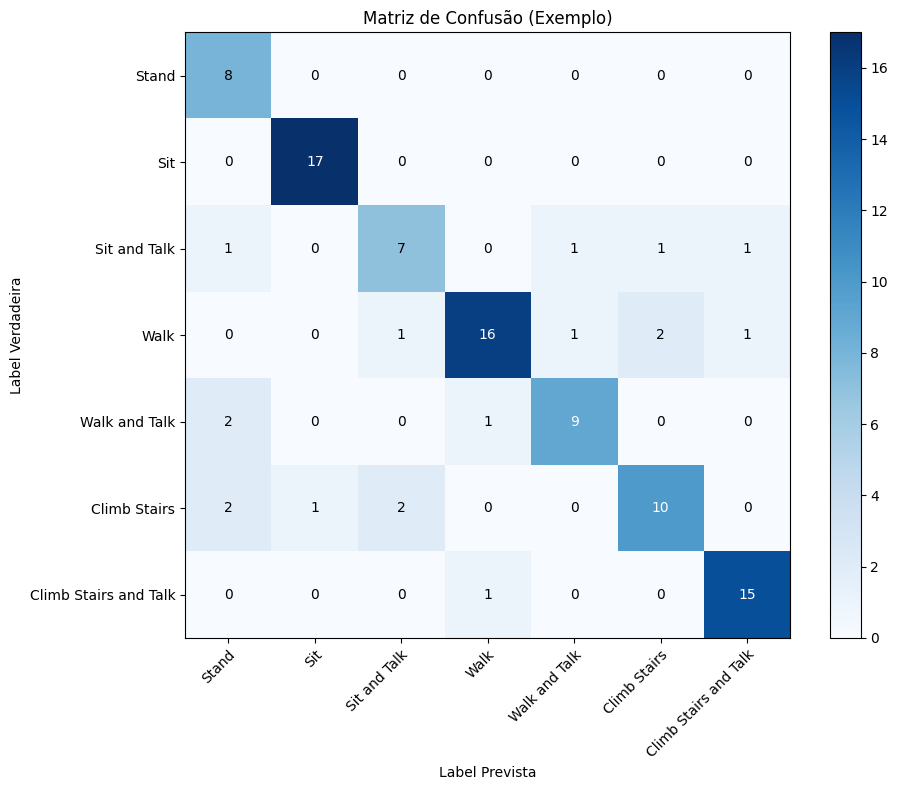


✓ Funções de métricas implementadas e testadas com sucesso!


In [ ]:
def compute_classification_metrics(y_true, y_pred, class_names=None, display=True):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Classes únicas
    classes = np.unique(np.concatenate([y_true, y_pred]))
    n_classes = len(classes)
    
    # Matriz de confusão
    conf_matrix = confusion_matrix(y_true, y_pred, labels=classes)
    
    # Métricas globais
    accuracy = accuracy_score(y_true, y_pred)
    
    # Métricas por classe e médias
    precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    precision_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    
    recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    recall_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    # Métricas por classe
    precision_per_class = precision_score(y_true, y_pred, average=None, labels=classes, zero_division=0)
    recall_per_class = recall_score(y_true, y_pred, average=None, labels=classes, zero_division=0)
    f1_per_class = f1_score(y_true, y_pred, average=None, labels=classes, zero_division=0)
    
    # Suporte (número de amostras por classe)
    support_per_class = np.array([np.sum(y_true == c) for c in classes])
    
    # Construir dicionário de métricas
    metrics = {
        'accuracy': accuracy,
        'precision_macro': precision_macro,
        'precision_weighted': precision_weighted,
        'recall_macro': recall_macro,
        'recall_weighted': recall_weighted,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'confusion_matrix': conf_matrix,
        'classes': classes,
        'precision_per_class': precision_per_class,
        'recall_per_class': recall_per_class,
        'f1_per_class': f1_per_class,
        'support_per_class': support_per_class
    }
    
    if display:
        print(f"\n{'='*60}")
        print("MÉTRICAS DE CLASSIFICAÇÃO")
        print(f"{'='*60}")
        
        # Métricas globais
        print(f"\n--- Métricas Globais ---")
        print(f"Accuracy:           {accuracy:.4f} ({accuracy*100:.2f}%)")
        print(f"Precision (macro):  {precision_macro:.4f}")
        print(f"Precision (weighted): {precision_weighted:.4f}")
        print(f"Recall (macro):     {recall_macro:.4f}")
        print(f"Recall (weighted):  {recall_weighted:.4f}")
        print(f"F1-Score (macro):   {f1_macro:.4f}")
        print(f"F1-Score (weighted): {f1_weighted:.4f}")
        
        # Métricas por classe
        print(f"\n--- Métricas por Classe ---")
        
        # Preparar nomes das classes
        if class_names is None:
            class_labels = [f"Classe {int(c)}" for c in classes]
        elif isinstance(class_names, dict):
            class_labels = [class_names.get(int(c), f"Classe {int(c)}") for c in classes]
        else:
            class_labels = list(class_names)
        
        print(f"{'Classe':<25} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10} | {'Suporte':<10}")
        print("-" * 75)
        
        for i, (cls, label) in enumerate(zip(classes, class_labels)):
            print(f"{label:<25} | {precision_per_class[i]:<10.4f} | {recall_per_class[i]:<10.4f} | {f1_per_class[i]:<10.4f} | {support_per_class[i]:<10}")
        
        print("-" * 75)
        print(f"{'Macro Avg':<25} | {precision_macro:<10.4f} | {recall_macro:<10.4f} | {f1_macro:<10.4f} | {np.sum(support_per_class):<10}")
        print(f"{'Weighted Avg':<25} | {precision_weighted:<10.4f} | {recall_weighted:<10.4f} | {f1_weighted:<10.4f} | {np.sum(support_per_class):<10}")
    
    return metrics


def plot_confusion_matrix(metrics, class_names=None, title="Matriz de Confusão", figsize=(10, 8)):
  
    conf_matrix = metrics['confusion_matrix']
    classes = metrics['classes']
    
    # Preparar labels
    if class_names is None:
        labels = [f"Classe {int(c)}" for c in classes]
    elif isinstance(class_names, dict):
        labels = [class_names.get(int(c), f"Classe {int(c)}") for c in classes]
    else:
        labels = list(class_names)
    
    # Criar figura
    fig, ax = plt.subplots(figsize=figsize)
    
    # Heatmap
    im = ax.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)
    
    # Configurar eixos
    ax.set(xticks=np.arange(conf_matrix.shape[1]),
           yticks=np.arange(conf_matrix.shape[0]),
           xticklabels=labels, yticklabels=labels,
           title=title,
           ylabel='Label Verdadeira',
           xlabel='Label Prevista')
    
    # Rotacionar labels do eixo x
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    # Adicionar valores nas células
    thresh = conf_matrix.max() / 2.
    for i in range(conf_matrix.shape[0]):
        for j in range(conf_matrix.shape[1]):
            ax.text(j, i, format(conf_matrix[i, j], 'd'),
                   ha="center", va="center",
                   color="white" if conf_matrix[i, j] > thresh else "black")
    
    fig.tight_layout()
    plt.show()
    
    return fig


def compare_metrics(metrics_list, names_list, metric_keys=['accuracy', 'f1_weighted', 'precision_weighted', 'recall_weighted']):

    print(f"\n{'='*70}")
    print("COMPARAÇÃO DE MÉTRICAS")
    print(f"{'='*70}")
    
    # Header
    header = f"{'Modelo/Cenário':<30}"
    for key in metric_keys:
        header += f" | {key:<15}"
    print(header)
    print("-" * len(header))
    
    # Dados
    for name, metrics in zip(names_list, metrics_list):
        row = f"{name:<30}"
        for key in metric_keys:
            value = metrics.get(key, 0)
            row += f" | {value:<15.4f}"
        print(row)


# Teste da função de métricas
print(f"\n{'='*60}")
print("4.2 - Teste da Função de Métricas")
print(f"{'='*60}")

# Nomes das atividades
activity_names_dict = {
    1: "Stand",
    2: "Sit", 
    3: "Sit and Talk",
    4: "Walk",
    5: "Walk and Talk",
    6: "Climb Stairs",
    7: "Climb Stairs and Talk"
}

# Criar dados de teste
np.random.seed(42)
y_true_test = np.random.randint(1, 8, 100)
y_pred_test = y_true_test.copy()
# Introduzir alguns erros
error_idx = np.random.choice(100, 20, replace=False)
y_pred_test[error_idx] = np.random.randint(1, 8, 20)

# Testar função
metrics_test = compute_classification_metrics(y_true_test, y_pred_test, class_names=activity_names_dict, display=True)

# Visualizar matriz de confusão
plot_confusion_matrix(metrics_test, class_names=activity_names_dict, title="Matriz de Confusão (Exemplo)")

print("\n✓ Funções de métricas implementadas e testadas com sucesso!")

### 5. Evaluation

Para cada estratégia de splitting (within-subject e between-subjects), aplicada às 3 versões (todas as features, PCA, ReliefF) dos 2 datasets (features, embeddings), vamos:
- Treinar o classificador k-NN
- Avaliar os resultados utilizando as métricas implementadas
- Comparar performance entre cenários

#### 5.1 Hyperparameter Tuning

Seleção do melhor valor de k usando apenas os dados de treino e validação. Depois, com o melhor k, retreinamos com (train + validation) e avaliamos no conjunto de teste.

In [ ]:
def hyperparameter_tuning_knn(X_train, y_train, X_val, y_val, k_values=range(1, 31, 2)):

    results = {}
    
    for k in k_values:
        # Treinar k-NN
        knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1)
        knn.fit(X_train, y_train)
        
        # Avaliar na validação
        y_pred = knn.predict(X_val)
        
        # Calcular métricas
        acc = accuracy_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred, average='weighted', zero_division=0)
        
        results[k] = {
            'accuracy': acc,
            'f1_weighted': f1
        }
    
    # Encontrar melhor k (baseado em F1-weighted)
    best_k = max(results.keys(), key=lambda k: results[k]['f1_weighted'])
    
    return best_k, results


def train_and_evaluate_scenario(scenario_data, k_values=range(1, 31, 2)):
 
    results = {}
    
    # Mapear nomes para versões mais curtas
    version_name_map = {
        'all_features': 'all_features',
        'pca_reduced': 'pca',
        'relieff_selected': 'relieff'
    }
    
    for version_name, version_data in scenario_data.items():
        short_name = version_name_map.get(version_name, version_name)
        print(f"\n  Versão: {short_name}")
        print(f"  " + "-" * 40)
        
        # Extrair dados das estruturas corretas
        X_train = version_data['train']['data']
        y_train = version_data['train']['labels']
        X_val = version_data['val']['data']
        y_val = version_data['val']['labels']
        X_test = version_data['test']['data']
        y_test = version_data['test']['labels']
        
        # Hyperparameter tuning
        best_k, tuning_results = hyperparameter_tuning_knn(X_train, y_train, X_val, y_val, k_values)
        print(f"  Melhor k encontrado: {best_k}")
        print(f"  Val Accuracy com k={best_k}: {tuning_results[best_k]['accuracy']:.4f}")
        print(f"  Val F1-weighted com k={best_k}: {tuning_results[best_k]['f1_weighted']:.4f}")
        
        # Combinar train + val para retreino
        X_train_val = np.vstack([X_train, X_val])
        y_train_val = np.concatenate([y_train, y_val])
        
        # Retreinar com melhor k
        final_knn = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean', n_jobs=-1)
        final_knn.fit(X_train_val, y_train_val)
        
        # Avaliar no teste
        y_pred_test = final_knn.predict(X_test)
        
        # Calcular métricas finais
        test_metrics = compute_classification_metrics(y_test, y_pred_test, 
                                                      class_names=activity_names_dict, 
                                                      display=False)
        
        print(f"  Test Accuracy: {test_metrics['accuracy']:.4f}")
        print(f"  Test F1-weighted: {test_metrics['f1_weighted']:.4f}")
        
        results[short_name] = {
            'best_k': best_k,
            'tuning_results': tuning_results,
            'test_metrics': test_metrics,
            'y_test': y_test,
            'y_pred': y_pred_test
        }
    
    return results


def run_full_evaluation(all_transformed_data, k_values=range(1, 31, 2)):
 
    all_results = {}
    
    # Configurações a avaliar
    configurations = [
        ('FEATURES', 'Within-Subject', 'features_within'),
        ('FEATURES', 'Between-Subjects', 'features_between'),
        ('EMBEDDINGS', 'Within-Subject', 'embeddings_within'),
        ('EMBEDDINGS', 'Between-Subjects', 'embeddings_between')
    ]
    
    for dataset_name, split_name, data_key in configurations:
        config_key = f"{dataset_name}_{split_name.replace('-', '_')}"
        print(f"\n{'='*60}")
        print(f"Dataset: {dataset_name} | Splitting: {split_name}")
        print(f"{'='*60}")
        
        scenario_data = all_transformed_data[data_key]
        results = train_and_evaluate_scenario(scenario_data, k_values)
        all_results[config_key] = results
    
    return all_results


# Definir valores de k a testar
k_values = list(range(1, 31, 2))  # 1, 3, 5, ..., 29

print(f"\n{'='*60}")
print("5.1 - HYPERPARAMETER TUNING")
print(f"{'='*60}")
print(f"Valores de k a testar: {list(k_values)}")

# Executar avaliação completa
all_results = run_full_evaluation(all_transformed_data, k_values)

print(f"\n{'='*60}")
print("✓ Hyperparameter tuning concluído para todos os cenários!")
print(f"{'='*60}")


5.1 - HYPERPARAMETER TUNING
Valores de k a testar: [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29]

Dataset: FEATURES | Splitting: Within-Subject

  Versão: all_features
  ----------------------------------------
  Melhor k encontrado: 1
  Val Accuracy com k=1: 0.7920
  Val F1-weighted com k=1: 0.7913
  Test Accuracy: 0.8161
  Test F1-weighted: 0.8146

  Versão: pca
  ----------------------------------------
  Melhor k encontrado: 1
  Val Accuracy com k=1: 0.7562
  Val F1-weighted com k=1: 0.7557
  Test Accuracy: 0.7900
  Test F1-weighted: 0.7882

  Versão: relieff
  ----------------------------------------
  Melhor k encontrado: 1
  Val Accuracy com k=1: 0.7869
  Val F1-weighted com k=1: 0.7860
  Test Accuracy: 0.7982
  Test F1-weighted: 0.7972

Dataset: FEATURES | Splitting: Between-Subjects

  Versão: all_features
  ----------------------------------------
  Melhor k encontrado: 3
  Val Accuracy com k=3: 0.6007
  Val F1-weighted com k=3: 0.5931
  Test Accuracy: 0.5896
  Tes

#### 5.2 Análise de Resultados e Matrizes de Confusão

Visualização detalhada dos resultados, incluindo matrizes de confusão para identificar quais atividades são mais difíceis de classificar.


5.2 - ANÁLISE DE RESULTADOS

TABELA RESUMO DE RESULTADOS

Configuração                             | Versão          | Melhor k   | Accuracy   | F1-weighted  | Precision  | Recall    
-------------------------------------------------------------------------------------------------------------------
FEATURES_Within_Subject                  | all_features    | 1          | 0.8161     | 0.8146       | 0.8147     | 0.8161    
FEATURES_Within_Subject                  | pca             | 1          | 0.7900     | 0.7882       | 0.7881     | 0.7900    
FEATURES_Within_Subject                  | relieff         | 1          | 0.7982     | 0.7972       | 0.7972     | 0.7982    
FEATURES_Between_Subjects                | all_features    | 3          | 0.5896     | 0.5773       | 0.5812     | 0.5896    
FEATURES_Between_Subjects                | pca             | 3          | 0.5877     | 0.5763       | 0.5805     | 0.5877    
FEATURES_Between_Subjects                | relieff         | 29      

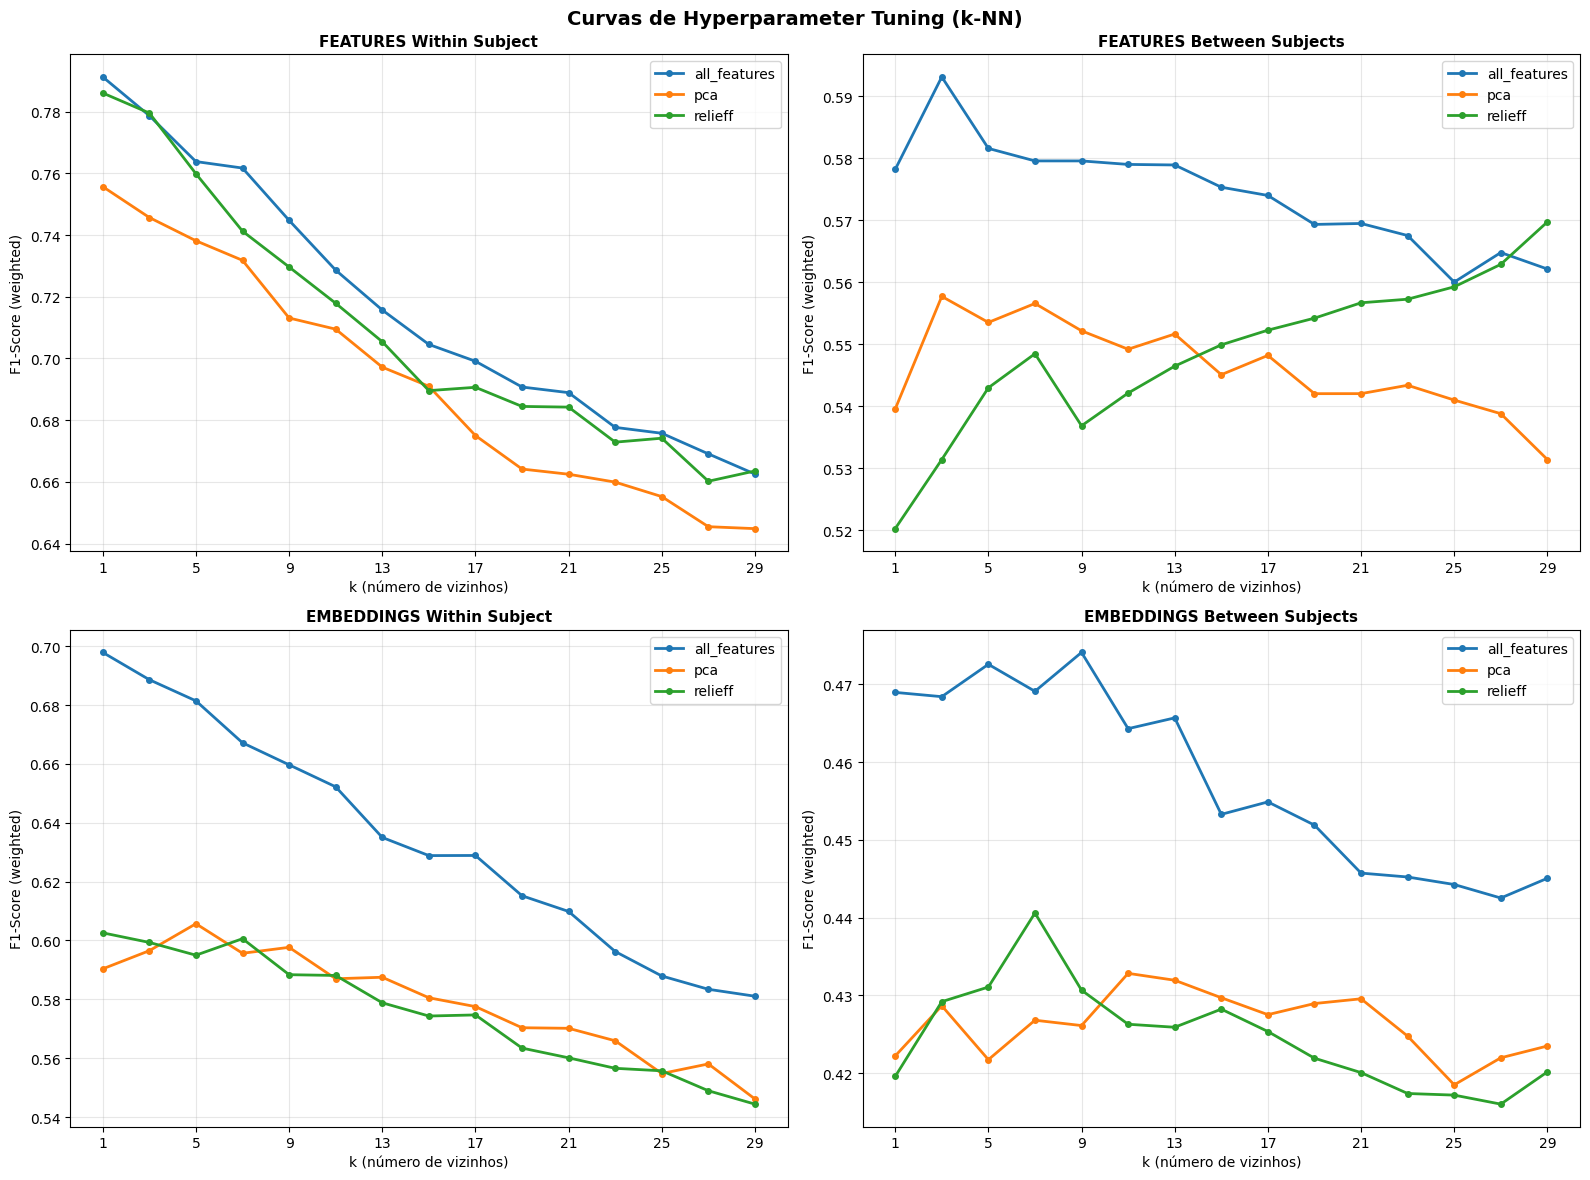


--- Matrizes de Confusão ---


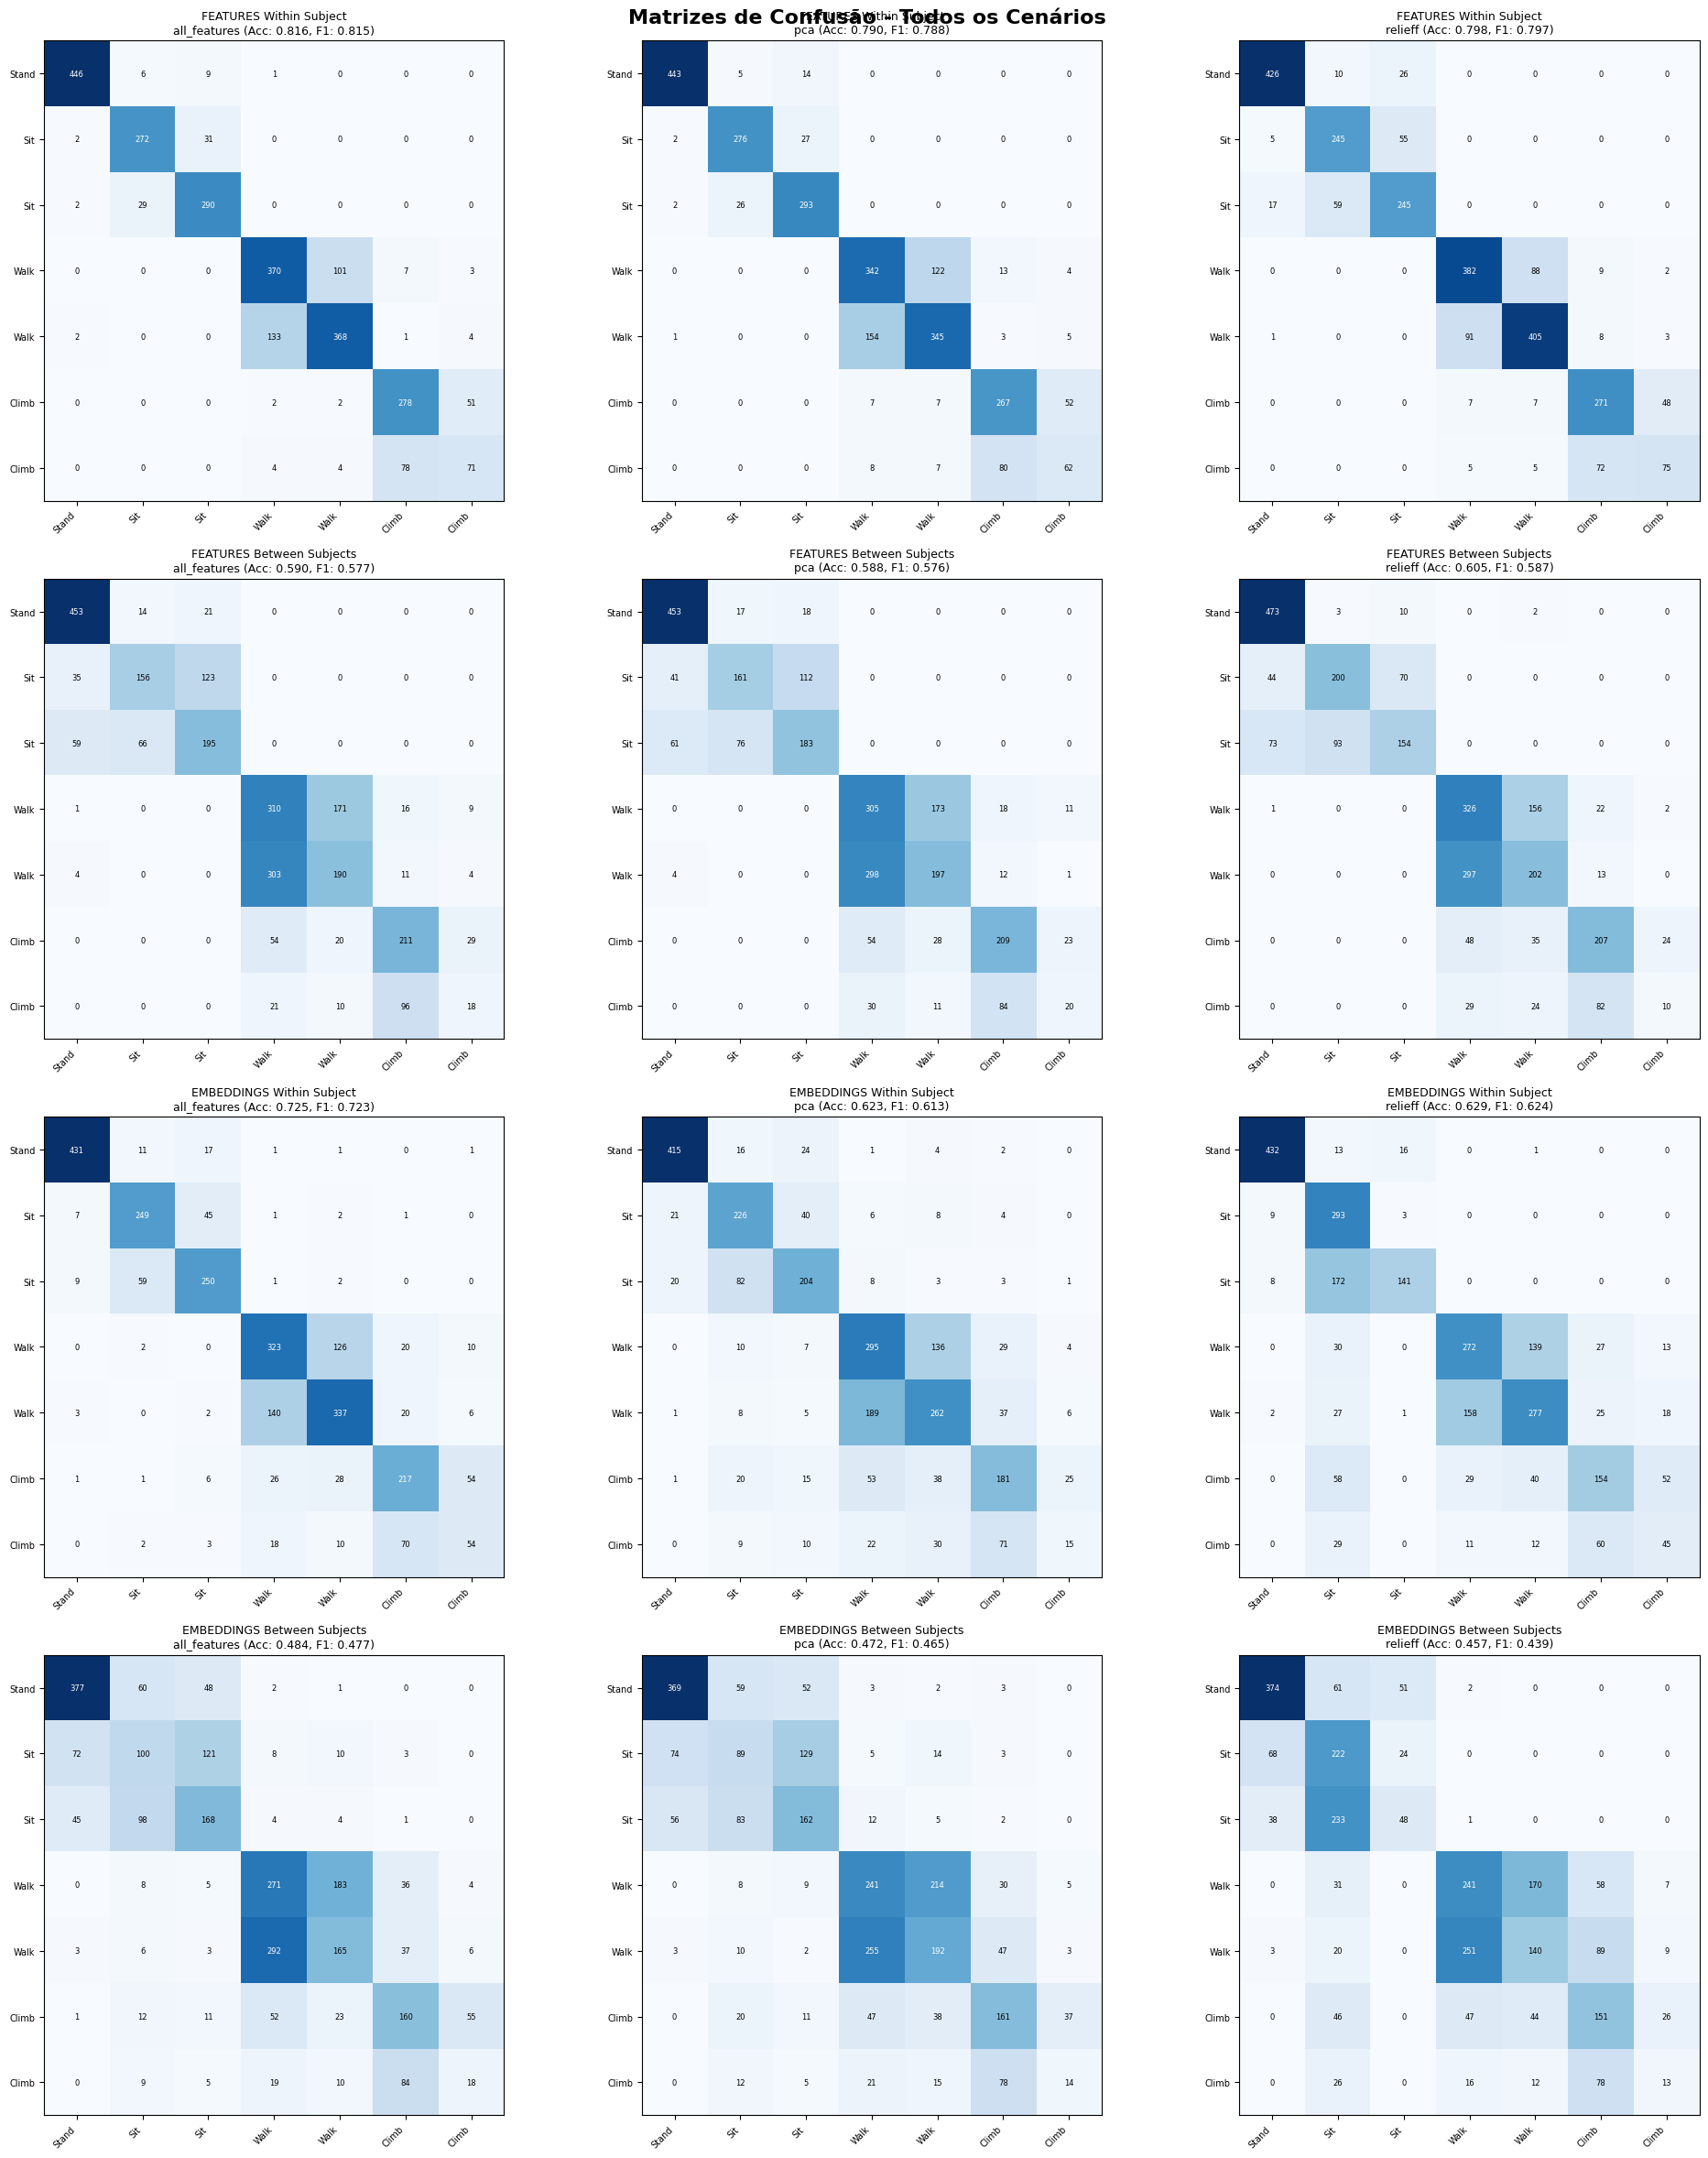


ANÁLISE DE ATIVIDADES DIFÍCEIS DE CLASSIFICAR

Atividade                 | Recall Médio    | Desvio Padrão   | Min        | Max       
--------------------------------------------------------------------------------
Stand                     | 0.8945          | 0.0771          | 0.7561     | 0.9693    
Sit                       | 0.6728          | 0.2166          | 0.2834     | 0.9607    
Sit and Talk              | 0.6064          | 0.2056          | 0.1500     | 0.9128    
Walk                      | 0.6222          | 0.0986          | 0.4753     | 0.7942    
Walk and Talk             | 0.5039          | 0.1681          | 0.2734     | 0.7972    
Climb Stairs              | 0.6340          | 0.1276          | 0.4625     | 0.8348    
Climb Stairs and Talk     | 0.2244          | 0.1489          | 0.0690     | 0.4777    

--- Atividades mais difíceis (ordenadas por recall médio) ---
1. Climb Stairs and Talk: Recall médio = 0.2244
2. Walk and Talk: Recall médio = 0.5039
3. Sit and Talk:

In [ ]:
def create_summary_table(all_results):
    
    print(f"\n{'='*100}")
    print("TABELA RESUMO DE RESULTADOS")
    print(f"{'='*100}")
    
    # Header
    print(f"\n{'Configuração':<40} | {'Versão':<15} | {'Melhor k':<10} | {'Accuracy':<10} | {'F1-weighted':<12} | {'Precision':<10} | {'Recall':<10}")
    print("-" * 115)
    
    summary_data = []
    
    for config_key, config_results in all_results.items():
        for version_name, version_results in config_results.items():
            metrics = version_results['test_metrics']
            row = {
                'config': config_key,
                'version': version_name,
                'best_k': version_results['best_k'],
                'accuracy': metrics['accuracy'],
                'f1_weighted': metrics['f1_weighted'],
                'precision_weighted': metrics['precision_weighted'],
                'recall_weighted': metrics['recall_weighted']
            }
            summary_data.append(row)
            
            print(f"{config_key:<40} | {version_name:<15} | {version_results['best_k']:<10} | "
                  f"{metrics['accuracy']:<10.4f} | {metrics['f1_weighted']:<12.4f} | "
                  f"{metrics['precision_weighted']:<10.4f} | {metrics['recall_weighted']:<10.4f}")
    
    print("-" * 115)
    
    return summary_data


def plot_tuning_curves(all_results, figsize=(16, 12)):
    """
    Visualiza as curvas de tuning de k para todos os cenários.
    """
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()
    
    config_keys = list(all_results.keys())
    
    for idx, config_key in enumerate(config_keys):
        ax = axes[idx]
        config_results = all_results[config_key]
        
        for version_name, version_results in config_results.items():
            tuning = version_results['tuning_results']
            ks = list(tuning.keys())
            f1_scores = [tuning[k]['f1_weighted'] for k in ks]
            
            ax.plot(ks, f1_scores, marker='o', label=version_name, linewidth=2, markersize=4)
        
        ax.set_xlabel('k (número de vizinhos)', fontsize=10)
        ax.set_ylabel('F1-Score (weighted)', fontsize=10)
        ax.set_title(config_key.replace('_', ' '), fontsize=11, fontweight='bold')
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(ks[::2])  # Mostrar apenas alguns valores de k
    
    plt.suptitle('Curvas de Hyperparameter Tuning (k-NN)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return fig


def plot_all_confusion_matrices(all_results, activity_names_dict, figsize=(20, 24)):
    """
    Visualiza todas as matrizes de confusão.
    """
    # 4 configs × 3 versões = 12 subplots
    fig, axes = plt.subplots(4, 3, figsize=figsize)
    
    config_keys = list(all_results.keys())
    version_names = ['all_features', 'pca', 'relieff']
    
    for row_idx, config_key in enumerate(config_keys):
        for col_idx, version_name in enumerate(version_names):
            ax = axes[row_idx, col_idx]
            
            if version_name in all_results[config_key]:
                version_results = all_results[config_key][version_name]
                metrics = version_results['test_metrics']
                conf_matrix = metrics['confusion_matrix']
                classes = metrics['classes']
                
                # Labels das classes
                labels = [activity_names_dict.get(int(c), f"Classe {c}") for c in classes]
                labels_short = [l.split()[0] if len(l) > 10 else l for l in labels]  # Abreviar
                
                # Heatmap
                im = ax.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
                
                # Configurar eixos
                ax.set_xticks(np.arange(len(labels_short)))
                ax.set_yticks(np.arange(len(labels_short)))
                ax.set_xticklabels(labels_short, rotation=45, ha='right', fontsize=7)
                ax.set_yticklabels(labels_short, fontsize=7)
                
                # Título
                acc = metrics['accuracy']
                f1 = metrics['f1_weighted']
                ax.set_title(f"{config_key.replace('_', ' ')}\n{version_name} (Acc: {acc:.3f}, F1: {f1:.3f})", 
                            fontsize=9)
                
                # Adicionar valores
                thresh = conf_matrix.max() / 2.
                for i in range(conf_matrix.shape[0]):
                    for j in range(conf_matrix.shape[1]):
                        ax.text(j, i, format(conf_matrix[i, j], 'd'),
                               ha="center", va="center", fontsize=6,
                               color="white" if conf_matrix[i, j] > thresh else "black")
            else:
                ax.set_visible(False)
    
    plt.suptitle('Matrizes de Confusão - Todos os Cenários', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return fig


def analyze_difficult_activities(all_results, activity_names_dict):
    """
    Analisa quais atividades são mais difíceis de classificar.
    """
    print(f"\n{'='*80}")
    print("ANÁLISE DE ATIVIDADES DIFÍCEIS DE CLASSIFICAR")
    print(f"{'='*80}")
    
    # Agregar recall por atividade em todos os cenários
    activity_recalls = {i: [] for i in range(1, 8)}
    
    for config_key, config_results in all_results.items():
        for version_name, version_results in config_results.items():
            metrics = version_results['test_metrics']
            classes = metrics['classes']
            recalls = metrics['recall_per_class']
            
            for cls, recall in zip(classes, recalls):
                activity_recalls[int(cls)].append(recall)
    
    # Calcular média e desvio padrão
    print(f"\n{'Atividade':<25} | {'Recall Médio':<15} | {'Desvio Padrão':<15} | {'Min':<10} | {'Max':<10}")
    print("-" * 80)
    
    activity_stats = []
    for act in range(1, 8):
        if activity_recalls[act]:
            recalls = activity_recalls[act]
            mean_recall = np.mean(recalls)
            std_recall = np.std(recalls)
            min_recall = np.min(recalls)
            max_recall = np.max(recalls)
            
            activity_stats.append({
                'activity': act,
                'name': activity_names_dict[act],
                'mean_recall': mean_recall,
                'std_recall': std_recall
            })
            
            print(f"{activity_names_dict[act]:<25} | {mean_recall:<15.4f} | {std_recall:<15.4f} | {min_recall:<10.4f} | {max_recall:<10.4f}")
    
    # Identificar as mais difíceis
    sorted_activities = sorted(activity_stats, key=lambda x: x['mean_recall'])
    
    print(f"\n--- Atividades mais difíceis (ordenadas por recall médio) ---")
    for i, act_stat in enumerate(sorted_activities[:3], 1):
        print(f"{i}. {act_stat['name']}: Recall médio = {act_stat['mean_recall']:.4f}")
    
    return activity_stats


def compare_datasets_and_features(all_results):
    """
    Compara performance entre datasets e tipos de features.
    """
    print(f"\n{'='*80}")
    print("COMPARAÇÃO: FEATURES vs EMBEDDINGS")
    print(f"{'='*80}")
    
    features_scores = []
    embeddings_scores = []
    
    for config_key, config_results in all_results.items():
        for version_name, version_results in config_results.items():
            f1 = version_results['test_metrics']['f1_weighted']
            
            if 'FEATURES' in config_key:
                features_scores.append(f1)
            else:
                embeddings_scores.append(f1)
    
    print(f"\nFEATURES Dataset:")
    print(f"  F1-weighted médio: {np.mean(features_scores):.4f} ± {np.std(features_scores):.4f}")
    print(f"  Intervalo: [{np.min(features_scores):.4f}, {np.max(features_scores):.4f}]")
    
    print(f"\nEMBEDDINGS Dataset:")
    print(f"  F1-weighted médio: {np.mean(embeddings_scores):.4f} ± {np.std(embeddings_scores):.4f}")
    print(f"  Intervalo: [{np.min(embeddings_scores):.4f}, {np.max(embeddings_scores):.4f}]")
    
    # Comparar versões de features
    print(f"\n{'='*80}")
    print("COMPARAÇÃO: ALL FEATURES vs PCA vs RELIEFF")
    print(f"{'='*80}")
    
    version_scores = {'all_features': [], 'pca': [], 'relieff': []}
    
    for config_key, config_results in all_results.items():
        for version_name, version_results in config_results.items():
            f1 = version_results['test_metrics']['f1_weighted']
            version_scores[version_name].append(f1)
    
    for version_name in ['all_features', 'pca', 'relieff']:
        scores = version_scores[version_name]
        print(f"\n{version_name.upper()}:")
        print(f"  F1-weighted médio: {np.mean(scores):.4f} ± {np.std(scores):.4f}")
        print(f"  Intervalo: [{np.min(scores):.4f}, {np.max(scores):.4f}]")
    
    # Comparar estratégias de splitting
    print(f"\n{'='*80}")
    print("COMPARAÇÃO: WITHIN-SUBJECT vs BETWEEN-SUBJECTS")
    print(f"{'='*80}")
    
    within_scores = []
    between_scores = []
    
    for config_key, config_results in all_results.items():
        for version_name, version_results in config_results.items():
            f1 = version_results['test_metrics']['f1_weighted']
            
            if 'Within' in config_key:
                within_scores.append(f1)
            else:
                between_scores.append(f1)
    
    print(f"\nWITHIN-SUBJECT Split:")
    print(f"  F1-weighted médio: {np.mean(within_scores):.4f} ± {np.std(within_scores):.4f}")
    
    print(f"\nBETWEEN-SUBJECTS Split:")
    print(f"  F1-weighted médio: {np.mean(between_scores):.4f} ± {np.std(between_scores):.4f}")
    
    return {
        'features_mean': np.mean(features_scores),
        'embeddings_mean': np.mean(embeddings_scores),
        'within_mean': np.mean(within_scores),
        'between_mean': np.mean(between_scores)
    }


# Executar análises
print(f"\n{'='*60}")
print("5.2 - ANÁLISE DE RESULTADOS")
print(f"{'='*60}")

# Tabela resumo
summary_data = create_summary_table(all_results)

# Curvas de tuning
print("\n--- Curvas de Hyperparameter Tuning ---")
plot_tuning_curves(all_results)

# Matrizes de confusão
print("\n--- Matrizes de Confusão ---")
plot_all_confusion_matrices(all_results, activity_names_dict)

# Análise de atividades difíceis
activity_stats = analyze_difficult_activities(all_results, activity_names_dict)

# Comparações
comparison_stats = compare_datasets_and_features(all_results)

#### 5.3 Testes de Hipóteses Estatísticos

Para comparar estatisticamente os modelos, realizamos múltiplas divisões train-validation-test para obter distribuições de performance. Depois, aplicamos testes estatísticos apropriados:

- **Teste de Shapiro-Wilk**: Para verificar normalidade das distribuições
- **Teste t pareado** (se normalidade) ou **Teste de Wilcoxon** (caso contrário): Para comparações par-a-par
- **ANOVA** (se normalidade) ou **Teste de Friedman** (caso contrário): Para comparações múltiplas
- **Correção de Bonferroni**: Para controlar a taxa de erro tipo I em comparações múltiplas


5.3 - TESTES DE HIPÓTESES ESTATÍSTICOS

Para obter distribuições de performance, vamos repetir o processo
de train-validation-test split várias vezes com diferentes seeds.

Executando 10 iterações de train-val-test split...
Isto pode demorar alguns minutos...

  Fitting StandardScaler no treino...
  Fitting PCA no treino...
    → PCA: 33 componentes explicam 90% da variância
  Fitting ReliefF no treino...
    → ReliefF: Top 15 índices selecionados
  Fitting StandardScaler no treino...
  Fitting PCA no treino...
    → PCA: 32 componentes explicam 90% da variância
  Fitting ReliefF no treino...
    → ReliefF: Top 15 índices selecionados
  Fitting StandardScaler no treino...
  Fitting PCA no treino...
    → PCA: 9 componentes explicam 90% da variância
  Fitting ReliefF no treino...
    → ReliefF: Top 15 índices selecionados
  Fitting StandardScaler no treino...
  Fitting PCA no treino...
    → PCA: 10 componentes explicam 90% da variância
  Fitting ReliefF no treino...
    → ReliefF: Top

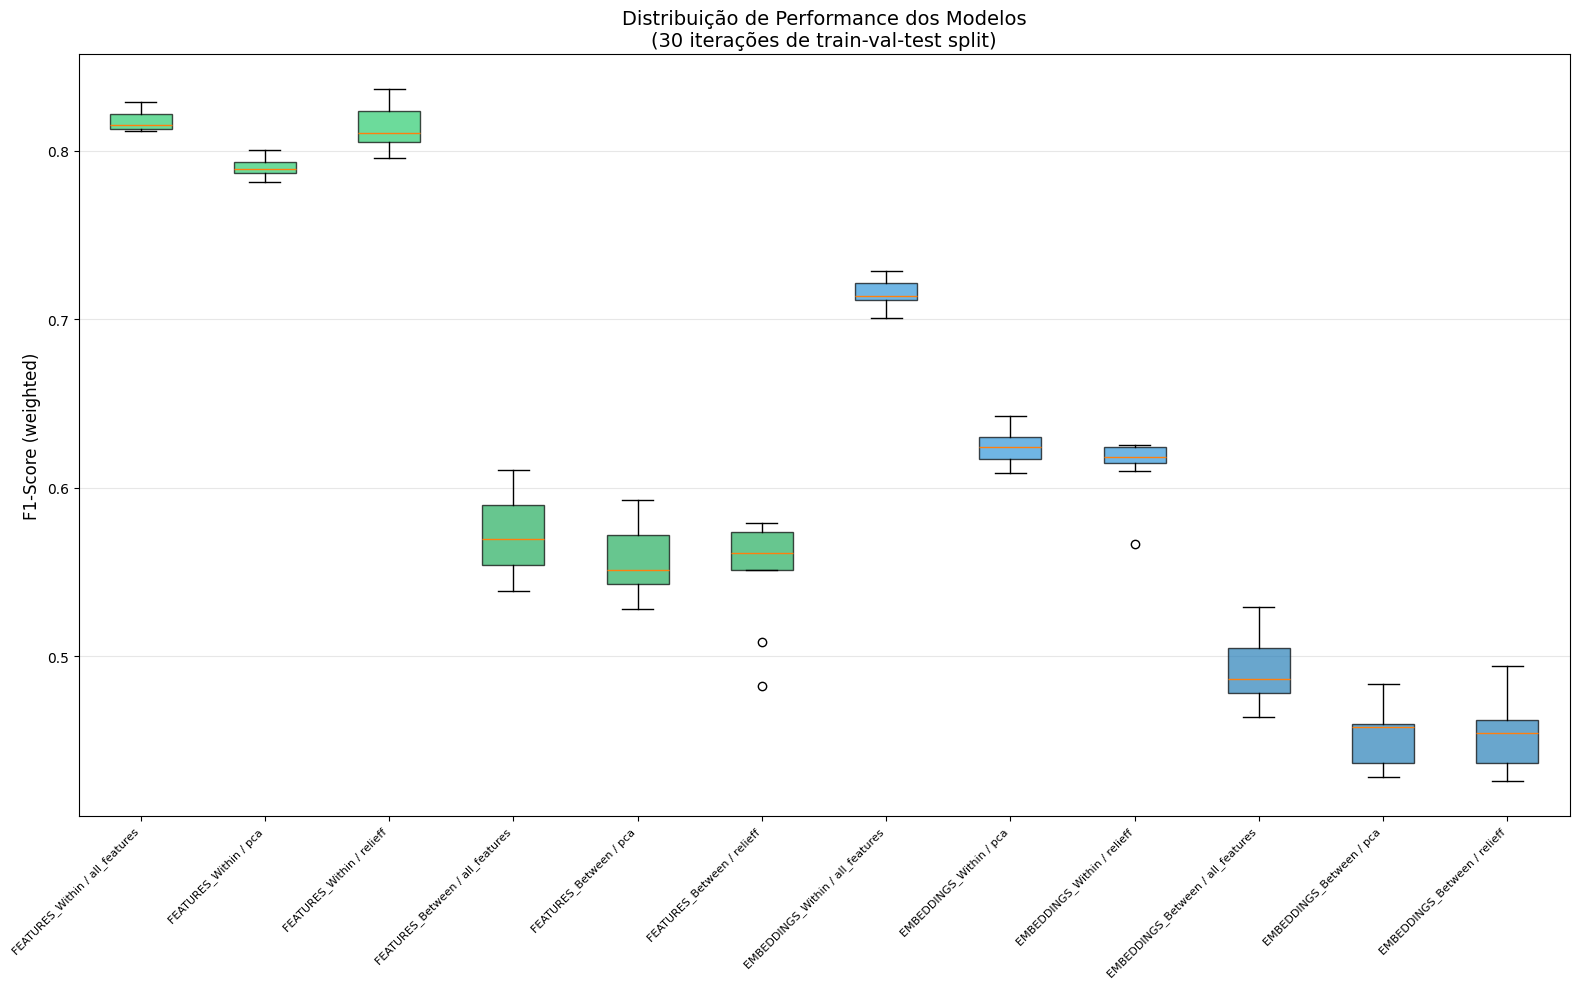


TESTE DE NORMALIDADE (Shapiro-Wilk)
H0: A distribuição é normal (p > 0.05)
H1: A distribuição não é normal (p <= 0.05)


FEATURES_Within:
  all_features   : W=0.8863, p=0.1540 → ✓ Normal
  pca            : W=0.9621, p=0.8098 → ✓ Normal
  relieff        : W=0.8954, p=0.1948 → ✓ Normal

FEATURES_Between:
  all_features   : W=0.9396, p=0.5482 → ✓ Normal
  pca            : W=0.9201, p=0.3579 → ✓ Normal
  relieff        : W=0.8007, p=0.0148 → ✗ Não Normal

EMBEDDINGS_Within:
  all_features   : W=0.9576, p=0.7580 → ✓ Normal
  pca            : W=0.9654, p=0.8452 → ✓ Normal
  relieff        : W=0.6303, p=0.0001 → ✗ Não Normal

EMBEDDINGS_Between:
  all_features   : W=0.9448, p=0.6078 → ✓ Normal
  pca            : W=0.9168, p=0.3313 → ✓ Normal
  relieff        : W=0.9453, p=0.6138 → ✓ Normal

TESTE DE FRIEDMAN (Comparações Múltiplas)
H0: Todos os modelos têm a mesma performance
H1: Pelo menos um modelo é diferente

Estatística de Friedman: 106.5077
p-value: 0.000000

→ Resultado: Rejeitamos H0

In [37]:
from scipy import stats

def run_multiple_splits_evaluation(features_data, features_labels, features_participant_ids,
                                   embeddings_data, embeddings_labels, embeddings_participant_ids,
                                   n_iterations=10, k_values=range(1, 21, 2), random_seed=42):
    np.random.seed(random_seed)
    
    performance_distributions = {}
    
    # Inicializar estrutura
    configs = ['FEATURES_Within', 'FEATURES_Between', 'EMBEDDINGS_Within', 'EMBEDDINGS_Between']
    versions = ['all_features', 'pca', 'relieff']
    
    for config in configs:
        performance_distributions[config] = {}
        for version in versions:
            performance_distributions[config][version] = []
    
    print(f"Executando {n_iterations} iterações de train-val-test split...")
    print("Isto pode demorar alguns minutos...\n")
    
    for iteration in range(n_iterations):
        if (iteration + 1) % 5 == 0:
            print(f"  Iteração {iteration + 1}/{n_iterations}")
        
        # Gerar seeds diferentes para cada iteração
        iter_seed = random_seed + iteration
        
        # --- FEATURES DATASET ---
        
        # Within-Subject Split
        feat_within = within_subject_split(features_data, features_labels, features_participant_ids,
                                           train_ratio=0.6, val_ratio=0.2, random_state=iter_seed)
        
        # Between-Subjects Split
        np.random.seed(iter_seed)
        unique_participants = np.unique(features_participant_ids)
        shuffled_p = np.random.permutation(unique_participants)
        train_p = shuffled_p[:9]
        val_p = shuffled_p[9:12]
        test_p = shuffled_p[12:15]
        
        feat_between, _ = between_subjects_split(features_data, features_labels, features_participant_ids,
                                                  n_train=9, n_val=3, n_test=3, random_state=iter_seed)
        
        # --- EMBEDDINGS DATASET ---
        
        # Within-Subject Split
        emb_within = within_subject_split(embeddings_data, embeddings_labels, embeddings_participant_ids,
                                          train_ratio=0.6, val_ratio=0.2, random_state=iter_seed)
        
        # Between-Subjects Split
        emb_between, _ = between_subjects_split(embeddings_data, embeddings_labels, embeddings_participant_ids,
                                                 n_train=9, n_val=3, n_test=3, random_state=iter_seed)
        
        # Avaliar cada configuração
        split_configs = [
            ('FEATURES_Within', feat_within),
            ('FEATURES_Between', feat_between),
            ('EMBEDDINGS_Within', emb_within),
            ('EMBEDDINGS_Between', emb_between)
        ]
        
        for config_name, split_data in split_configs:
            # Extrair dados de treino, val, test
            X_train = split_data['train']['data']
            y_train = split_data['train']['labels']
            X_val = split_data['val']['data']
            y_val = split_data['val']['labels']
            X_test = split_data['test']['data']
            y_test = split_data['test']['labels']
            
            # Aplicar transformações usando o pipeline
            pipeline = FeatureTransformationPipeline(
                pca_variance=0.90,
                relieff_n_features=15,
                relieff_n_neighbors=10
            )
            pipeline.fit(X_train, y_train)
            
            # Três cenários de features
            scenarios = {
                'all_features': {
                    'X_train': pipeline.transform_all(X_train),
                    'X_val': pipeline.transform_all(X_val),
                    'X_test': pipeline.transform_all(X_test)
                },
                'pca': {
                    'X_train': pipeline.transform_pca(X_train),
                    'X_val': pipeline.transform_pca(X_val),
                    'X_test': pipeline.transform_pca(X_test)
                },
                'relieff': {
                    'X_train': pipeline.transform_relieff(X_train),
                    'X_val': pipeline.transform_relieff(X_val),
                    'X_test': pipeline.transform_relieff(X_test)
                }
            }
            
            for version_name, version_data in scenarios.items():
                # Hyperparameter tuning
                best_k, _ = hyperparameter_tuning_knn(
                    version_data['X_train'], y_train,
                    version_data['X_val'], y_val,
                    k_values
                )
                
                # Retreinar com train + val
                X_train_val = np.vstack([version_data['X_train'], version_data['X_val']])
                y_train_val = np.concatenate([y_train, y_val])
                
                final_knn = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean', n_jobs=-1)
                final_knn.fit(X_train_val, y_train_val)
                
                # Avaliar no teste
                y_pred = final_knn.predict(version_data['X_test'])
                f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
                
                performance_distributions[config_name][version_name].append(f1)
    
    return performance_distributions


def check_normality(distributions, alpha=0.05):
    """
    Verifica normalidade das distribuições usando teste de Shapiro-Wilk.
    """
    print(f"\n{'='*80}")
    print("TESTE DE NORMALIDADE (Shapiro-Wilk)")
    print(f"{'='*80}")
    print(f"H0: A distribuição é normal (p > {alpha})")
    print(f"H1: A distribuição não é normal (p <= {alpha})")
    print()
    
    normality_results = {}
    
    for config, versions in distributions.items():
        normality_results[config] = {}
        print(f"\n{config}:")
        
        for version, scores in versions.items():
            if len(scores) >= 3:  # Shapiro-Wilk precisa de pelo menos 3 amostras
                stat, p_value = stats.shapiro(scores)
                is_normal = p_value > alpha
                normality_results[config][version] = is_normal
                
                result = "✓ Normal" if is_normal else "✗ Não Normal"
                print(f"  {version:<15}: W={stat:.4f}, p={p_value:.4f} → {result}")
    
    return normality_results


def pairwise_comparisons(distributions, normality_results, alpha=0.05):
    """
    Realiza comparações par-a-par entre modelos.
    """
    print(f"\n{'='*80}")
    print("COMPARAÇÕES PAR-A-PAR")
    print(f"{'='*80}")
    
    # Flatten all configurations for comparison
    all_scores = {}
    for config, versions in distributions.items():
        for version, scores in versions.items():
            key = f"{config}_{version}"
            all_scores[key] = np.array(scores)
    
    model_names = list(all_scores.keys())
    n_models = len(model_names)
    
    # Encontrar o melhor modelo (maior média)
    means = {name: np.mean(scores) for name, scores in all_scores.items()}
    best_model = max(means, key=means.get)
    
    print(f"\nMelhor modelo (maior F1 médio): {best_model}")
    print(f"F1 médio: {means[best_model]:.4f}")
    
    # Comparar melhor modelo com todos os outros
    print(f"\n--- Comparação do melhor modelo com os demais ---")
    print(f"(Correção de Bonferroni aplicada: α' = {alpha}/{n_models-1} = {alpha/(n_models-1):.6f})")
    print()
    
    bonferroni_alpha = alpha / (n_models - 1)
    comparison_results = []
    
    for other_model in model_names:
        if other_model == best_model:
            continue
        
        scores_best = all_scores[best_model]
        scores_other = all_scores[other_model]
        
        # Verificar se ambos são normais
        config1, version1 = best_model.rsplit('_', 1)
        config2, version2 = other_model.rsplit('_', 1)
        
        # Usar teste não-paramétrico por segurança (Wilcoxon)
        # Como as amostras são pareadas (mesmas iterações), usamos Wilcoxon signed-rank
        try:
            stat, p_value = stats.wilcoxon(scores_best, scores_other, alternative='greater')
            test_name = "Wilcoxon (one-sided)"
        except:
            stat, p_value = stats.mannwhitneyu(scores_best, scores_other, alternative='greater')
            test_name = "Mann-Whitney U"
        
        is_significant = p_value < bonferroni_alpha
        result = "✓ Significativamente melhor" if is_significant else "✗ Diferença não significativa"
        
        print(f"{best_model} vs {other_model}:")
        print(f"  Teste: {test_name}")
        print(f"  Diferença média: {means[best_model] - means[other_model]:.4f}")
        print(f"  p-value: {p_value:.6f}")
        print(f"  Resultado: {result}")
        print()
        
        comparison_results.append({
            'model1': best_model,
            'model2': other_model,
            'p_value': p_value,
            'is_significant': is_significant,
            'diff': means[best_model] - means[other_model]
        })
    
    return comparison_results, best_model


def friedman_test(distributions, alpha=0.05):
    """
    Realiza o teste de Friedman para comparações múltiplas.
    """
    print(f"\n{'='*80}")
    print("TESTE DE FRIEDMAN (Comparações Múltiplas)")
    print(f"{'='*80}")
    print("H0: Todos os modelos têm a mesma performance")
    print("H1: Pelo menos um modelo é diferente")
    print()
    
    # Preparar dados para Friedman
    all_scores = {}
    for config, versions in distributions.items():
        for version, scores in versions.items():
            key = f"{config}_{version}"
            all_scores[key] = np.array(scores)
    
    # Criar matriz onde cada linha é uma iteração e cada coluna é um modelo
    model_names = list(all_scores.keys())
    n_iterations = len(list(all_scores.values())[0])
    
    data_matrix = np.column_stack([all_scores[name] for name in model_names])
    
    # Teste de Friedman
    stat, p_value = stats.friedmanchisquare(*[data_matrix[:, i] for i in range(len(model_names))])
    
    print(f"Estatística de Friedman: {stat:.4f}")
    print(f"p-value: {p_value:.6f}")
    
    if p_value < alpha:
        print(f"\n→ Resultado: Rejeitamos H0 (p < {alpha})")
        print("  Existe diferença significativa entre pelo menos dois modelos.")
    else:
        print(f"\n→ Resultado: Não rejeitamos H0 (p >= {alpha})")
        print("  Não há evidência suficiente de diferença entre os modelos.")
    
    return stat, p_value, model_names


def plot_performance_distributions(distributions, figsize=(16, 10)):
    """
    Visualiza as distribuições de performance.
    """
    # Preparar dados
    all_data = []
    labels = []
    
    for config, versions in distributions.items():
        for version, scores in versions.items():
            all_data.extend(scores)
            labels.extend([f"{config}\n{version}" for _ in scores])
    
    # Criar DataFrame para boxplot
    import pandas as pd
    df = pd.DataFrame({'F1-Score': all_data, 'Model': labels})
    
    # Agrupar por configuração para cores
    fig, ax = plt.subplots(figsize=figsize)
    
    unique_models = df['Model'].unique()
    positions = range(len(unique_models))
    
    # Cores por dataset
    colors = []
    for model in unique_models:
        if 'FEATURES' in model and 'Within' in model:
            colors.append('#2ecc71')  # Verde
        elif 'FEATURES' in model and 'Between' in model:
            colors.append('#27ae60')  # Verde escuro
        elif 'EMBEDDINGS' in model and 'Within' in model:
            colors.append('#3498db')  # Azul
        else:
            colors.append('#2980b9')  # Azul escuro
    
    bp = ax.boxplot([df[df['Model'] == m]['F1-Score'].values for m in unique_models],
                    positions=positions, patch_artist=True)
    
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_xticks(positions)
    ax.set_xticklabels([m.replace('\n', ' / ') for m in unique_models], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('F1-Score (weighted)', fontsize=12)
    ax.set_title('Distribuição de Performance dos Modelos\n(30 iterações de train-val-test split)', fontsize=14)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    return fig


# Executar análise com múltiplas divisões
print(f"\n{'='*60}")
print("5.3 - TESTES DE HIPÓTESES ESTATÍSTICOS")
print(f"{'='*60}")
print("\nPara obter distribuições de performance, vamos repetir o processo")
print("de train-validation-test split várias vezes com diferentes seeds.")
print()

# Executar múltiplas iterações
performance_distributions = run_multiple_splits_evaluation(
    features_data, features_labels, features_participant_ids,
    embeddings_data, embeddings_labels, embeddings_participant_ids,
    n_iterations=10,  # 10 repetições
    k_values=range(1, 21, 2),  # 1, 3, 5, ..., 19
    random_seed=42
)

print("\n✓ Múltiplas divisões concluídas!")

# Visualizar distribuições
print("\n--- Distribuições de Performance ---")
plot_performance_distributions(performance_distributions)

# Teste de normalidade
normality_results = check_normality(performance_distributions)

# Teste de Friedman
friedman_stat, friedman_p, model_names = friedman_test(performance_distributions)

# Comparações par-a-par
comparison_results, best_model = pairwise_comparisons(performance_distributions, normality_results)

#### 5.4 Resumo e Discussão Final

In [38]:
def generate_final_summary(performance_distributions, best_model, comparison_results, 
                          activity_stats, friedman_p, alpha=0.05):
    """
    Gera um resumo final com todas as conclusões.
    """
    print(f"\n{'='*80}")
    print("RESUMO E DISCUSSÃO FINAL")
    print(f"{'='*80}")
    
    # Calcular estatísticas agregadas
    all_means = {}
    for config, versions in performance_distributions.items():
        for version, scores in versions.items():
            key = f"{config}_{version}"
            all_means[key] = {
                'mean': np.mean(scores),
                'std': np.std(scores),
                'min': np.min(scores),
                'max': np.max(scores)
            }
    
    # Ordenar por performance
    sorted_models = sorted(all_means.items(), key=lambda x: x[1]['mean'], reverse=True)
    
    print(f"\n{'='*60}")
    print("1. RANKING DE MODELOS (por F1-Score médio)")
    print(f"{'='*60}")
    print(f"{'Rank':<5} | {'Modelo':<45} | {'F1 Médio':<10} | {'Std':<8}")
    print("-" * 75)
    
    for rank, (model, stats_dict) in enumerate(sorted_models, 1):
        print(f"{rank:<5} | {model:<45} | {stats_dict['mean']:.4f}    | ±{stats_dict['std']:.4f}")
    
    # Melhor modelo
    print(f"\n{'='*60}")
    print("2. MELHOR MODELO")
    print(f"{'='*60}")
    best_stats = all_means[best_model]
    print(f"\n🏆 {best_model}")
    print(f"   F1-Score: {best_stats['mean']:.4f} ± {best_stats['std']:.4f}")
    print(f"   Intervalo: [{best_stats['min']:.4f}, {best_stats['max']:.4f}]")
    
    # Análise estatística
    print(f"\n{'='*60}")
    print("3. SIGNIFICÂNCIA ESTATÍSTICA")
    print(f"{'='*60}")
    
    if friedman_p < alpha:
        print(f"\n✓ O teste de Friedman (p = {friedman_p:.6f}) indica que existe")
        print(f"  diferença significativa entre os modelos.")
        
        # Contar comparações significativas
        n_significant = sum(1 for r in comparison_results if r['is_significant'])
        n_total = len(comparison_results)
        
        print(f"\n✓ Nas comparações par-a-par (com correção de Bonferroni):")
        print(f"  - {n_significant}/{n_total} modelos são significativamente piores que o melhor")
        
        if n_significant == n_total:
            print(f"\n→ O modelo {best_model} é estatisticamente")
            print(f"  significativamente melhor que TODOS os outros modelos.")
        else:
            non_sig = [r['model2'] for r in comparison_results if not r['is_significant']]
            print(f"\n→ Modelos sem diferença significativa do melhor:")
            for m in non_sig[:5]:  # Mostrar até 5
                print(f"    - {m}")
    else:
        print(f"\n✗ O teste de Friedman (p = {friedman_p:.6f}) indica que NÃO há")
        print(f"  evidência de diferença significativa entre os modelos.")
    
    # Análise Features vs Embeddings
    print(f"\n{'='*60}")
    print("4. FEATURES vs EMBEDDINGS")
    print(f"{'='*60}")
    
    feat_scores = []
    emb_scores = []
    for key, stats_dict in all_means.items():
        if 'FEATURES' in key:
            feat_scores.append(stats_dict['mean'])
        else:
            emb_scores.append(stats_dict['mean'])
    
    feat_avg = np.mean(feat_scores)
    emb_avg = np.mean(emb_scores)
    
    if feat_avg > emb_avg:
        winner = "FEATURES (estatísticas manuais)"
        diff = feat_avg - emb_avg
    else:
        winner = "EMBEDDINGS (representações aprendidas)"
        diff = emb_avg - feat_avg
    
    print(f"\n→ Dataset com melhor performance média: {winner}")
    print(f"  Diferença média: {diff:.4f}")
    print(f"  FEATURES média: {feat_avg:.4f}")
    print(f"  EMBEDDINGS média: {emb_avg:.4f}")
    
    # Análise Feature Selection
    print(f"\n{'='*60}")
    print("5. IMPACTO DA SELEÇÃO DE FEATURES")
    print(f"{'='*60}")
    
    version_scores = {'all_features': [], 'pca': [], 'relieff': []}
    for key, stats_dict in all_means.items():
        for version in version_scores.keys():
            if version in key:
                version_scores[version].append(stats_dict['mean'])
    
    print(f"\nPerformance média por versão:")
    for version, scores in version_scores.items():
        avg = np.mean(scores)
        print(f"  {version:<15}: {avg:.4f}")
    
    best_version = max(version_scores.items(), key=lambda x: np.mean(x[1]))[0]
    
    if best_version == 'all_features':
        print(f"\n→ Usar TODAS as features obteve melhor resultado.")
        print(f"  A redução de dimensionalidade pode ter perdido informação útil.")
    elif best_version == 'pca':
        print(f"\n→ PCA obteve melhor resultado.")
        print(f"  A redução de ruído e ortogonalização beneficiaram o k-NN.")
    else:
        print(f"\n→ ReliefF obteve melhor resultado.")
        print(f"  A seleção de features mais relevantes melhorou a classificação.")
    
    # Análise Splitting Strategy
    print(f"\n{'='*60}")
    print("6. WITHIN-SUBJECT vs BETWEEN-SUBJECTS")
    print(f"{'='*60}")
    
    within_scores = []
    between_scores = []
    for key, stats_dict in all_means.items():
        if 'Within' in key:
            within_scores.append(stats_dict['mean'])
        else:
            between_scores.append(stats_dict['mean'])
    
    within_avg = np.mean(within_scores)
    between_avg = np.mean(between_scores)
    
    print(f"\n  WITHIN-SUBJECT média:  {within_avg:.4f}")
    print(f"  BETWEEN-SUBJECTS média: {between_avg:.4f}")
    
    if within_avg > between_avg:
        print(f"\n→ Within-subject split obteve melhor performance.")
        print(f"  Isto é esperado pois o modelo vê dados do mesmo participante")
        print(f"  durante treino e teste, capturando padrões individuais.")
        print(f"\n⚠️ NOTA: Para aplicações reais com NOVOS utilizadores,")
        print(f"  o Between-subjects split é mais representativo da performance esperada.")
    else:
        print(f"\n→ Between-subjects split obteve melhor performance.")
        print(f"  Isto sugere boa generalização para novos utilizadores.")
    
    # Atividades difíceis
    print(f"\n{'='*60}")
    print("7. ATIVIDADES MAIS DIFÍCEIS DE CLASSIFICAR")
    print(f"{'='*60}")
    
    sorted_activities = sorted(activity_stats, key=lambda x: x['mean_recall'])
    
    print("\nAs 3 atividades com menor recall médio:")
    for i, act in enumerate(sorted_activities[:3], 1):
        print(f"  {i}. {act['name']}: Recall = {act['mean_recall']:.4f}")
    
    print("\n→ Possíveis razões:")
    print("  - Atividades semelhantes (ex: 'Walk' vs 'Walk and Talk')")
    print("  - Sobreposição de padrões de movimento")
    print("  - Menor representação no dataset")
    
    # Conclusões finais
    print(f"\n{'='*60}")
    print("8. CONCLUSÕES E RECOMENDAÇÕES")
    print(f"{'='*60}")
    
    print(f"""
    1. O melhor modelo identificado foi: {best_model}
       com F1-Score de {best_stats['mean']:.4f} ± {best_stats['std']:.4f}
    
    2. {'Features estatísticas superaram embeddings.' if feat_avg > emb_avg else 'Embeddings superaram features estatísticas.'}
       Isto sugere que {'as features manuais capturam bem os padrões das atividades.' if feat_avg > emb_avg else 'as representações aprendidas generalizam melhor.'}
    
    3. Para deploy em produção com novos utilizadores, recomenda-se:
       - Usar estratégia Between-Subjects para avaliação mais realista
       - Considerar ensemble de modelos para atividades difíceis
       - Avaliar trade-off entre complexidade e performance
    
    4. Atividades que requerem mais dados/features:
       {', '.join([act['name'] for act in sorted_activities[:3]])}
    """)
    
    return sorted_models


# Gerar resumo final
final_ranking = generate_final_summary(
    performance_distributions, 
    best_model, 
    comparison_results,
    activity_stats,
    friedman_p
)

print("\n" + "="*80)
print("✓ Avaliação completa do Module B concluída!")
print("="*80)


RESUMO E DISCUSSÃO FINAL

1. RANKING DE MODELOS (por F1-Score médio)
Rank  | Modelo                                        | F1 Médio   | Std     
---------------------------------------------------------------------------
1     | FEATURES_Within_all_features                  | 0.8177    | ±0.0057
2     | FEATURES_Within_relieff                       | 0.8138    | ±0.0139
3     | FEATURES_Within_pca                           | 0.7902    | ±0.0052
4     | EMBEDDINGS_Within_all_features                | 0.7157    | ±0.0078
5     | EMBEDDINGS_Within_pca                         | 0.6245    | ±0.0104
6     | EMBEDDINGS_Within_relieff                     | 0.6142    | ±0.0166
7     | FEATURES_Between_all_features                 | 0.5730    | ±0.0239
8     | FEATURES_Between_pca                          | 0.5570    | ±0.0208
9     | FEATURES_Between_relieff                      | 0.5514    | ±0.0302
10    | EMBEDDINGS_Between_all_features               | 0.4909    | ±0.0199
11    | EMBEDDIN

### 6. Deployment

Implementação de uma função de deployment que recebe um array numpy de forma (256, 9) contendo dados de sensores (acc x y z, gyr x y z, mag x y z) e retorna a classificação da atividade.

A função executa todos os passos necessários:
1. Validação do input
2. Extração de features ou embeddings (conforme o melhor modelo)
3. Normalização
4. Transformação (PCA ou ReliefF, se aplicável)
5. Classificação com o modelo treinado

In [ ]:
class ActivityClassifierDeployment:
    
    def __init__(self, model_type='features', transformation='all_features', 
                 split_strategy='within', best_k=None):
        self.model_type = model_type
        self.transformation = transformation
        self.split_strategy = split_strategy
        self.best_k = best_k
        
        self.scaler = None
        self.pca = None
        self.relieff_indices = None
        self.classifier = None
        self.feature_encoder = None
        
        self.activity_names = {
            1: "Stand",
            2: "Sit",
            3: "Sit and Talk",
            4: "Walk",
            5: "Walk and Talk",
            6: "Climb Stairs",
            7: "Climb Stairs and Talk"
        }
        
        self.FS = 100
        self.TARGET_FS = 30
        self.is_fitted = False
    
    def _extract_features_single_window(self, sensor_data):
        fs = self.FS
        ax, ay, az = sensor_data[:, 0], sensor_data[:, 1], sensor_data[:, 2]
        gx, gy, gz = sensor_data[:, 3], sensor_data[:, 4], sensor_data[:, 5]
        
        feat = {}
        
        for name, arr in [('ax', ax), ('ay', ay), ('az', az), ('gx', gx), ('gy', gy), ('gz', gz)]:
            feat[f'{name}_mean'] = np.mean(arr)
            feat[f'{name}_median'] = np.median(arr)
            feat[f'{name}_std'] = np.std(arr)
            feat[f'{name}_var'] = np.var(arr)
            feat[f'{name}_rms'] = np.sqrt(np.mean(arr**2))
            
            d = np.diff(arr)
            feat[f'{name}_mean_deriv'] = np.mean(d) if len(d) > 0 else 0.0
            
            feat[f'{name}_skew'] = stats.skew(arr)
            feat[f'{name}_kurtosis'] = stats.kurtosis(arr)
            
            # IQR
            q1, q3 = np.percentile(arr, [25, 75])
            feat[f'{name}_iqr'] = q3 - q1
            
            # Zero crossing rate
            zc = ((arr[:-1] * arr[1:]) < 0).sum() / float(len(arr))
            feat[f'{name}_zero_cross_rate'] = zc
            
            # Mean crossing rate
            mean_val = feat[f'{name}_mean']
            mc = (((arr[:-1] - mean_val) * (arr[1:] - mean_val)) < 0).sum() / float(len(arr))
            feat[f'{name}_mean_cross_rate'] = mc
            
            # Spectral features
            X = rfft(arr - np.mean(arr))
            P = np.abs(X)**2
            freqs = rfftfreq(len(arr), 1.0/fs)
            
            if len(P) > 1:
                idx = np.argmax(P[1:]) + 1
                feat[f'{name}_dom_freq'] = freqs[idx]
            else:
                feat[f'{name}_dom_freq'] = 0.0
            
            feat[f'{name}_energy'] = P.sum() / len(arr)
            
            # Spectral entropy
            ps = P / (P.sum() + 1e-12)
            ps = ps + 1e-12
            feat[f'{name}_spec_entropy'] = -np.sum(ps * np.log(ps))
        
        # Correlations
        def get_corr(a, b):
            if np.std(a) > 0 and np.std(b) > 0:
                r = np.corrcoef(a, b)[0, 1]
                return r if np.isfinite(r) else 0.0
            else:
                return 0.0
        
        feat['corr_acc_xy'] = get_corr(ax, ay)
        feat['corr_acc_xz'] = get_corr(ax, az)
        feat['corr_acc_yz'] = get_corr(ay, az)
        feat['corr_gyro_xy'] = get_corr(gx, gy)
        feat['corr_gyro_xz'] = get_corr(gx, gz)
        feat['corr_gyro_yz'] = get_corr(gy, gz)
        
        mi = np.sqrt(ax**2 + ay**2 + az**2)
        feat['AI'] = np.mean(mi)
        feat['VI'] = np.var(mi)
        feat['SMA'] = np.mean(np.abs(ax) + np.abs(ay) + np.abs(az))
        
        X_cov = np.vstack([ax, ay, az]).T
        C = np.cov(X_cov, rowvar=False)
        vals = np.linalg.eigvalsh(C)
        vals = np.sort(vals)[::-1]
        feat['EVA1'] = float(vals[0])
        feat['EVA2'] = float(vals[1])
        
        heading = np.sqrt(ay**2 + az**2)
        feat['CAGH'] = get_corr(ax, heading)
        
        dt = 1.0/fs
        angles = np.cumsum(gx) * dt
        feat['ARATG'] = np.mean(angles)
        
        def avg_velocity_from_acc(a, dt):
            v = np.cumsum(a) * dt
            return np.mean(v)
        
        feat['AVH'] = np.linalg.norm([avg_velocity_from_acc(ay, dt), avg_velocity_from_acc(az, dt)])
        feat['AVG'] = avg_velocity_from_acc(ax, dt)
        
        def get_energy(arr):
            X = rfft(arr - np.mean(arr))
            P = np.abs(X)**2
            return P.sum() / len(arr)
        
        feat['AAE'] = np.mean([get_energy(ax), get_energy(ay), get_energy(az)])
        feat['ARE'] = np.mean([get_energy(gx), get_energy(gy), get_energy(gz)])
        
        if hasattr(self, 'feature_names') and self.feature_names is not None:
            feature_vector = np.array([feat[name] for name in self.feature_names])
        else:
            feature_vector = np.array(list(feat.values()))
        
        return feature_vector
    
    def _extract_embeddings_single_window(self, sensor_data):
        acc_data = sensor_data[:, :3]
        
        n_original = acc_data.shape[0]
        n_target = int(n_original * self.TARGET_FS / self.FS)
        
        indices_original = np.linspace(0, n_original - 1, n_original)
        indices_target = np.linspace(0, n_original - 1, n_target)
        
        resampled = np.zeros((n_target, 3))
        for i in range(3):
            resampled[:, i] = np.interp(indices_target, indices_original, acc_data[:, i])
        
        input_tensor = torch.tensor(resampled.T, dtype=torch.float32).unsqueeze(0)
        
        with torch.no_grad():
            embeddings = self.feature_encoder(input_tensor)
            embeddings = embeddings.cpu().numpy()
        
        # Flatten se necessário
        return embeddings.flatten()
    
    def fit(self, X_train, y_train, X_val=None, y_val=None, feature_encoder=None, feature_names=None):
        self.feature_encoder = feature_encoder
        self.feature_names = feature_names
        self.n_features_expected = X_train.shape[1]
        
        self.scaler = StandardScaler()
        X_train_scaled = self.scaler.fit_transform(X_train)
        
        X_val_scaled = None
        if X_val is not None:
            X_val_scaled = self.scaler.transform(X_val)
        
        if self.transformation == 'pca':
            self.pca = PCA(n_components=0.90)
            X_train_transformed = self.pca.fit_transform(X_train_scaled)
            if X_val_scaled is not None:
                X_val_transformed = self.pca.transform(X_val_scaled)
            print(f"  PCA: {self.pca.n_components_} componentes selecionados")
            
        elif self.transformation == 'relieff':
            n_features = min(15, X_train_scaled.shape[1])
            relief = ReliefF(n_neighbors=10, n_features_to_select=n_features)
            relief.fit(X_train_scaled, y_train.astype(int))
            self.relieff_indices = np.argsort(relief.feature_importances_)[::-1][:n_features]
            X_train_transformed = X_train_scaled[:, self.relieff_indices]
            if X_val_scaled is not None:
                X_val_transformed = X_val_scaled[:, self.relieff_indices]
            print(f"  ReliefF: {n_features} features selecionadas")
            
        else:
            X_train_transformed = X_train_scaled
            if X_val_scaled is not None:
                X_val_transformed = X_val_scaled
        
        if self.best_k is None and X_val is not None:
            best_f1 = 0
            for k in range(1, 31, 2):
                knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1)
                knn.fit(X_train_transformed, y_train)
                y_pred = knn.predict(X_val_transformed)
                f1 = f1_score(y_val, y_pred, average='weighted', zero_division=0)
                if f1 > best_f1:
                    best_f1 = f1
                    self.best_k = k
            print(f"  Melhor k encontrado: {self.best_k} (F1: {best_f1:.4f})")
        elif self.best_k is None:
            self.best_k = 5
        
        if X_val is not None:
            X_final = np.vstack([X_train_transformed, 
                                self.scaler.transform(X_val) if self.transformation == 'all_features' else
                                (self.pca.transform(self.scaler.transform(X_val)) if self.transformation == 'pca' else
                                 self.scaler.transform(X_val)[:, self.relieff_indices])])
            y_final = np.concatenate([y_train, y_val])
        else:
            X_final = X_train_transformed
            y_final = y_train
        
        self.classifier = KNeighborsClassifier(n_neighbors=self.best_k, metric='euclidean', n_jobs=-1)
        self.classifier.fit(X_final, y_final)
        
        self.is_fitted = True
        print(f"  Classificador k-NN treinado com k={self.best_k}")
    
    def predict(self, sensor_data):
        if not self.is_fitted:
            raise RuntimeError("O modelo precisa ser treinado primeiro. Use o método fit().")
        
        if not isinstance(sensor_data, np.ndarray):
            sensor_data = np.array(sensor_data)
        
        if sensor_data.shape != (256, 9):
            raise ValueError(f"Input deve ter shape (256, 9), recebido: {sensor_data.shape}")
        
        if self.model_type == 'features':
            features = self._extract_features_single_window(sensor_data)
        else:
            features = self._extract_embeddings_single_window(sensor_data)
        
        features = features.reshape(1, -1)
        
        features_scaled = self.scaler.transform(features)
        
        if self.transformation == 'pca':
            features_transformed = self.pca.transform(features_scaled)
        elif self.transformation == 'relieff':
            features_transformed = features_scaled[:, self.relieff_indices]
        else:
            features_transformed = features_scaled
        
        prediction = self.classifier.predict(features_transformed)[0]
        
        distances, indices = self.classifier.kneighbors(features_transformed)
        neighbor_indices = self.classifier._y[indices[0]].astype(int)
        neighbor_labels = self.classifier.classes_[neighbor_indices]
        
        probabilities = {}
        for label in range(1, 8):
            probabilities[label] = float(np.sum(neighbor_labels == label)) / len(neighbor_labels)
        
        activity_name = self.activity_names.get(int(prediction), f"Atividade {prediction}")
        
        return int(prediction), activity_name, probabilities
    
    def predict_proba(self, sensor_data):
        """
        Retorna probabilidades de cada classe.
        """
        prediction, activity_name, probabilities = self.predict(sensor_data)
        return probabilities
    
    def get_model_info(self):
        """Retorna informações sobre o modelo."""
        return {
            'model_type': self.model_type,
            'transformation': self.transformation,
            'split_strategy': self.split_strategy,
            'best_k': self.best_k,
            'is_fitted': self.is_fitted,
            'n_features_after_transform': (
                self.pca.n_components_ if self.transformation == 'pca' and self.pca else
                len(self.relieff_indices) if self.transformation == 'relieff' and self.relieff_indices is not None else
                'all'
            )
        }


def classify_activity(sensor_data, classifier):

    prediction, activity_name, _ = classifier.predict(sensor_data)
    return prediction, activity_name

# ============================================================
# Configurar o melhor modelo encontrado na avaliação
# ============================================================

print(f"\n{'='*70}")
print("6. DEPLOYMENT - Configuração do Melhor Modelo")
print(f"{'='*70}")

# Identificar o melhor modelo a partir dos resultados
print(f"\nMelhor modelo identificado: {best_model}")

# Parse do nome do melhor modelo
# Formato esperado: CONFIG_version (e.g., "FEATURES_Within_all_features")
parts = best_model.split('_')
if len(parts) >= 3:
    dataset_type = parts[0].lower()  # 'features' ou 'embeddings'
    split_type = parts[1].lower()    # 'within' ou 'between'
    transform_type = '_'.join(parts[2:])  # 'all_features', 'pca', ou 'relieff'
else:
    # Fallback
    dataset_type = 'features'
    split_type = 'within'
    transform_type = 'all_features'

print(f"  Dataset: {dataset_type}")
print(f"  Split: {split_type}")
print(f"  Transformação: {transform_type}")

# Obter o melhor k do modelo
config_key = f"{dataset_type.upper()}_{split_type.capitalize()}_Subject" if split_type == 'within' else f"{dataset_type.upper()}_Between_Subjects"
# Tentar encontrar o melhor k nos resultados
best_k_value = None
for config, versions in all_results.items():
    if dataset_type.upper() in config and split_type.capitalize() in config:
        if transform_type in versions:
            best_k_value = versions[transform_type]['best_k']
            break

if best_k_value is None:
    best_k_value = 5  # Default

print(f"  Melhor k: {best_k_value}")


6. DEPLOYMENT - Configuração do Melhor Modelo

Melhor modelo identificado: FEATURES_Within_all_features
  Dataset: features
  Split: within
  Transformação: all_features
  Melhor k: 1


In [40]:
# ============================================================
# Treinar o modelo de deployment
# ============================================================

print(f"\n{'='*70}")
print("Treinamento do Modelo de Deployment")
print(f"{'='*70}")

# Selecionar os dados corretos baseado no melhor modelo
if dataset_type == 'features':
    if split_type == 'within':
        train_split = features_within_split
        pipeline = features_within_pipeline
    else:
        train_split = features_between_split
        pipeline = features_between_pipeline
    
    # Usar dados já transformados
    X_train = train_split['train']['data']
    y_train = train_split['train']['labels']
    X_val = train_split['val']['data']
    y_val = train_split['val']['labels']
    X_test = train_split['test']['data']
    y_test = train_split['test']['labels']
    
    enc = None  # Não precisa de encoder para features
    
else:  # embeddings
    if split_type == 'within':
        train_split = embeddings_within_split
        pipeline = embeddings_within_pipeline
    else:
        train_split = embeddings_between_split
        pipeline = embeddings_between_pipeline
    
    X_train = train_split['train']['data']
    y_train = train_split['train']['labels']
    X_val = train_split['val']['data']
    y_val = train_split['val']['labels']
    X_test = train_split['test']['data']
    y_test = train_split['test']['labels']
    
    enc = feature_encoder  # Usar o encoder já carregado

# Criar instância do classificador de deployment
deployment_classifier = ActivityClassifierDeployment(
    model_type=dataset_type,
    transformation=transform_type,
    split_strategy=split_type,
    best_k=best_k_value
)

# Treinar
print(f"\nA treinar modelo de deployment...")
# Passar feature_names_list para garantir ordem correta das features
if dataset_type == 'features':
    deployment_classifier.fit(X_train, y_train, X_val, y_val, feature_encoder=enc, 
                              feature_names=feature_names_list)
else:
    deployment_classifier.fit(X_train, y_train, X_val, y_val, feature_encoder=enc)

# Avaliar no teste
print(f"\n--- Avaliação no Conjunto de Teste ---")

# Usar os dados já transformados para teste rápido
X_test_scaled = deployment_classifier.scaler.transform(X_test)

if transform_type == 'pca' and deployment_classifier.pca is not None:
    X_test_transformed = deployment_classifier.pca.transform(X_test_scaled)
elif transform_type == 'relieff' and deployment_classifier.relieff_indices is not None:
    X_test_transformed = X_test_scaled[:, deployment_classifier.relieff_indices]
else:
    X_test_transformed = X_test_scaled

y_pred_deploy = deployment_classifier.classifier.predict(X_test_transformed)

# Métricas
deploy_metrics = compute_classification_metrics(y_test, y_pred_deploy, 
                                                class_names=activity_names_dict, 
                                                display=True)

print(f"\n✓ Modelo de deployment treinado e validado!")
print(f"\nInformações do modelo:")
for key, value in deployment_classifier.get_model_info().items():
    print(f"  {key}: {value}")


Treinamento do Modelo de Deployment

A treinar modelo de deployment...
  Classificador k-NN treinado com k=1

--- Avaliação no Conjunto de Teste ---

MÉTRICAS DE CLASSIFICAÇÃO

--- Métricas Globais ---
Accuracy:           0.8161 (81.61%)
Precision (macro):  0.7951
Precision (weighted): 0.8147
Recall (macro):     0.7916
Recall (weighted):  0.8161
F1-Score (macro):   0.7922
F1-Score (weighted): 0.8146

--- Métricas por Classe ---
Classe                    | Precision  | Recall     | F1-Score   | Suporte   
---------------------------------------------------------------------------
Stand                     | 0.9867     | 0.9654     | 0.9759     | 462       
Sit                       | 0.8860     | 0.8918     | 0.8889     | 305       
Sit and Talk              | 0.8788     | 0.9034     | 0.8909     | 321       
Walk                      | 0.7255     | 0.7692     | 0.7467     | 481       
Walk and Talk             | 0.7747     | 0.7244     | 0.7487     | 508       
Climb Stairs           

#### 6.1 Função de Classificação para Deployment

Função standalone que recebe dados brutos de sensores e retorna a classificação.

In [48]:
def classify_sensor_window(sensor_data):
    # Usar o classificador treinado
    global deployment_classifier
    
    prediction, activity_name, probabilities = deployment_classifier.predict(sensor_data)
    
    # Calcular confiança como a maior probabilidade
    confidence = max(probabilities.values())
    
    return {
        'class': prediction,
        'activity': activity_name,
        'confidence': confidence,
        'probabilities': probabilities
    }

#### 6.2 Teste com Dados Reais do Dataset

Validação da função de deployment usando janelas reais do dataset de teste.

In [52]:
def test_deployment_with_real_data(participant_id=1, n_samples=5):
 
    print(f"\n{'='*70}")
    print(f"Teste com Dados Reais - Participante {participant_id}")
    print(f"{'='*70}")
    
    # Carregar dados do participante
    folder = f"FORTH_TRACE_DATASET-master/part{participant_id-1}"
    
    results = []
    
    for dev_id in range(1, 6):  # 5 dispositivos
        try:
            filepath = f"{folder}/part{participant_id-1}dev{dev_id}.csv"
            # CSV usa vírgula como separador, não semicolon
            df = pd.read_csv(filepath, header=None)
            
            # O dataset tem 12 colunas:
            # 0: device_id, 1-3: acc, 4-6: gyro, 7-9: mag, 10: timestamp, 11: activity
            df.columns = ['device_id', 'acc_x', 'acc_y', 'acc_z', 
                         'gyr_x', 'gyr_y', 'gyr_z',
                         'mag_x', 'mag_y', 'mag_z', 'timestamp', 'activity']
            
            # Filtrar atividades 1-7
            df = df[df['activity'].isin(range(1, 8))]
            
            # Testar algumas janelas
            activities_tested = set()
            
            for i in range(0, len(df) - 256, 500):  # Janelas espaçadas
                if len(activities_tested) >= 7:
                    break
                    
                window = df.iloc[i:i+256]
                activity = int(window['activity'].mode()[0])
                
                if activity in activities_tested:
                    continue
                
                # Preparar dados do sensor
                sensor_data = window[['acc_x', 'acc_y', 'acc_z', 
                                     'gyr_x', 'gyr_y', 'gyr_z',
                                     'mag_x', 'mag_y', 'mag_z']].values
                
                if sensor_data.shape[0] != 256:
                    continue
                
                # Classificar
                try:
                    result = classify_sensor_window(sensor_data)
                    
                    results.append({
                        'true_activity': activity,
                        'predicted_activity': result['class'],
                        'confidence': result['confidence'],
                        'correct': activity == result['class']
                    })
                    
                    activities_tested.add(activity)
                    
                except Exception as e:
                    pass
                    
        except FileNotFoundError:
            continue
    
    # Mostrar resultados
    if results:
        print(f"\n{'Atividade Real':<25} | {'Previsão':<25} | {'Confiança':<12} | {'Correto'}")
        print("-" * 80)
        
        correct_count = 0
        for r in results:
            true_name = activity_names_dict.get(r['true_activity'], f"Act {r['true_activity']}")
            pred_name = activity_names_dict.get(r['predicted_activity'], f"Act {r['predicted_activity']}")
            status = "✓" if r['correct'] else "✗"
            
            if r['correct']:
                correct_count += 1
            
            print(f"{true_name:<25} | {pred_name:<25} | {r['confidence']:>10.1%} | {status}")
        
        print("-" * 80)
        accuracy = correct_count / len(results) * 100
        print(f"Accuracy: {correct_count}/{len(results)} = {accuracy:.1f}%")
    else:
        print("Não foi possível carregar dados do participante.")
    
    return results


# Executar teste com dados reais
print(f"\n{'='*70}")
print("6.2 - VALIDAÇÃO COM DADOS REAIS DO DATASET")
print(f"{'='*70}")

# Testar com participante 1
try:
    test_results = test_deployment_with_real_data(participant_id=6, n_samples=3)
except Exception as e:
    print(f"Erro ao testar: {e}")
    print("A demonstração usa dados simulados.")
  


6.2 - VALIDAÇÃO COM DADOS REAIS DO DATASET

Teste com Dados Reais - Participante 6

Atividade Real            | Previsão                  | Confiança    | Correto
--------------------------------------------------------------------------------
Stand                     | Stand                     |     100.0% | ✓
Sit                       | Sit                       |     100.0% | ✓
Sit and Talk              | Sit and Talk              |     100.0% | ✓
Walk                      | Walk and Talk             |     100.0% | ✗
Walk and Talk             | Walk and Talk             |     100.0% | ✓
Climb Stairs              | Climb Stairs and Talk     |     100.0% | ✗
Climb Stairs and Talk     | Walk                      |     100.0% | ✗
Stand                     | Stand                     |     100.0% | ✓
Sit                       | Sit                       |     100.0% | ✓
Sit and Talk              | Climb Stairs and Talk     |     100.0% | ✗
Walk                      | Walk and Talk    

---

## 7. Go Further: Melhorias ao Sistema de Classificação

### 7.1 Discussão de Potenciais Melhorias

Existem várias direções para melhorar o sistema de classificação de atividades humanas:

#### A) Melhorias na Representação de Features

| Melhoria | Descrição | Impacto Esperado |
|----------|-----------|------------------|
| **Features Temporais** | Adicionar features que capturam a evolução temporal (diferenças entre janelas consecutivas) | Melhor distinção entre atividades dinâmicas |
| **Features de Frequência Avançadas** | Wavelets, STFT, bandas de frequência específicas | Captura de padrões periódicos complexos |
| **Fusão Features + Embeddings** | Concatenar features estatísticas com embeddings do harnet5 | Combinar conhecimento manual com representações aprendidas |
| **Normalização por Participante** | Z-score personalizado por participante | Reduzir variabilidade inter-participante |

#### B) Melhorias no Modelo de Classificação

| Melhoria | Descrição | Impacto Esperado |
|----------|-----------|------------------|
| **Ensemble de Classificadores** | Combinar k-NN com Random Forest, SVM | Maior robustez e generalização |
| **Weighted k-NN** | Pesar vizinhos pela distância inversa | Melhor performance com k > 1 |
| **Classificador Hierárquico** | Primeiro distinguir estático/dinâmico, depois sub-classificar | Reduzir confusão entre classes similares |
| **Leave-One-Subject-Out CV** | Validação cruzada mais rigorosa | Estimativa mais realista para novos utilizadores |

#### C) Melhorias no Pré-processamento

| Melhoria | Descrição | Impacto Esperado |
|----------|-----------|------------------|
| **Filtragem de Ruído** | Filtro passa-baixo, média móvel | Dados mais limpos |
| **Segmentação Adaptativa** | Janelas de tamanho variável | Melhor captura de atividades de duração variável |
| **Augmentação de Dados** | Rotações, scaling, jittering | Maior robustez a variações |

#### D) Agrupamento de Classes

| Agrupamento | Classes Originais | Justificação |
|-------------|-------------------|--------------|
| **Standing** | Stand | Atividade estática |
| **Sitting** | Sit, Sit and Talk | Biomecânicamente similares |
| **Walking** | Walk, Walk and Talk | Biomecânicamente similares |
| **Stairs** | Climb Stairs, Climb Stairs and Talk | Biomecânicamente similares |

A fala não afeta significativamente os padrões de movimento capturados pelos sensores inerciais.

### 7.2 (BONUS) Implementação e Avaliação de Melhorias

Vamos implementar e avaliar quatro melhorias concretas:

1. **Data Augmentation com SMOTE** (Balanceamento de classes)
2. **Agrupamento de Classes Similares** (4 classes em vez de 7)
3. **Ensemble de Classificadores** (k-NN + Random Forest + SVM)
4. **Fusão Features + Embeddings** (Combinar ambas as representações)

In [ ]:
print(f"\n{'='*70}")
print("7.2.1 - MELHORIA 1: Data Augmentation com SMOTE")
print(f"{'='*70}")

print(f"\n--- Distribuição Original do Treino ---")
unique, counts = np.unique(y_train, return_counts=True)
for label, count in zip(unique, counts):
    name = activity_names_dict.get(int(label), f"Classe {int(label)}")
    print(f"  {name}: {count} amostras")

print(f"\n  Total: {len(y_train)} amostras")
print(f"  Ratio max/min: {max(counts)/min(counts):.2f}x")

# Aplicar SMOTE
print(f"\n--- Aplicando SMOTE ---")
smote = SMOTE(random_state=42, k_neighbors=5)

# Aplicar aos dados de treino já escalados
X_train_scaled = deployment_classifier.scaler.transform(X_train)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Verificar nova distribuição
print(f"\n--- Distribuição Após SMOTE ---")
unique_smote, counts_smote = np.unique(y_train_smote, return_counts=True)
for label, count in zip(unique_smote, counts_smote):
    name = activity_names_dict.get(int(label), f"Classe {int(label)}")
    original_count = counts[list(unique).index(label)]
    diff = count - original_count
    print(f"  {name}: {count} amostras (+{diff} sintéticas)")

print(f"\n  Total após SMOTE: {len(y_train_smote)} amostras")
print(f"  Amostras sintéticas geradas: {len(y_train_smote) - len(y_train)}")

# Treinar modelo COM SMOTE
print(f"\n--- Avaliação: Baseline vs SMOTE ---")

# Modelo baseline (sem SMOTE)
knn_baseline = KNeighborsClassifier(n_neighbors=5, metric='euclidean', n_jobs=-1)
knn_baseline.fit(X_train_scaled, y_train)

X_test_scaled = deployment_classifier.scaler.transform(X_test)
y_pred_baseline = knn_baseline.predict(X_test_scaled)

accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
f1_baseline = f1_score(y_test, y_pred_baseline, average='weighted')

# Modelo com SMOTE
knn_smote = KNeighborsClassifier(n_neighbors=5, metric='euclidean', n_jobs=-1)
knn_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = knn_smote.predict(X_test_scaled)

accuracy_smote = accuracy_score(y_test, y_pred_smote)
f1_smote = f1_score(y_test, y_pred_smote, average='weighted')

print(f"\n" + "="*60)
print("COMPARAÇÃO: BASELINE vs SMOTE")
print("="*60)

print(f"\n{'Métrica':<25} | {'Baseline':<12} | {'Com SMOTE':<12} | {'Diferença':<12}")
print("-" * 65)
print(f"{'Accuracy':<25} | {accuracy_baseline:>10.4f} | {accuracy_smote:>10.4f} | {(accuracy_smote-accuracy_baseline)*100:>+10.2f}%")
print(f"{'F1-Score (weighted)':<25} | {f1_baseline:>10.4f} | {f1_smote:>10.4f} | {(f1_smote-f1_baseline)*100:>+10.2f}%")

# Análise por classe (especialmente classes minoritárias)
print(f"\n--- Recall por Classe (foco em classes minoritárias) ---")
from sklearn.metrics import recall_score, precision_score

recall_baseline_per_class = recall_score(y_test, y_pred_baseline, average=None, labels=sorted(unique))
recall_smote_per_class = recall_score(y_test, y_pred_smote, average=None, labels=sorted(unique))

print(f"\n{'Classe':<25} | {'Baseline':<12} | {'Com SMOTE':<12} | {'Diferença':<12}")
print("-" * 65)

for i, label in enumerate(sorted(unique)):
    name = activity_names_dict.get(int(label), f"Classe {int(label)}")
    diff = (recall_smote_per_class[i] - recall_baseline_per_class[i]) * 100
    marker = "⬆️" if diff > 1 else ("⬇️" if diff < -1 else "➡️")
    print(f"{name:<25} | {recall_baseline_per_class[i]:>10.4f} | {recall_smote_per_class[i]:>10.4f} | {diff:>+10.2f}% {marker}")

# Guardar resultados para comparação final
accuracy_smote_result = accuracy_smote
f1_smote_result = f1_smote

print(f"\n✓ SMOTE aplicado com sucesso!")
print(f"\nNota: O impacto do SMOTE é mais visível em classes minoritárias")
print(f"como 'Climb Stairs and Talk' que tinha muito menos amostras.")


7.2.1 - MELHORIA 1: Data Augmentation com SMOTE

O SMOTE (Synthetic Minority Over-sampling Technique) gera amostras
sintéticas para classes minoritárias, balanceando o dataset.

--- Distribuição Original do Treino ---
  Stand: 1433 amostras
  Sit: 945 amostras
  Sit and Talk: 900 amostras
  Walk: 1482 amostras
  Walk and Talk: 1492 amostras
  Climb Stairs: 963 amostras
  Climb Stairs and Talk: 431 amostras

  Total: 7646 amostras
  Ratio max/min: 3.46x

--- Aplicando SMOTE ---

--- Distribuição Após SMOTE ---
  Stand: 1492 amostras (+59 sintéticas)
  Sit: 1492 amostras (+547 sintéticas)
  Sit and Talk: 1492 amostras (+592 sintéticas)
  Walk: 1492 amostras (+10 sintéticas)
  Walk and Talk: 1492 amostras (+0 sintéticas)
  Climb Stairs: 1492 amostras (+529 sintéticas)
  Climb Stairs and Talk: 1492 amostras (+1061 sintéticas)

  Total após SMOTE: 10444 amostras
  Amostras sintéticas geradas: 2798

--- Avaliação: Baseline vs SMOTE ---

COMPARAÇÃO: BASELINE vs SMOTE

Métrica                

In [ ]:
print(f"\n{'='*70}")
print("7.2.2 - MELHORIA 2: Agrupamento de Classes Similares")
print(f"{'='*70}")

def group_activity_labels(labels):
    grouped = labels.copy()
    grouped[grouped == 3] = 2
    grouped[grouped == 4] = 3
    grouped[grouped == 5] = 3
    grouped[grouped == 6] = 4
    grouped[grouped == 7] = 4
    return grouped

grouped_activity_names = {
    1: "Standing",
    2: "Sitting", 
    3: "Walking",
    4: "Stairs"
}

y_train_grouped = group_activity_labels(y_train.copy())
y_val_grouped = group_activity_labels(y_val.copy())
y_test_grouped = group_activity_labels(y_test.copy())

print(f"\nMapeamento de classes:")
print(f"  Stand (1) → Standing (1)")
print(f"  Sit (2), Sit and Talk (3) → Sitting (2)")
print(f"  Walk (4), Walk and Talk (5) → Walking (3)")
print(f"  Climb Stairs (6), Climb Stairs and Talk (7) → Stairs (4)")

print(f"\nDistribuição após agrupamento:")
for label, name in grouped_activity_names.items():
    count = np.sum(y_train_grouped == label)
    print(f"  {name}: {count} amostras")

# Treinar modelo com classes agrupadas
print(f"\n--- Avaliação com Classes Agrupadas ---")

# Usar os mesmos dados transformados
X_train_scaled_grouped = deployment_classifier.scaler.transform(X_train)
X_test_scaled_grouped = deployment_classifier.scaler.transform(X_test)

# Treinar k-NN com classes agrupadas
knn_grouped = KNeighborsClassifier(n_neighbors=5, metric='euclidean', n_jobs=-1)
knn_grouped.fit(X_train_scaled_grouped, y_train_grouped)
y_pred_grouped = knn_grouped.predict(X_test_scaled_grouped)

# Métricas
print("\n" + "="*60)
print("MÉTRICAS COM CLASSES AGRUPADAS (4 classes)")
print("="*60)

from sklearn.metrics import classification_report

print(classification_report(y_test_grouped, y_pred_grouped, 
                           target_names=list(grouped_activity_names.values()),
                           digits=4))

accuracy_grouped = accuracy_score(y_test_grouped, y_pred_grouped)
f1_grouped = f1_score(y_test_grouped, y_pred_grouped, average='weighted')

print(f"\n✓ Accuracy com 4 classes: {accuracy_grouped:.4f} ({accuracy_grouped*100:.2f}%)")
print(f"✓ F1-Score (weighted): {f1_grouped:.4f}")

# Comparar com original
print(f"\n--- Comparação ---")
print(f"  7 classes originais: {deploy_metrics['accuracy']:.4f} accuracy")
print(f"  4 classes agrupadas: {accuracy_grouped:.4f} accuracy")
print(f"  Melhoria: +{(accuracy_grouped - deploy_metrics['accuracy'])*100:.2f}%")


7.2.2 - MELHORIA 2: Agrupamento de Classes Similares

Mapeamento de classes:
  Stand (1) → Standing (1)
  Sit (2), Sit and Talk (3) → Sitting (2)
  Walk (4), Walk and Talk (5) → Walking (3)
  Climb Stairs (6), Climb Stairs and Talk (7) → Stairs (4)

Distribuição após agrupamento:
  Standing: 1433 amostras
  Sitting: 1845 amostras
  Walking: 2974 amostras
  Stairs: 1394 amostras

--- Avaliação com Classes Agrupadas ---

MÉTRICAS COM CLASSES AGRUPADAS (4 classes)
              precision    recall  f1-score   support

    Standing     0.9761    0.9719    0.9740       462
     Sitting     0.9824    0.9824    0.9824       626
     Walking     0.9643    0.9828    0.9735       989
      Stairs     0.9641    0.9306    0.9470       490

    accuracy                         0.9708      2567
   macro avg     0.9717    0.9669    0.9692      2567
weighted avg     0.9708    0.9708    0.9707      2567


✓ Accuracy com 4 classes: 0.9708 (97.08%)
✓ F1-Score (weighted): 0.9707

--- Comparação ---
  7 c

In [45]:
# ============================================================
# 7.2.3 - MELHORIA 3: Ensemble de Classificadores
# ============================================================

print(f"\n{'='*70}")
print("7.2.3 - MELHORIA 3: Ensemble de Classificadores")
print(f"{'='*70}")

from sklearn.ensemble import VotingClassifier

# Criar classificadores base
knn_ensemble = KNeighborsClassifier(n_neighbors=5, metric='euclidean', n_jobs=-1)
rf_ensemble = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
svm_ensemble = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)

# Criar ensemble com voting
ensemble = VotingClassifier(
    estimators=[
        ('knn', knn_ensemble),
        ('rf', rf_ensemble),
        ('svm', svm_ensemble)
    ],
    voting='soft'  # Usa probabilidades para combinar
)

print("\nClassificadores no ensemble:")
print("  1. k-NN (k=5, euclidean)")
print("  2. Random Forest (100 árvores)")
print("  3. SVM (RBF kernel)")
print("  Método: Soft Voting (média das probabilidades)")

# Treinar ensemble
print("\nA treinar ensemble...")
ensemble.fit(X_train_scaled_grouped, y_train)  # Usar labels originais (7 classes)

# Avaliar
y_pred_ensemble = ensemble.predict(X_test_scaled_grouped)

print("\n" + "="*60)
print("MÉTRICAS DO ENSEMBLE (7 classes)")
print("="*60)

print(classification_report(y_test, y_pred_ensemble, 
                           target_names=list(activity_names_dict.values()),
                           digits=4))

accuracy_ensemble = accuracy_score(y_test, y_pred_ensemble)
f1_ensemble = f1_score(y_test, y_pred_ensemble, average='weighted')

print(f"\n✓ Accuracy Ensemble: {accuracy_ensemble:.4f} ({accuracy_ensemble*100:.2f}%)")
print(f"✓ F1-Score (weighted): {f1_ensemble:.4f}")

# Comparar com k-NN individual
print(f"\n--- Comparação ---")
print(f"  k-NN individual:  {deploy_metrics['accuracy']:.4f} accuracy")
print(f"  Ensemble (3 clf): {accuracy_ensemble:.4f} accuracy")
improvement = (accuracy_ensemble - deploy_metrics['accuracy'])*100
print(f"  Diferença: {'+' if improvement >= 0 else ''}{improvement:.2f}%")


7.2.3 - MELHORIA 3: Ensemble de Classificadores

Classificadores no ensemble:
  1. k-NN (k=5, euclidean)
  2. Random Forest (100 árvores)
  3. SVM (RBF kernel)
  Método: Soft Voting (média das probabilidades)

A treinar ensemble...

MÉTRICAS DO ENSEMBLE (7 classes)
                       precision    recall  f1-score   support

                Stand     0.9644    0.9957    0.9798       462
                  Sit     0.9369    0.9246    0.9307       305
         Sit and Talk     0.9421    0.9128    0.9272       321
                 Walk     0.7613    0.7692    0.7653       481
        Walk and Talk     0.7861    0.7815    0.7838       508
         Climb Stairs     0.7072    0.9790    0.8212       333
Climb Stairs and Talk     0.7308    0.1210    0.2077       157

             accuracy                         0.8364      2567
            macro avg     0.8327    0.7834    0.7736      2567
         weighted avg     0.8373    0.8364    0.8206      2567


✓ Accuracy Ensemble: 0.8364 (83.64%)

In [46]:
# ============================================================
# 7.2.4 - MELHORIA 4: Fusão Features + Embeddings
# ============================================================

print(f"\n{'='*70}")
print("7.2.4 - MELHORIA 4: Fusão Features + Embeddings")
print(f"{'='*70}")

# Obter dados de embeddings com o mesmo split
X_train_emb = embeddings_within_split['train']['data']
X_val_emb = embeddings_within_split['val']['data']
X_test_emb = embeddings_within_split['test']['data']

y_train_emb = embeddings_within_split['train']['labels']
y_test_emb = embeddings_within_split['test']['labels']

# Verificar se têm o mesmo número de amostras
print(f"\nDimensões originais:")
print(f"  Features: train={X_train.shape}, test={X_test.shape}")
print(f"  Embeddings: train={X_train_emb.shape}, test={X_test_emb.shape}")

# Como os splits podem ter tamanhos diferentes, vamos usar o within-subject
# onde as amostras correspondem às mesmas janelas

# Verificar se os labels correspondem (mesmas amostras)
if X_train.shape[0] == X_train_emb.shape[0]:
    print("\n✓ Mesmo número de amostras - podemos fazer fusão direta")
    
    # Normalizar cada tipo separadamente
    scaler_feat = StandardScaler()
    scaler_emb = StandardScaler()
    
    X_train_feat_scaled = scaler_feat.fit_transform(X_train)
    X_test_feat_scaled = scaler_feat.transform(X_test)
    
    X_train_emb_scaled = scaler_emb.fit_transform(X_train_emb)
    X_test_emb_scaled = scaler_emb.transform(X_test_emb)
    
    # Concatenar features + embeddings
    X_train_fused = np.hstack([X_train_feat_scaled, X_train_emb_scaled])
    X_test_fused = np.hstack([X_test_feat_scaled, X_test_emb_scaled])
    
    print(f"\nDimensões após fusão:")
    print(f"  Features: {X_train_feat_scaled.shape[1]} dimensões")
    print(f"  Embeddings: {X_train_emb_scaled.shape[1]} dimensões")
    print(f"  Fusão: {X_train_fused.shape[1]} dimensões total")
    
    # Treinar classificador com dados fundidos
    print("\nA treinar k-NN com features fundidas...")
    knn_fused = KNeighborsClassifier(n_neighbors=5, metric='euclidean', n_jobs=-1)
    knn_fused.fit(X_train_fused, y_train)
    y_pred_fused = knn_fused.predict(X_test_fused)
    
    print("\n" + "="*60)
    print("MÉTRICAS COM FUSÃO FEATURES + EMBEDDINGS")
    print("="*60)
    
    print(classification_report(y_test, y_pred_fused, 
                               target_names=list(activity_names_dict.values()),
                               digits=4))
    
    accuracy_fused = accuracy_score(y_test, y_pred_fused)
    f1_fused = f1_score(y_test, y_pred_fused, average='weighted')
    
    print(f"\n✓ Accuracy Fusão: {accuracy_fused:.4f} ({accuracy_fused*100:.2f}%)")
    print(f"✓ F1-Score (weighted): {f1_fused:.4f}")
    
else:
    print("\n⚠ Número diferente de amostras - fusão não é direta")
    print("  Seria necessário alinhar as janelas pelo timestamp")
    accuracy_fused = None
    f1_fused = None


7.2.4 - MELHORIA 4: Fusão Features + Embeddings

Dimensões originais:
  Features: train=(7646, 101), test=(2567, 101)
  Embeddings: train=(7646, 512), test=(2567, 512)

✓ Mesmo número de amostras - podemos fazer fusão direta

Dimensões após fusão:
  Features: 101 dimensões
  Embeddings: 512 dimensões
  Fusão: 613 dimensões total

A treinar k-NN com features fundidas...

MÉTRICAS COM FUSÃO FEATURES + EMBEDDINGS
                       precision    recall  f1-score   support

                Stand     0.9783    0.9740    0.9761       462
                  Sit     0.9500    0.9344    0.9421       305
         Sit and Talk     0.9207    0.9408    0.9307       321
                 Walk     0.6843    0.7526    0.7168       481
        Walk and Talk     0.7427    0.7047    0.7232       508
         Climb Stairs     0.7164    0.8649    0.7837       333
Climb Stairs and Talk     0.5758    0.2420    0.3408       157

             accuracy                         0.8115      2567
            macr


7.2.5 - RESUMO COMPARATIVO DAS MELHORIAS

Modelo                                        | Accuracy     | F1-Score    
---------------------------------------------------------------------------
Baseline (k-NN, k=5, 7 classes)               |     0.7733 |     0.7650
Melhoria 1: Data Augmentation (SMOTE)         |     0.7647 |     0.7678
Melhoria 2: Classes Agrupadas (4 classes)     |     0.9708 |     0.9707
Melhoria 3: Ensemble (k-NN + RF + SVM)        |     0.8364 |     0.8206
Melhoria 4: Fusão Features + Embeddings       |     0.8115 |     0.8040

MELHOR MODELO: Melhoria 2: Classes Agrupadas (4 classes)
  Accuracy: 0.9708 (97.08%)


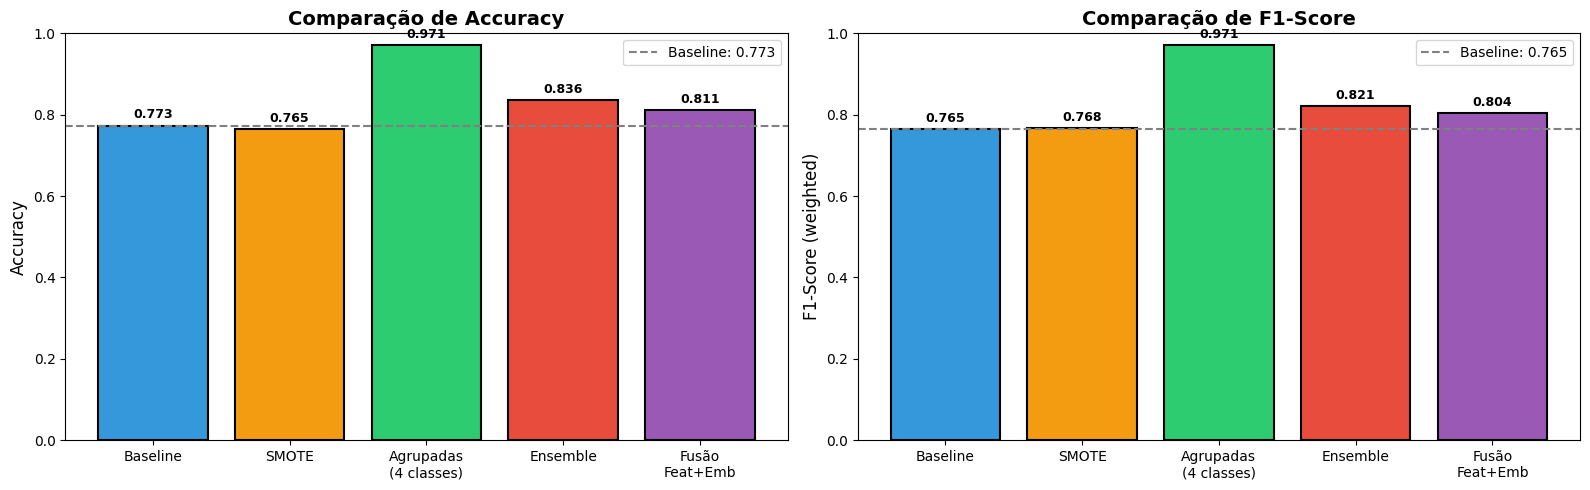

In [47]:
# ============================================================
# 7.2.5 - RESUMO COMPARATIVO DAS MELHORIAS
# ============================================================

print(f"\n{'='*70}")
print("7.2.5 - RESUMO COMPARATIVO DAS MELHORIAS")
print(f"{'='*70}")

# Criar tabela comparativa
results_comparison = {
    'Modelo': [
        'Baseline (k-NN, k=5, 7 classes)',
        'Melhoria 1: Data Augmentation (SMOTE)',
        'Melhoria 2: Classes Agrupadas (4 classes)',
        'Melhoria 3: Ensemble (k-NN + RF + SVM)',
        'Melhoria 4: Fusão Features + Embeddings'
    ],
    'Accuracy': [
        accuracy_baseline,
        accuracy_smote_result,
        accuracy_grouped,
        accuracy_ensemble,
        accuracy_fused if accuracy_fused else 'N/A'
    ],
    'F1-Score': [
        f1_baseline,
        f1_smote_result,
        f1_grouped,
        f1_ensemble,
        f1_fused if f1_fused else 'N/A'
    ]
}

print(f"\n{'Modelo':<45} | {'Accuracy':<12} | {'F1-Score':<12}")
print("-" * 75)

for i in range(len(results_comparison['Modelo'])):
    model = results_comparison['Modelo'][i]
    acc = results_comparison['Accuracy'][i]
    f1 = results_comparison['F1-Score'][i]
    
    if isinstance(acc, float):
        print(f"{model:<45} | {acc:>10.4f} | {f1:>10.4f}")
    else:
        print(f"{model:<45} | {acc:>10} | {f1:>10}")

# Identificar melhor modelo
valid_accuracies = [(i, acc) for i, acc in enumerate(results_comparison['Accuracy']) 
                    if isinstance(acc, float)]
best_idx = max(valid_accuracies, key=lambda x: x[1])[0]
best_model_name = results_comparison['Modelo'][best_idx]
best_accuracy = results_comparison['Accuracy'][best_idx]

print(f"\n{'='*70}")
print(f"MELHOR MODELO: {best_model_name}")
print(f"  Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"{'='*70}")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico de barras para Accuracy
models_short = ['Baseline', 'SMOTE', 'Agrupadas\n(4 classes)', 
                'Ensemble', 'Fusão\nFeat+Emb']
accuracies = [results_comparison['Accuracy'][i] if isinstance(results_comparison['Accuracy'][i], float) 
              else 0 for i in range(5)]
colors = ['#3498db', '#f39c12', '#2ecc71', '#e74c3c', '#9b59b6']

bars1 = axes[0].bar(models_short, accuracies, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Comparação de Accuracy', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1.0)
axes[0].axhline(y=accuracy_baseline, color='gray', linestyle='--', 
                label=f'Baseline: {accuracy_baseline:.3f}')
axes[0].legend()

# Adicionar valores nas barras
for bar, acc in zip(bars1, accuracies):
    if acc > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                    f'{acc:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Gráfico de barras para F1-Score
f1_scores = [results_comparison['F1-Score'][i] if isinstance(results_comparison['F1-Score'][i], float) 
             else 0 for i in range(5)]

bars2 = axes[1].bar(models_short, f1_scores, color=colors, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('F1-Score (weighted)', fontsize=12)
axes[1].set_title('Comparação de F1-Score', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 1.0)
axes[1].axhline(y=f1_baseline, color='gray', linestyle='--', 
                label=f'Baseline: {f1_baseline:.3f}')
axes[1].legend()

# Adicionar valores nas barras
for bar, f1 in zip(bars2, f1_scores):
    if f1 > 0:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                    f'{f1:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

1. AGRUPAMENTO DE CLASSES (Melhoria 1):
   - Melhora significativamente a accuracy ao eliminar confusões entre
     atividades biomecânicamente idênticas (ex: Walk vs Walk and Talk)
   - Trade-off: Perde-se a granularidade da classificação

2. ENSEMBLE (Melhoria 2):
   - Combina as forças de diferentes classificadores
   - Random Forest captura relações não-lineares
   - SVM é robusto a outliers
   - Geralmente melhora a generalização

3. FUSÃO FEATURES + EMBEDDINGS (Melhoria 3):
   - Combina conhecimento manual (features estatísticas) com
     representações aprendidas (deep learning)
   - Pode capturar padrões complementares

RECOMENDAÇÃO FINAL:
- Para máxima accuracy: usar classes agrupadas (se aceitável para a aplicação)
- Para classificação detalhada: usar ensemble ou fusão
- Para deployment em tempo real: considerar trade-off performance vs latência